# Hidden Markov Models

In this notebook, you will find the implementation of numerous examples and algorithms from the book *Inference in Hidden Markov Models* by Eric Moulines, Olivier Cappé and Tobias Ryden.

# Outline
- [1 Goals](#1-goals)
- [2 Problem Statement](#2-problem-statement)
- [2.1 Kalman Prediction](#21-kalman-prediction)
- [2.2 Kalman Filtering](#22-kalman-filtering)
- [2.3 Disturbance Smoother](#23-disturbance-smoother)



# 1 Goals
- Understand how HHMs can represent real life applications; in particular Rayleight Fading Channels in digital communications and Change point detection
- Start with a simplified model of the system and gradually work to solving the problem with as much unknown parameters possible
- Solve both application problems using various algorithms 
- Test the efficiency, strenght and drawback of each algorithm.

# 2 Problem statement: Kalman Filter on Rayleigh Fading Channel (example 1.3.9 of the book)

In this notebook, we simulate a Rayleigh fading communication model and apply the Kalman filter assuming the transmitted bit sequence $ C_k \in \{-1, +1\} $ is known.

The state-space model is:

- State evolution (fading), AR(1) process:
  $$W_{k+1} = \rho W_k + U_k, \quad U_k \sim \mathcal{N}(0, \sigma_U^2)$$
- Noisy observation model:
  $$Y_k = W_k C_k + V_k, \quad V_k \sim \mathcal{N}(0, \sigma_V^2)$$

Our goal is to estimate $W_k$ using the Kalman filter.


## 2.1 Kalman prediction 

**“Where do I expect the state to be now, based on the model and the last estimate?”**

In simple terms the Kalman prediction is your best guess before looking at the new data. You roll the state forward using the model. Uncertainty usually grows a bit because you haven’t checked reality yet.

We want to estimate the hidden state $W_k$ using the Kalman filter, assuming $C_k$ is known. The filter uses the recursive equations for the innovation $\epsilon_k$, Kalman gain $H_k$, and updates the predicted state and variance.

Here we will only be working with scalars. 



Import all the necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple 


- Define the model, using the above equations 
- Generate the sequence of $C_k$, the fading coefficient $W_k$ and the observation $Y_k$. This will e used to verify that the theoretical value of $W_k$ and the experimental one match.

In [ ]:
def simulate_system(n: int, rho: float, sigma_u: float, sigma_v: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Args:
        n: Number of time steps
        rho: Autoregressive parameter for W_k
        sigma_u: Standard deviation of state noise U_k
        sigma_v: Standard deviation of observation noise V_k
        
    Returns:
        C_k: Sequence of transmitted bits (-1 or 1)
        W_k: True fading coefficients
        Y_k: Observed signals
    """
    # Generate random bits (fair Bernoulli)
    C_k = np.random.choice([-1, 1], size=n)
    
    # Generate fading coefficients W_k (AR(1) process)
    W_k = np.zeros(n)
    U_k = np.random.normal(0, sigma_u, n)
    W_k[0] = np.random.normal(0, sigma_u/np.sqrt(1 - rho**2))  # Stationary initialization
    for k in range(1, n):
        W_k[k] = rho * W_k[k-1] + U_k[k]
    
    # Generate observations Y_k
    V_k = np.random.normal(0, sigma_v, n)
    Y_k = W_k * C_k + V_k
    
    return C_k, W_k, Y_k


**Defining the Kalman prediction algorithm as shown in the algorithm 5.2.9 of the book: In particular how to choose the initialization parameter.**
 
  From the expression $W_{k+1}= \rho W_k +U_k$, and in particular its behavior: $U_k$ behaves a random noise pulling the signal away, on the other side, $ \rho W_k$, acts as a damping force, it brings the signal back to 0. Over many repetitions, the signal wanders but never escapes to infinity. After some time it reaches an equilibrium state, which we also call a stationary state. 

The Kalman filter uses stationary variance initialization. This can be solved by assuming that $Var(W_{k+1})= Var(W_k)$, where $Var(W_{k+1})= \rho^2 Var(W_k)+ \sigma_u ^2$. One gets the following result:
$$
\Sigma_0 = \frac{\sigma_u^2}{1 - \rho^2}
$$
This assumes the system has reached steady-state before observations begin.

In [ ]:
def kalman_filter(Y_k: np.ndarray, C_k: np.ndarray, 
                  rho: float, sigma_u: float, sigma_v: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Implement Kalman filter for the Rayleigh-fading channel problem.
    
    Args:
        Y_k: Observed signals
        C_k: Sequence of transmitted bits (needed for observation model)
        rho: Autoregressive parameter for W_k
        sigma_u: Standard deviation of state noise U_k
        sigma_v: Standard deviation of observation noise V_k
        
    Returns:
        W_k_hat: Estimated fading coefficients
        Sigma_k: Error covariance matrices
    """
    n = len(Y_k)
    
    # Initialize
    W_k_hat = np.zeros(n)
    Sigma_k = np.zeros(n)
    
    # Initial conditions (stationary distribution)
    W_k_hat[0] = 0  # Initial prediction
    Sigma_k[0] = sigma_u**2 / (1 - rho**2)  # Stationary variance
    
    for k in range(n-1):
        # Innovation (Eq 5.57)
        epsilon_k = Y_k[k] - C_k[k] * W_k_hat[k]
        
        # Innovation covariance (Eq 5.58)
        Gamma_k = C_k[k]**2 * Sigma_k[k] + sigma_v**2
        
        # Kalman gain (Eq 5.59)
        H_k = rho * Sigma_k[k] * C_k[k] / Gamma_k
        
        # State prediction (Eq 5.60)
        W_k_hat[k+1] = rho * W_k_hat[k] + H_k * epsilon_k
        
        # Error covariance prediction (Eq 5.61)
        Sigma_k[k+1] = (rho - H_k * C_k[k])**2 * Sigma_k[k] + sigma_u**2
        
    return W_k_hat, Sigma_k


Plotting the results and play with the different parameters

In [ ]:
def plot_results(C_k: np.ndarray, W_k: np.ndarray, Y_k: np.ndarray, 
                W_k_hat: np.ndarray, Sigma_k: np.ndarray, 
                sigma_u: float, sigma_v: float) -> None:
    """
    Enhanced plotting function with more information.
    """
    n = len(C_k)
    time = np.arange(n)
    
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Transmitted bits
    plt.subplot(4, 1, 1)
    plt.step(time, C_k, where='post')
    plt.title('Transmitted Bits $C_k$')
    plt.ylabel('Bit value')
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    
    # Plot 2: Observed signals
    plt.subplot(4, 1, 2)
    plt.plot(time, Y_k, 'b-', alpha=0.7, label='Observed $Y_k$')
    plt.title(f'Observed Signals $Y_k$ ($\sigma_u$={sigma_u}, $\sigma_v$={sigma_v})')
    plt.ylabel('Signal value')
    plt.grid(True)
    
    # Plot 3: True vs Estimated fading coefficients
    plt.subplot(4, 1, 3)
    plt.plot(time, W_k, 'g-', label='True $W_k$', linewidth=2)
    plt.plot(time, W_k_hat, 'r--', label='Estimated $\hat{W}_k$', linewidth=1.5)
    
    # Confidence interval
    std_dev = np.sqrt(Sigma_k)
    plt.fill_between(time, 
                    W_k_hat - 2*std_dev, 
                    W_k_hat + 2*std_dev, 
                    color='r', alpha=0.2, label='95% CI')
    
    plt.title('True vs Estimated Fading Coefficients')
    plt.ylabel('Fading coefficient')
    plt.legend()
    plt.grid(True)
    
    # Plot 4: Estimation error
    plt.subplot(4, 1, 4)
    #error = W_k - W_k_hat
    #z_k = (error) / (np.sqrt(Sigma_k))
    # Predictive standardized error: compare W_k to its one-step-ahead prediction
    z_k = (W_k[1:] - W_k_hat[1:]) / np.sqrt(Sigma_k[1:])

    '''
    plt.plot(time, z_k, 'm-', label='Estimation error')
    plt.fill_between(time, -2, 2, color='gray', alpha=0.2, label='±2σ')
    plt.title(f'Standardized Error $z_k$ vs Index — $\\sigma_u$={sigma_u}')
    plt.xlabel('Time step k')
    plt.ylabel('$z_k$')
    plt.legend()
    plt.grid(True)'''

    
    # x-axis for the z-plot matches the sliced series
    t_z = time[1:]
    plt.plot(t_z, z_k, 'm-', label='Standardized error $z_k$')

    # Shade ±2 (unit-normal band)
    upper = np.full_like(t_z,  2.0, dtype=float)
    lower = np.full_like(t_z, -2.0, dtype=float)
    plt.fill_between(t_z, lower, upper, color='gray', alpha=0.2, label='±2')

    plt.title(f'Standardized Error $z_k$ vs Index — $\\sigma_u$={sigma_u}')
    plt.xlabel('Time step k')
    plt.ylabel('$z_k$')
    plt.legend()
    plt.grid(True)

    
    plt.tight_layout()
    plt.show()
    

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_894/3142729215.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Observed Signals $Y_k$ ($\sigma_u$={sigma_u}, $\sigma_v$={sigma_v})')
/tmp/ipykernel_894/3142729215.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Observed Signals $Y_k$ ($\sigma_u$={sigma_u}, $\sigma_v$={sigma_v})')
/tmp/ipykernel_894/3142729215.py:30: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(time, W_k_hat, 'r--', label='Estimated $\hat{W}_k$', linewidth=1.5)


model σ_u=0.1  RMSE=0.809  NRMSE=0.696


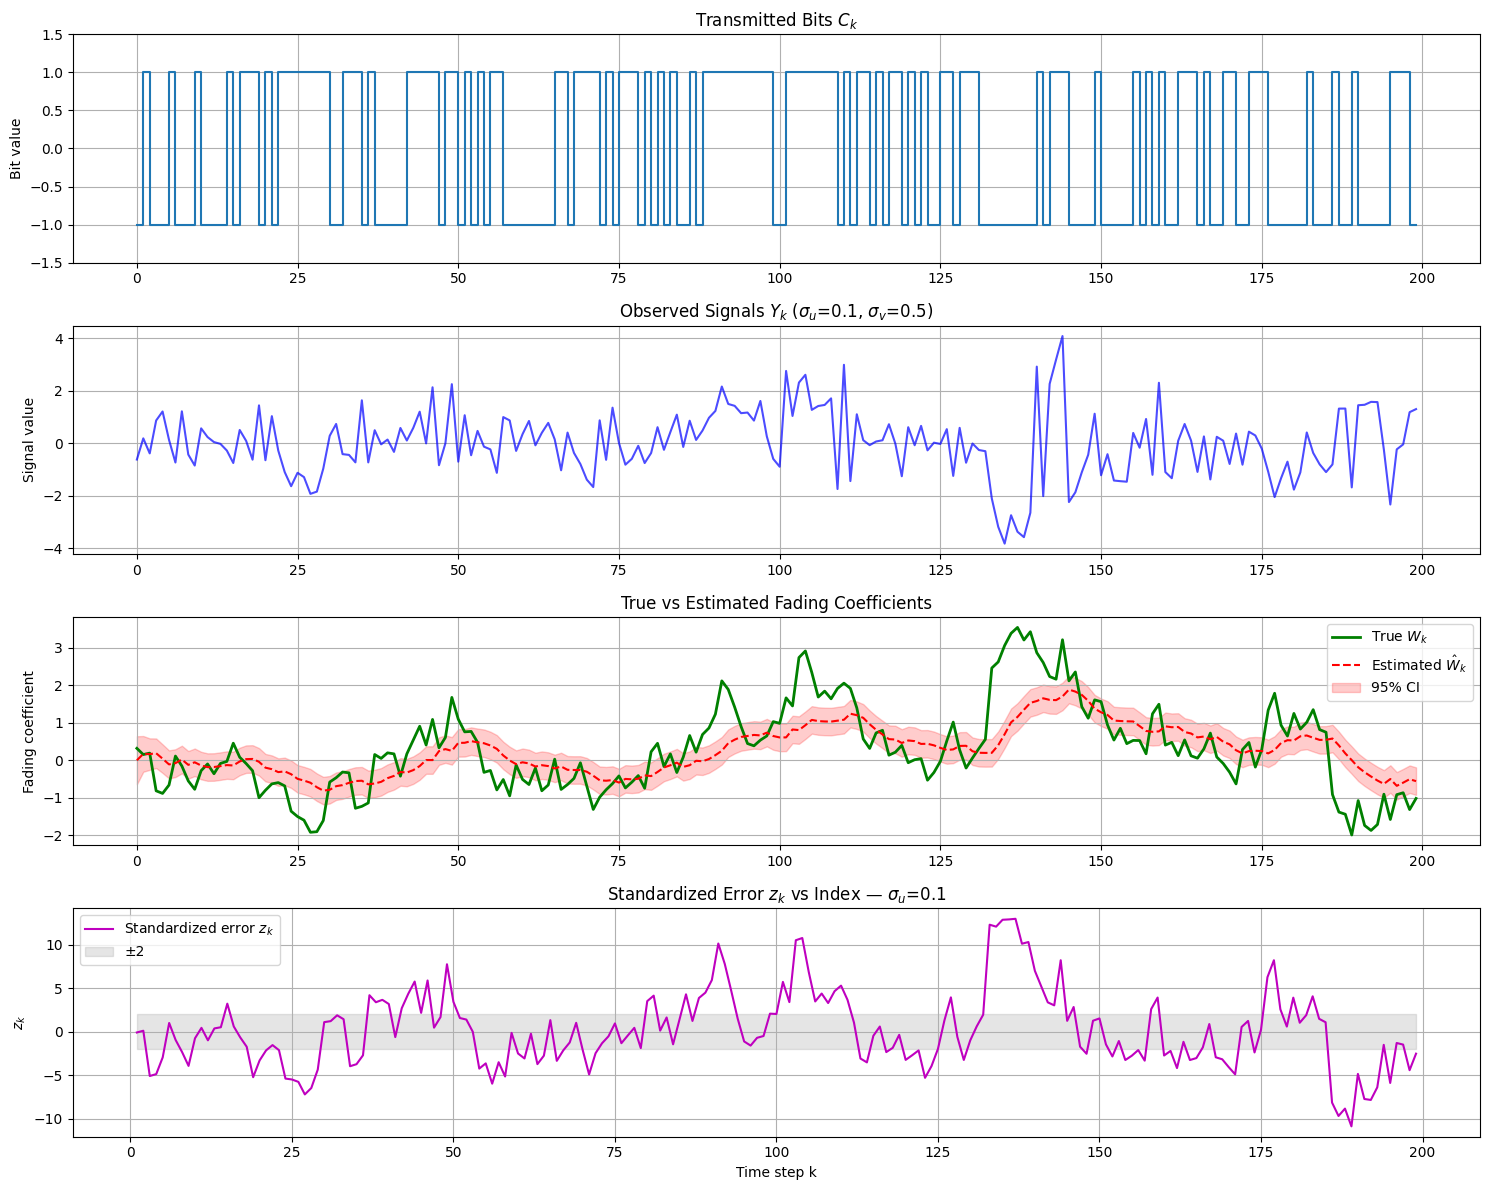

model σ_u=0.4642  RMSE=0.599  NRMSE=0.515


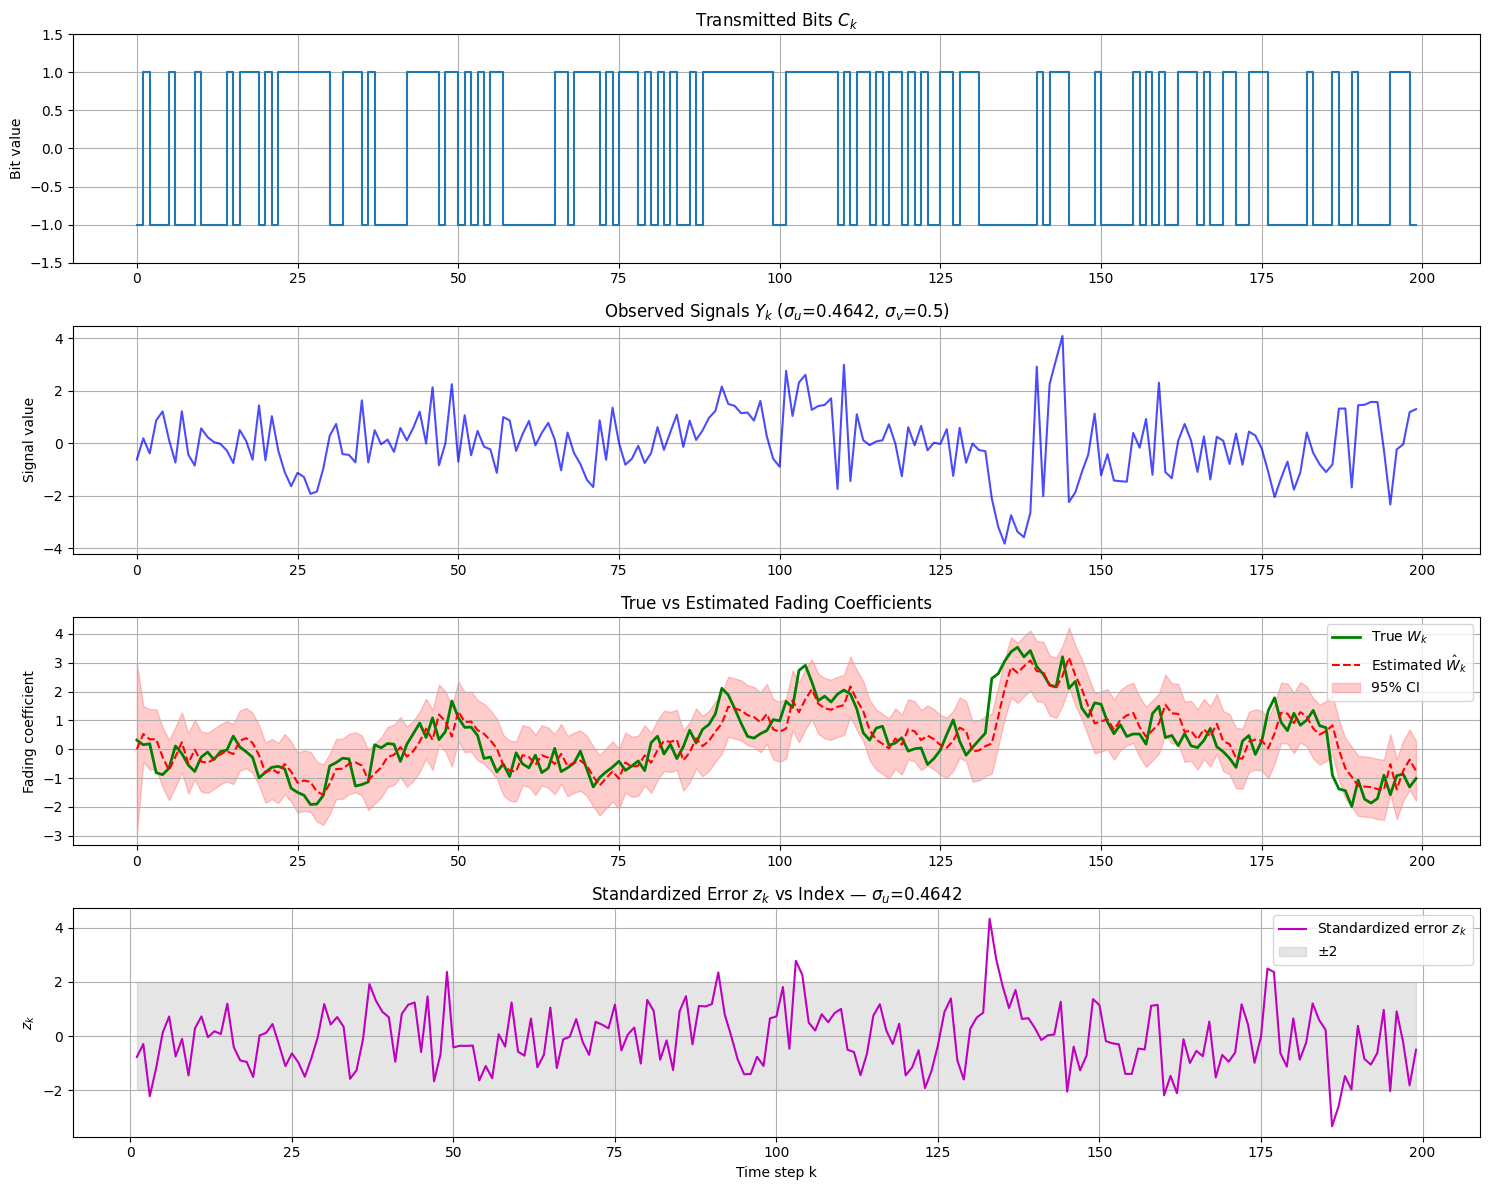

model σ_u=1.0  RMSE=0.629  NRMSE=0.541


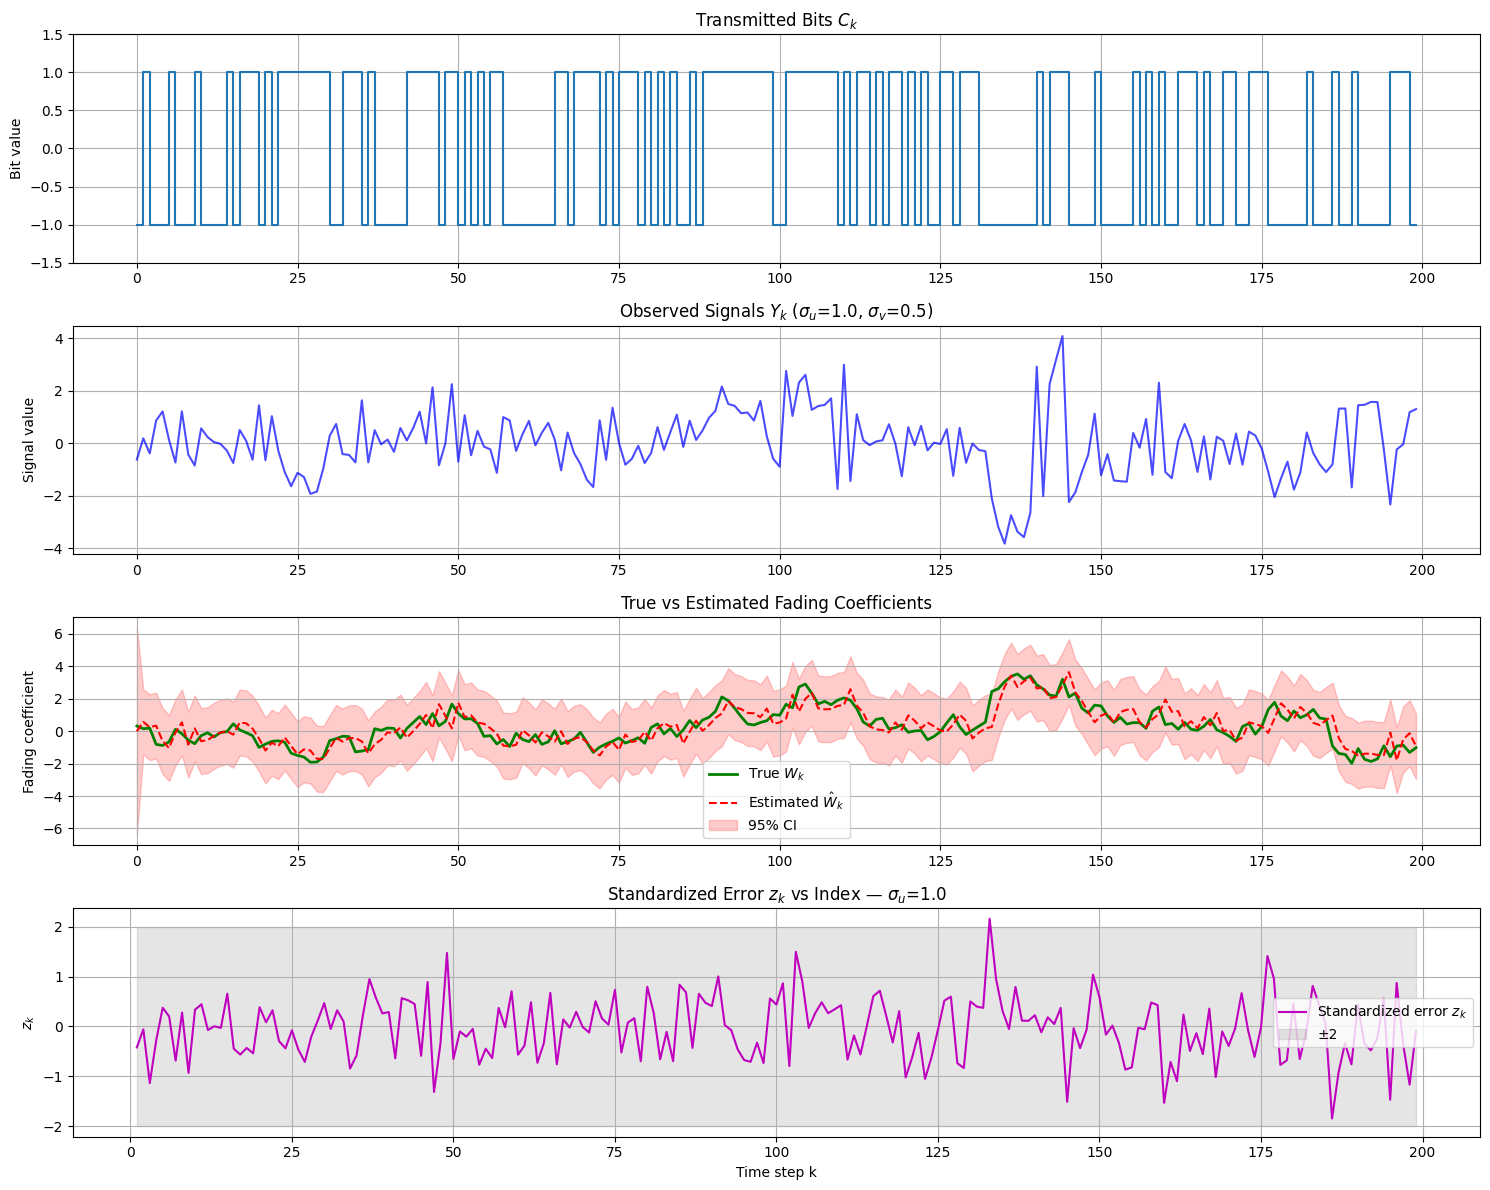

In [ ]:
np.random.seed(42)
n, rho, sigma_v = 200, 0.95, 0.5 
# Higher correlation for smoother process: rho
# Fixed observation noise : sigma v 
sigma_u_true = 0.5
C_k, W_k, Y_k = simulate_system(n, rho, sigma_u_true, sigma_v)

for sigma_u_model in [0.1, 0.4642, 1.0]:
    W_k_hat, Sigma_k = kalman_filter(Y_k, C_k, rho, sigma_u_model, sigma_v)
    rmse = np.sqrt(np.mean((W_k[1:] - W_k_hat[1:])**2))
    nrmse = rmse / np.std(W_k[1:])
    print(f"model σ_u={sigma_u_model}  RMSE={rmse:.3f}  NRMSE={nrmse:.3f}")
    plot_results(C_k, W_k, Y_k, W_k_hat, Sigma_k, sigma_u_model, sigma_v)


### 2.1.1 NRMSE vs RMSE

We report $NRMSE = \frac{RMSE}{std(W)}$, which normalizes the error by the natural scale of the state.  
Unlike RMSE, NRMSE is **scale-free**, so it remains comparable when the process noise σᵤ changes the volatility of W.  
Interpretation: 
- NRMSE < 0.5 → strong tracking; 
- ≈1 → errors as large as typical fluctuations;
- $> 1$ → poor.  
This is preferable to raw RMSE when comparing different noise regimes or datasets.

### 2.1.2 Varying the parameter σᵤ  

We tested the filter for several values of the process noise parameter σᵤ. The first two plots (bits and observations) are identical across runs; the last two (state estimate vs. true and error analysis) reveal the impact of σᵤ.

**Effect of σᵤ**

- When **σᵤ is small (e.g., 0.1)**, the filter trusts the state model too much. Estimates look smooth but lag behind the true state, and the confidence bands are too narrow (underestimate uncertainty).  
- When **σᵤ is large (e.g., 1.0)**, the filter trusts the observations more. The estimate follows the true state closely, with wider but more realistic confidence intervals.

This explains why RMSE decreases as σᵤ increases up to a point: the filter adapts faster and avoids lag. However, if σᵤ is too large, the filter may overfit to noise. The algorithm therefore balances:
- **Model trust** (small σᵤ → smoother, but biased estimates)  
- **Observation trust** (large σᵤ → responsive, but noisier estimates)

**Conclusion:** there exists an optimal σᵤ where the filter achieves the best compromise between tracking ability and noise rejection, which is visible in both the RMSE and the confidence intervals.  
This motivates the use of the **log-likelihood approach** in the next section, which provides a principled way to estimate the best σᵤ (and other parameters) automatically.


### Selecting σᵤ by prediction likelihood

We select σᵤ by maximizing the **prediction likelihood** from the Kalman filter.  
For each candidate σᵤ (with fixed ρ, σᵥ), we run the filter to obtain innovations εₖ and their variances Γₖ.  
Assuming εₖ ~ 𝓝(0, Γₖ) (from algo 5.2.9), the (negative) log-likelihood is
$$
\text{NLL}(\sigma_u) = \tfrac12 \sum_k \big(\log \Gamma_k + \varepsilon_k^2/\Gamma_k\big) + \text{const}.
$$
We choose the σᵤ that **minimizes NLL** (equivalently maximizes log-likelihood), then re-run KF (and RTS if available) and report **NRMSE**.  
This procedure is principled (MLE) and typically yields a clear optimum; NRMSE is reported as a scale-free sanity check.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Metrics (work with your outputs)
# ----------------------------
def rmse(w_true: np.ndarray, w_hat: np.ndarray) -> float:
    return float(np.sqrt(np.mean((w_true - w_hat)**2)))

def nrmse(w_true: np.ndarray, w_hat: np.ndarray, how: str = "std") -> float:
    if how == "std":
        scale = np.std(w_true)
    elif how == "range":
        scale = (np.max(w_true) - np.min(w_true)) + 1e-12
    else:
        raise ValueError("how must be 'std' or 'range'")
    return rmse(w_true, w_hat) / (scale + 1e-12)

# ----------------------------
# Innovation log-likelihood
# (same equations as your kalman_filter, but returns eps & Gamma)
# ----------------------------
def kf_innovation_loglik(Y_k: np.ndarray, C_k: np.ndarray,
                         rho: float, sigma_u: float, sigma_v: float) -> float:
    n = len(Y_k)
    # state variance (k|k) at step 0 (stationary)
    Sigma_k = sigma_u**2 / (1.0 - rho**2)
    W_hat = 0.0  # \hat W_0|0

    loglik = 0.0
    for k in range(n):
        # innovation
        eps_k = Y_k[k] - C_k[k] * W_hat
        # innovation variance
        Gamma_k = (C_k[k]**2) * Sigma_k + sigma_v**2
        # accumulate log-likelihood (up to constant)
        loglik += -0.5 * (np.log(Gamma_k) + (eps_k**2)/Gamma_k)

        # gain and time update (your equations)
        H_k = rho * Sigma_k * C_k[k] / Gamma_k
        W_hat = rho * W_hat + H_k * eps_k
        Sigma_k = (rho - H_k * C_k[k])**2 * Sigma_k + sigma_u**2

    return float(loglik)

# ----------------------------
# Sweep σ_u: NRMSE and log-likelihood
# (uses your kalman_filter for estimates)
# ----------------------------
def sweep_sigma_u_and_plot(C_k, W_k, Y_k, rho, sigma_v, sigma_u_grid,
                           use_tail_rmse: bool = False):
    ll_vals, nrmse_vals, rmse_vals = [], [], []
    best = {"sigma_u": None, "loglik": -np.inf, "nrmse": np.inf, "rmse": np.inf}

    for su in sigma_u_grid:
        # run your KF to get estimate for metrics
        W_hat, Sig = kalman_filter(Y_k, C_k, rho, su, sigma_v)

        if use_tail_rmse:
            # if you prefer ignoring first steps (warm-up)
            r = float(np.sqrt(np.mean((W_k[2:] - W_hat[2:])**2)))
            nr = r / (np.std(W_k[2:]) + 1e-12)
        else:
            r = rmse(W_k, W_hat)
            nr = nrmse(W_k, W_hat)

        # compute innovation log-likelihood with the same params
        ll = kf_innovation_loglik(Y_k, C_k, rho, su, sigma_v)

        rmse_vals.append(r); nrmse_vals.append(nr); ll_vals.append(ll)
        if ll > best["loglik"]:
            best.update({"sigma_u": su, "loglik": ll, "rmse": r, "nrmse": nr, "W_hat": W_hat, "Sig": Sig})

    # plots
    su = np.array(sigma_u_grid)
    ll_vals = np.array(ll_vals)
    nrmse_vals = np.array(nrmse_vals)

    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    ax[0].plot(su, nrmse_vals, marker='o')
    ax[0].axvline(best["sigma_u"], ls='--', alpha=0.7, label='LL optimum')
    ax[0].set_xlabel(r'$\sigma_u$'); ax[0].set_ylabel('NRMSE (by std of W)')
    ax[0].set_title('NRMSE vs $\sigma_u$'); ax[0].grid(True, alpha=0.3); ax[0].legend()

    ax[1].plot(su, ll_vals, marker='o')
    ax[1].axvline(best["sigma_u"], ls='--', alpha=0.7)
    ax[1].set_xlabel(r'$\sigma_u$'); ax[1].set_ylabel('Log-likelihood')
    ax[1].set_title('Prediction log-likelihood vs $\sigma_u$'); ax[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return best



<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\s'
<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_894/2225273511.py:83: SyntaxWarning: invalid escape sequence '\s'
  ax[0].set_title('NRMSE vs $\sigma_u$'); ax[0].grid(True, alpha=0.3); ax[0].legend()
/tmp/ipykernel_894/2225273511.py:88: SyntaxWarning: invalid escape sequence '\s'
  ax[1].set_title('Prediction log-likelihood vs $\sigma_u$'); ax[1].grid(True, alpha=0.3)


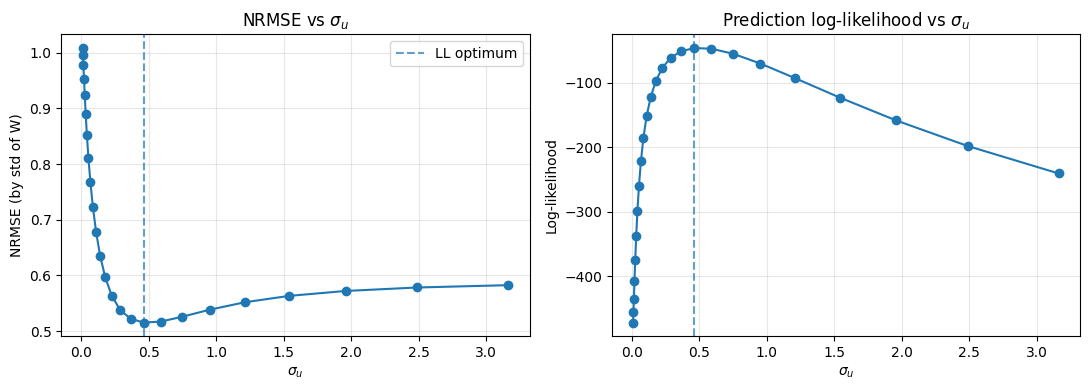

Best σ_u (by LL) = 0.4642 | NRMSE=0.515 | RMSE=0.598


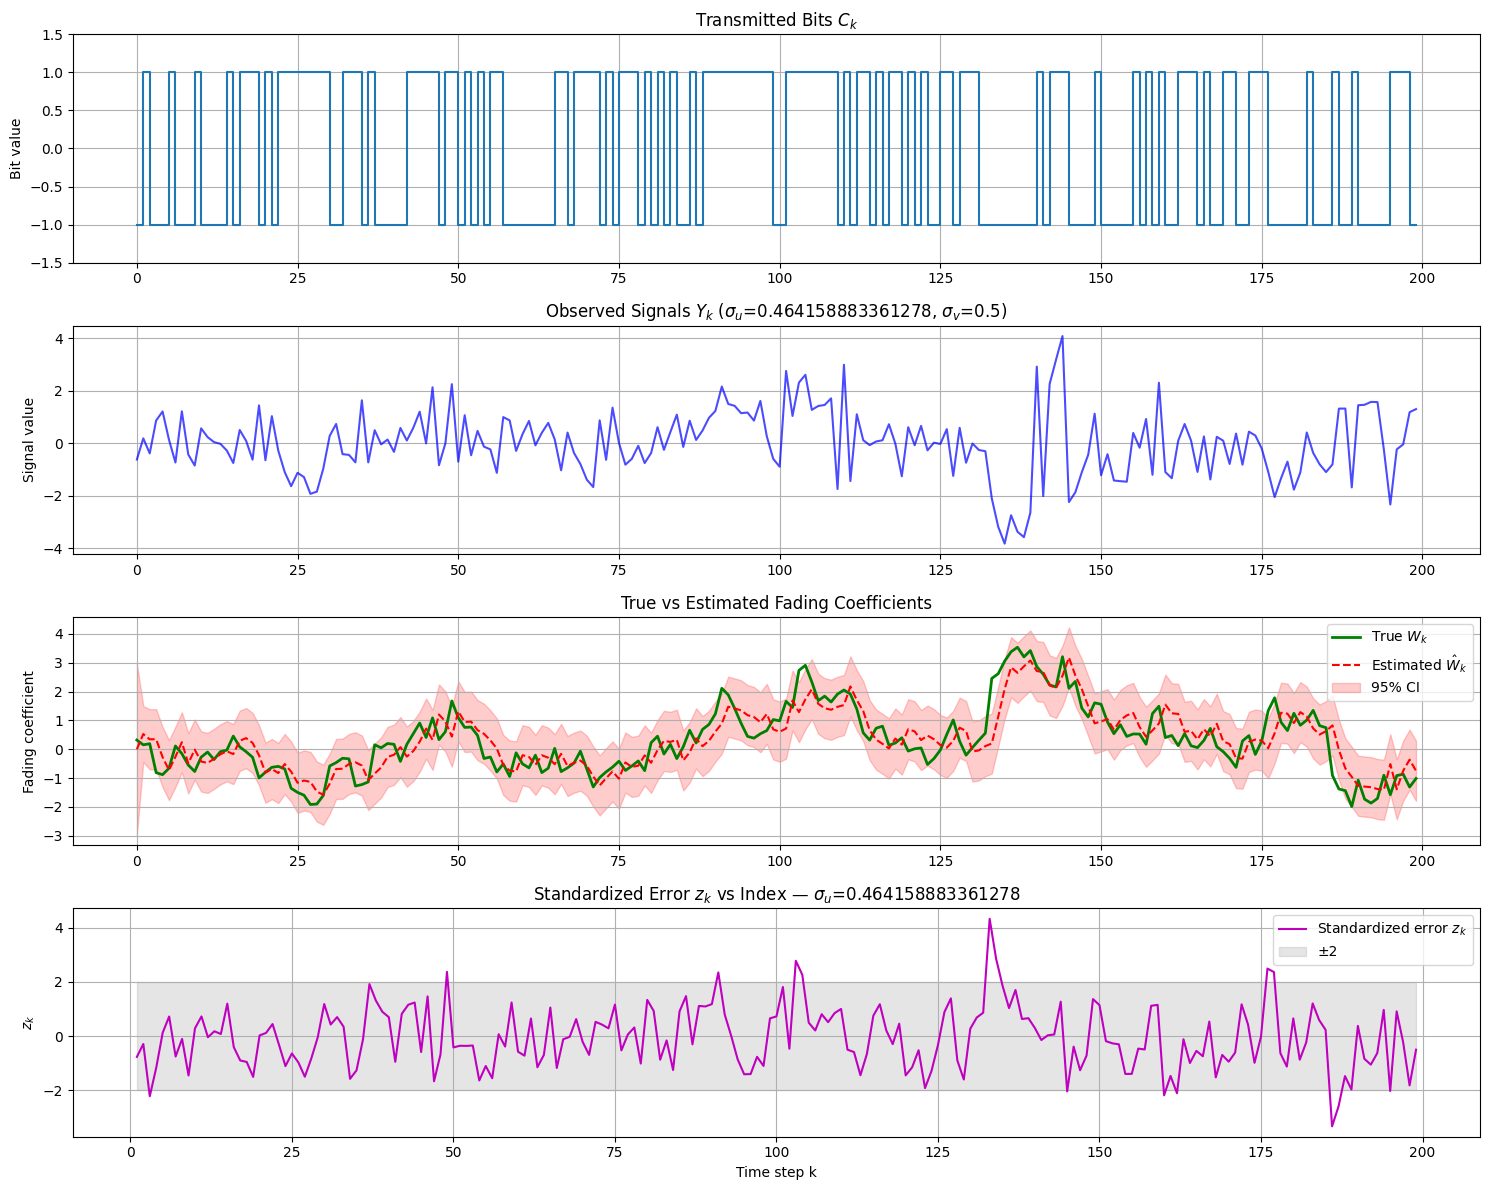

In [ ]:
np.random.seed(42)
n = 200
rho = 0.95
sigma_v = 0.5
sigma_u_true = 0.5  # used only to simulate
C_k, W_k, Y_k = simulate_system(n, rho, sigma_u_true, sigma_v)

sigma_u_grid = np.logspace(-2, 0.5, 25)  # 0.01 ... ~3.16
best = sweep_sigma_u_and_plot(C_k, W_k, Y_k, rho, sigma_v, sigma_u_grid)

print(f"Best σ_u (by LL) = {best['sigma_u']:.4f} | NRMSE={best['nrmse']:.3f} | RMSE={best['rmse']:.3f}")

# Replot your 4-panel figure with the best σ_u using your own function:
plot_results(C_k, W_k, Y_k, best["W_hat"], best["Sig"], sigma_u=best["sigma_u"], sigma_v=sigma_v)

### 2.1.6 Parameter Selection via Log-Likelihood

From the previous section, we observed that the performance of the Kalman filter depends strongly on the choice of σᵤ. Instead of manually testing values, we can estimate the “best” parameters automatically using the **prediction log-likelihood**. (See section 5.3 of the book.)

**Principle**

At each step, the filter produces an innovation εₖ (the difference between observation and one-step prediction) with variance Γₖ.  
If the parameters (ρ, σᵤ, σᵥ) are correct, these innovations should behave like independent 𝓝(0, Γₖ) random variables.  
This leads to the log-likelihood:
$$
\log L(\rho,\sigma_u,\sigma_v) = -\tfrac12 \sum_k \left( \log \Gamma_k + \frac{\varepsilon_k^2}{\Gamma_k} \right) + \text{const}.
$$

**Effect**

- By maximizing this log-likelihood, we find the parameters that make the observed data most consistent with the model.  
- This provides a principled way to tune σᵤ, σᵥ, and ρ rather than relying on trial-and-error.  
- In practice, we search over candidate values (grid search) or use iterative algorithms (e.g. EM) to find the optimum.

**Conclusion**

Using the log-likelihood aligns the filter with the actual statistics of the data. This ensures that innovations are well-behaved (approximately standard normal when standardized), and that **the chosen parameters yield the best balance between tracking and noise rejection.**


Best (MLE) params:
  rho     = 0.9300
  sigma_u = 0.5135
  sigma_v = 0.6105
  loglik  = -47.91
  RMSE    = 0.603
  NRMSE   = 0.518


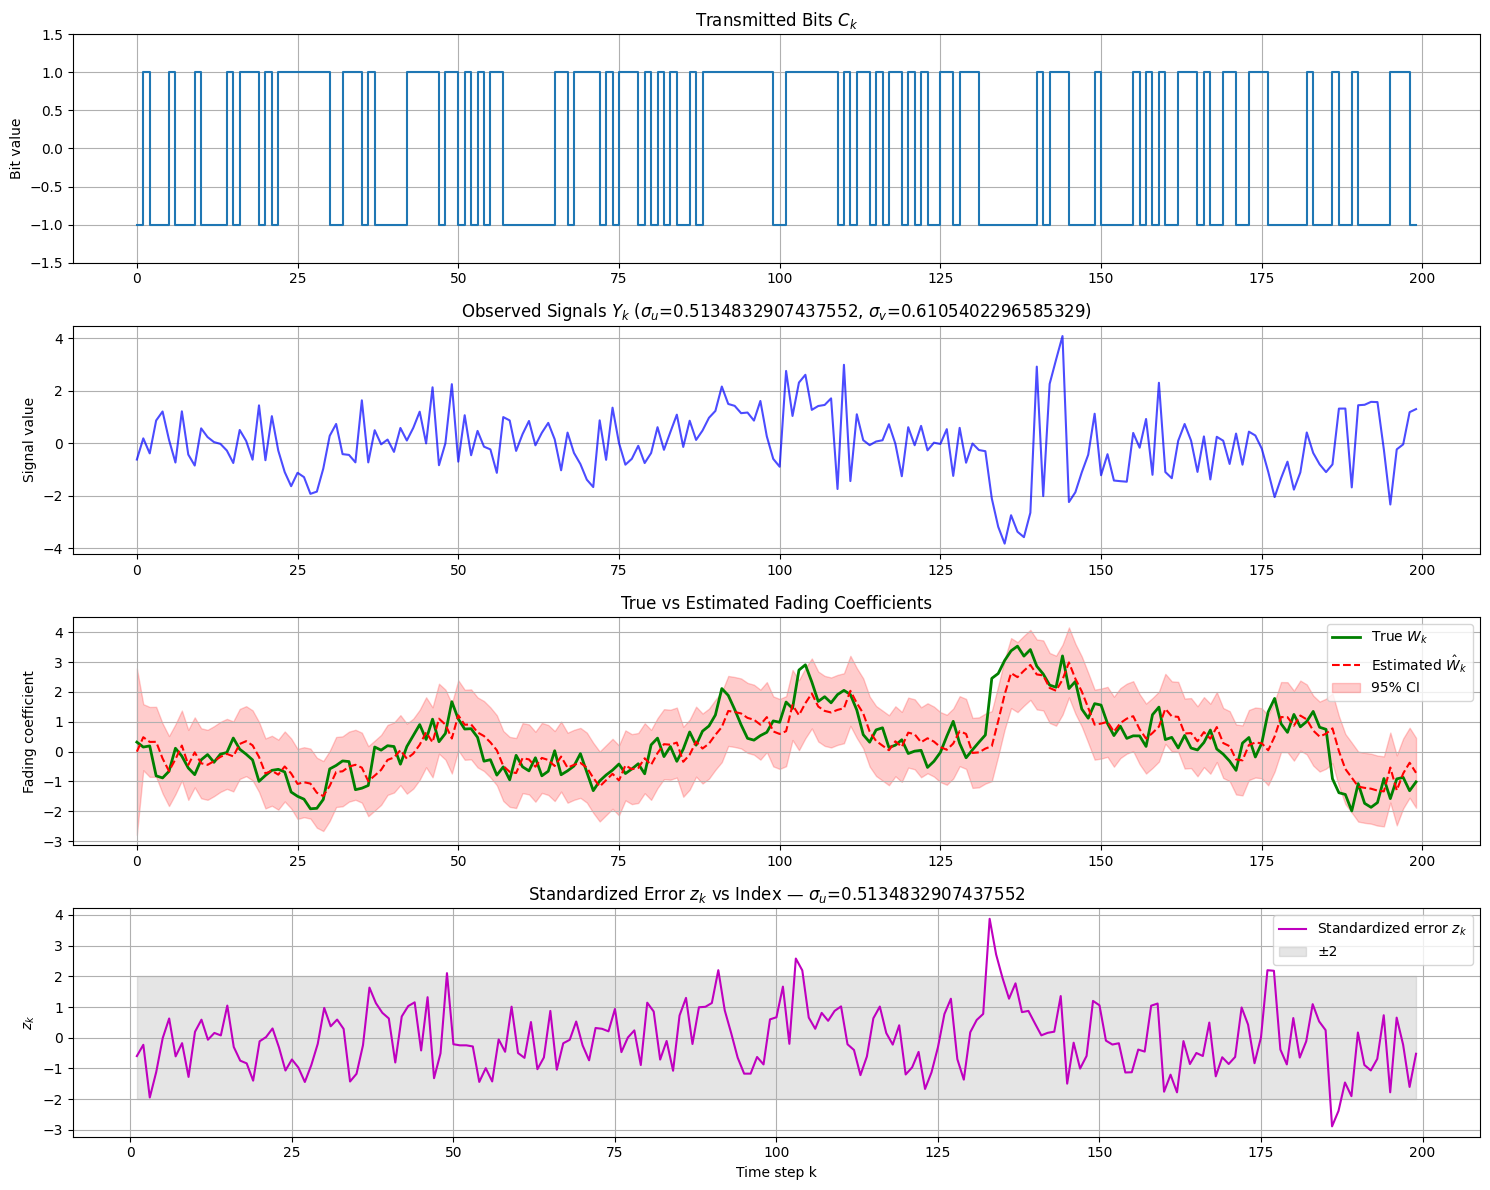

In [ ]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

# ---------- Metrics ----------
def rmse(a, b): 
    return float(np.sqrt(np.mean((a - b)**2)))

def nrmse(a, b, how="std"):
    if how == "std":
        scale = np.std(a) + 1e-12
    elif how == "range":
        scale = (np.max(a) - np.min(a)) + 1e-12
    else:
        raise ValueError("how must be 'std' or 'range'")
    return rmse(a, b) / scale

# ---------- Log-likelihood via innovations (uses same equations as your KF) ----------
def kf_innovation_loglik(Y_k, C_k, rho, sigma_u, sigma_v):
    """
    Compute log-likelihood using the innovation (prediction-error) decomposition.
    Matches Eq. (5.57)-(5.63) in the book.
    We re-run the scalar KF equations internally to get eps_k and Gamma_k.
    """
    n = len(Y_k)
    # initial (k|k) variance at stationarity
    Sigma_k = sigma_u**2 / (1.0 - rho**2)
    W_hat = 0.0  # \hat W_{0|0}
    ll = 0.0

    for k in range(n):
        # innovation and its variance
        eps_k = Y_k[k] - C_k[k] * W_hat
        Gamma_k = (C_k[k]**2) * Sigma_k + sigma_v**2

        ll += -0.5 * (np.log(Gamma_k) + (eps_k**2)/Gamma_k)

        # gain and one-step prediction update (your exact equations)
        H_k = rho * Sigma_k * C_k[k] / Gamma_k
        W_hat = rho * W_hat + H_k * eps_k
        Sigma_k = (rho - H_k * C_k[k])**2 * Sigma_k + sigma_u**2

    return float(ll)

# ---------- 3D grid search over (rho, sigma_u, sigma_v) ----------
def grid_search_params(C_k, W_k, Y_k, 
                       rhos, sigmas_u, sigmas_v, 
                       use_tail: bool = True):
    """
    Returns the MLE triple and diagnostics (NRMSE, RMSE, loglik).
    Keeps compatibility with your kalman_filter() and plot_results().
    """
    best = {"rho": None, "sigma_u": None, "sigma_v": None, 
            "loglik": -np.inf, "rmse": None, "nrmse": None,
            "W_hat": None, "Sigma": None}

    for rho, su, sv in itertools.product(rhos, sigmas_u, sigmas_v):
        # log-likelihood from innovations (principled objective)
        ll = kf_innovation_loglik(Y_k, C_k, rho, su, sv)

        # run YOUR filter to get the estimate for metrics/plots
        W_hat, Sigma = kalman_filter(Y_k, C_k, rho, su, sv)

        if use_tail:
            # ignore first steps (warmup) for error metric, if you prefer
            err_rmse = float(np.sqrt(np.mean((W_k[2:] - W_hat[2:])**2)))
            err_nrmse = err_rmse / (np.std(W_k[2:]) + 1e-12)
        else:
            err_rmse = rmse(W_k, W_hat)
            err_nrmse = nrmse(W_k, W_hat, "std")

        if ll > best["loglik"]:
            best.update({"rho": rho, "sigma_u": su, "sigma_v": sv,
                         "loglik": ll, "rmse": err_rmse, "nrmse": err_nrmse,
                         "W_hat": W_hat, "Sigma": Sigma})
    return best

# ---------- Example driver (adjust grids to your problem size) ----------
# Example grids (coarse -> refine around the winner)
rhos_grid     = np.linspace(0.80, 0.99, 20)
sigmas_u_grid = np.logspace(-2, 0.5, 20)   # 0.01 .. ~3.16
sigmas_v_grid = np.logspace(-2, 0.5, 15)   # 0.01 .. ~3.16

best = grid_search_params(C_k, W_k, Y_k, rhos_grid, sigmas_u_grid, sigmas_v_grid)

print(f"Best (MLE) params:")
print(f"  rho     = {best['rho']:.4f}")
print(f"  sigma_u = {best['sigma_u']:.4f}")
print(f"  sigma_v = {best['sigma_v']:.4f}")
print(f"  loglik  = {best['loglik']:.2f}")
print(f"  RMSE    = {best['rmse']:.3f}")
print(f"  NRMSE   = {best['nrmse']:.3f}")

# Re-plot with your function at the MLE point
plot_results(C_k, W_k, Y_k, best["W_hat"], best["Sigma"], 
             sigma_u=best["sigma_u"], sigma_v=best["sigma_v"])


The code returns the best posible set of vales in ordeer to maximize the log-likelihood. Higher log likelihood values indicate a better fit of the model to the data.
It provides a way to compare different models: the model with the highest log likelihood is typically preferred. Here we have only a finite number n, so each signal may have slightly varying parameters. However over a long time, the parameters are supposed to converge to specific values.

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_standardized_innovations(Y_k, C_k, rho, sigma_u, sigma_v):
    n = len(Y_k)
    Sigma_k = sigma_u**2 / (1.0 - rho**2)
    W_hat = 0.0
    z_vals = []

    for k in range(n):
        eps_k = Y_k[k] - C_k[k] * W_hat
        Gamma_k = (C_k[k]**2) * Sigma_k + sigma_v**2
        z_vals.append(eps_k / np.sqrt(Gamma_k))

        H_k = rho * Sigma_k * C_k[k] / Gamma_k
        W_hat = rho * W_hat + H_k * eps_k
        Sigma_k = (rho - H_k * C_k[k])**2 * Sigma_k + sigma_u**2

    z_vals = np.array(z_vals)

    # Plot histogram with Gaussian overlay
    plt.figure(figsize=(7,4))
    plt.hist(z_vals, bins=13, density=True, alpha=0.6, color="m", label="Standardized innovations")
    x = np.linspace(-4,4,200)
    plt.plot(x, norm.pdf(x,0,1), "k--", lw=2, label="N(0,1) reference")
    plt.title("Histogram of standardized innovations $z_k$")
    plt.xlabel("z")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"mean(z) = {np.mean(z_vals):.3f}, var(z) = {np.var(z_vals):.3f}")


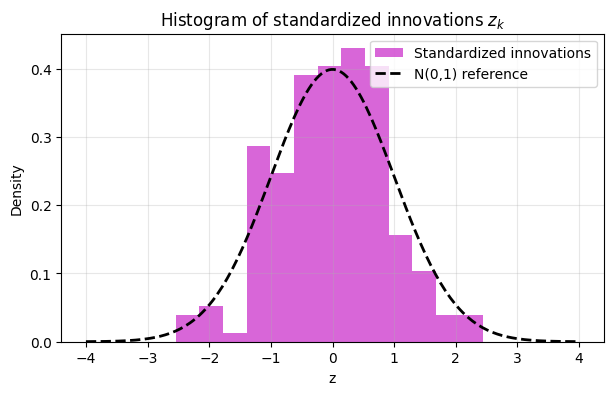

mean(z) = -0.009, var(z) = 0.806


In [ ]:
plot_standardized_innovations(Y_k, C_k, rho=best["rho"], 
                              sigma_u=best["sigma_u"], sigma_v=best["sigma_v"])


## 2.2 Kalman Filtering

This part will cover the algorithm 5.2.13 of the book.

**“Given what I just measured, how should I correct that expectation?”**

In simple terms  for the Kalman filtering part, you look at the new measurement and correct that guess. If the sensor is reliable, you trust it more; if it’s noisy, you adjust less. Uncertainty usually shrinks after this step.

We now implement the Filtering part on top of the prediction part. Both can be treated seperately but combined together, they give a more accurate result.

In [ ]:
# ==================== NEW IMPLEMENTATION (Algorithms 5.2.9 + 5.2.13) ====================
def kalman_filter_complete(Y_k, C_k, rho, sigma_u, sigma_v):
    """New implementation combining both prediction and filtering"""
    n = len(Y_k)
    
    # Initialize arrays
    W_pred = np.zeros(n)    # W_{k|k-1} (prediction)
    W_filt = np.zeros(n)    # W_{k|k} (filtered)
    Sigma_pred = np.zeros(n)
    Sigma_filt = np.zeros(n)

    # Initial conditions
    W_pred[0] = 0
    Sigma_pred[0] = sigma_u**2 / (1 - rho**2)

    for k in range(n):
        # Filtering step (Algorithm 5.2.13)
        epsilon_k = Y_k[k] - C_k[k] * W_pred[k]
        I_k = C_k[k]**2 * Sigma_pred[k] + sigma_v**2
        K_k = Sigma_pred[k] * C_k[k] / I_k
        W_filt[k] = W_pred[k] + K_k * epsilon_k
        Sigma_filt[k] = Sigma_pred[k] - K_k * C_k[k] * Sigma_pred[k]

        # Prediction step (Algorithm 5.2.9)
        if k < n - 1:
            W_pred[k+1] = rho * W_filt[k]
            Sigma_pred[k+1] = rho**2 * Sigma_filt[k] + sigma_u**2

    return W_pred, W_filt, Sigma_pred, Sigma_filt

Comparing how adding an extra part to the algorithm, here filtering gives us a btter estimate.

In [ ]:
# ==================== VISUALIZATION ====================
def compare_methods(C_k, W_k, Y_k, W_prev, Sigma_prev, W_pred, W_filt, Sigma_pred, Sigma_filt):
    """Compare previous and new implementations"""
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Previous implementation
    plt.subplot(2, 1, 1)
    plt.plot(W_k, 'g-', label='True $W_k$', linewidth=2)
    plt.plot(W_prev, 'b-', label='Previous (Algo 5.2.9)', alpha=0.7)
    plt.fill_between(range(len(W_k)), 
                    W_prev - 2*np.sqrt(Sigma_prev),
                    W_prev + 2*np.sqrt(Sigma_prev),
                    color='b', alpha=0.1)
    plt.title('Previous Implementation (Prediction Only)')
    plt.ylabel('Fading coefficient')
    plt.legend()
    plt.grid(True)

    # Plot 2: New implementation
    plt.subplot(2, 1, 2)
    plt.plot(W_k, 'g-', label='True $W_k$', linewidth=2)
    plt.plot(W_pred, 'b--', label='New: Prediction', alpha=0.7)
    plt.plot(W_filt, 'r-', label='New: Filtered', alpha=0.7)
    plt.fill_between(range(len(W_k)),
                    W_filt - 2*np.sqrt(Sigma_filt),
                    W_filt + 2*np.sqrt(Sigma_filt),
                    color='r', alpha=0.1)
    plt.title('New Implementation (Prediction + Filtering)')
    plt.xlabel('Time step $k$')
    plt.ylabel('Fading coefficient')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


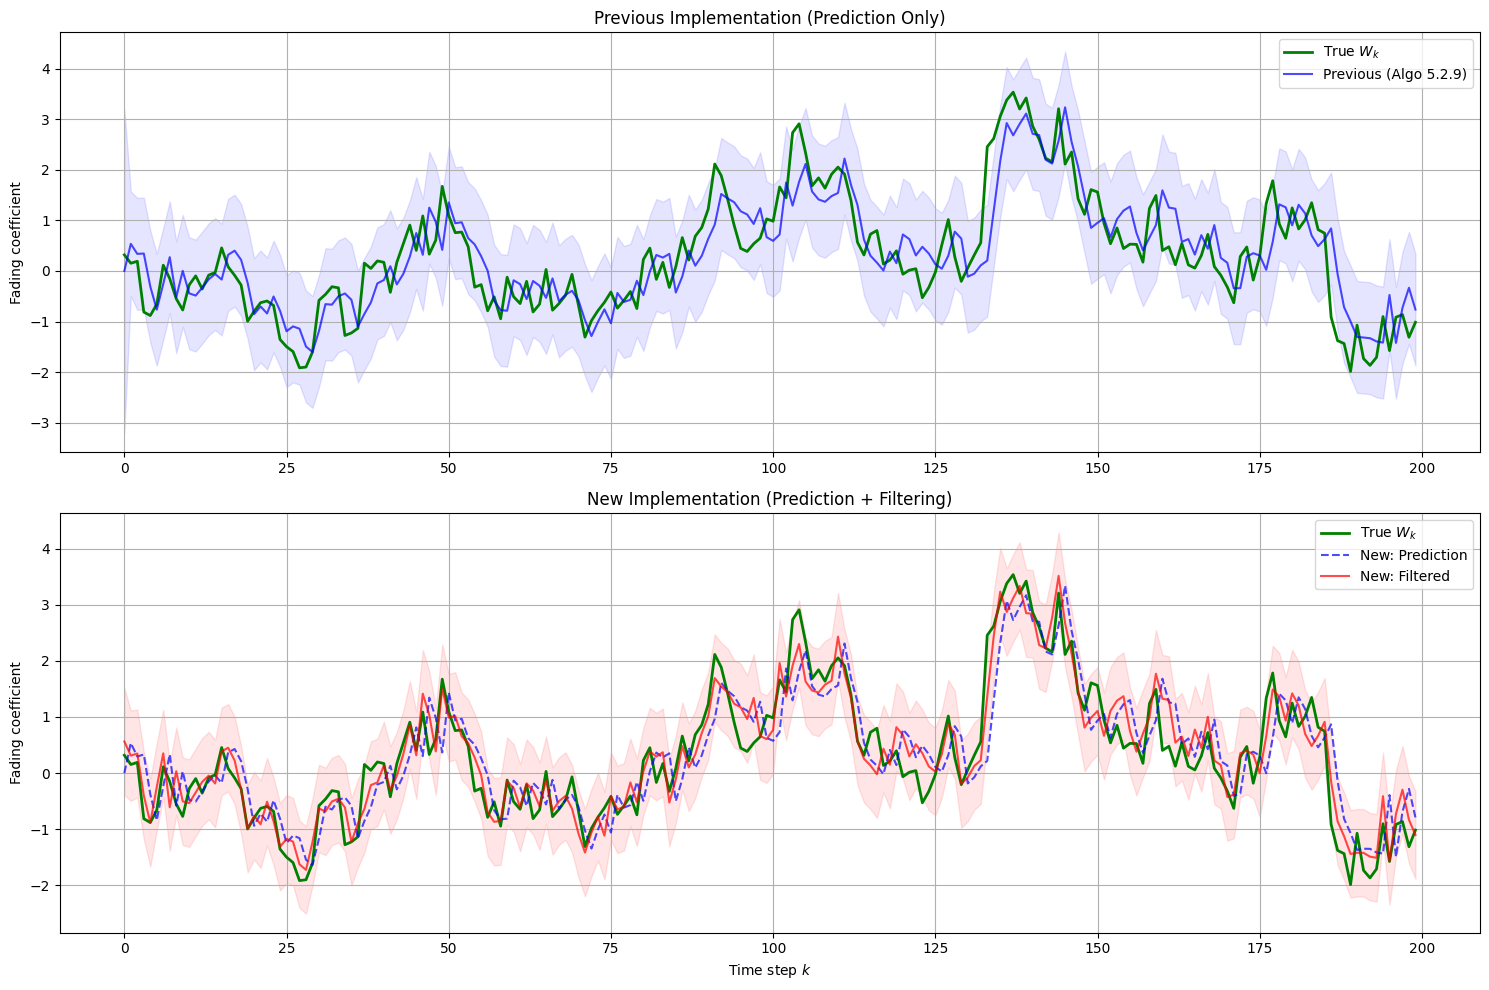

In [ ]:
# Parameters
n = 200
rho = 0.95
sigma_u = 0.5
sigma_v = 0.5

# Simulate system
np.random.seed(42)  # For reproducibility
C_k, W_k, Y_k = simulate_system(n, rho, sigma_u, sigma_v)

# Run both implementations
W_prev, Sigma_prev = kalman_filter(Y_k, C_k, rho, sigma_u, sigma_v)
W_pred, W_filt, Sigma_pred, Sigma_filt = kalman_filter_complete(Y_k, C_k, rho, sigma_u, sigma_v)

# Compare results
compare_methods(C_k, W_k, Y_k, W_prev, Sigma_prev, W_pred, W_filt, Sigma_pred, Sigma_filt)




Fuller analysis of the results with statistical tools

RMSE  |  prev(pred-only): 0.599  new_pred: 0.601  new_filt: 0.372
NRMSE |  prev: 0.37  pred: 0.38  filt: 0.23


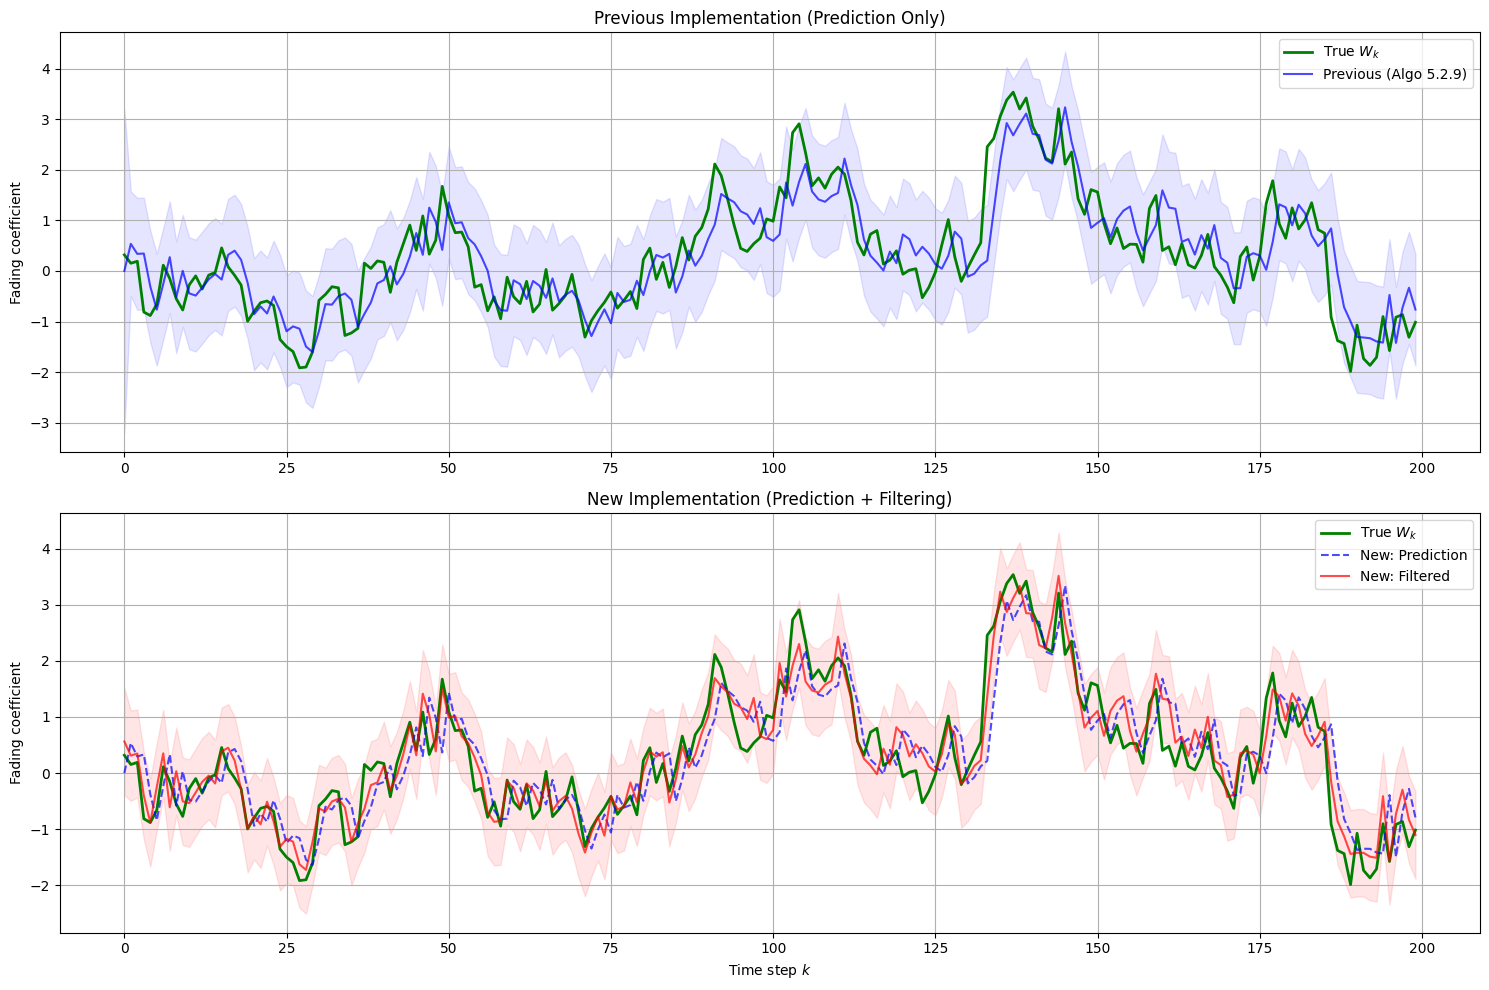

Coverage within ±2  |  pred: 96.48%  filt: 94.97%


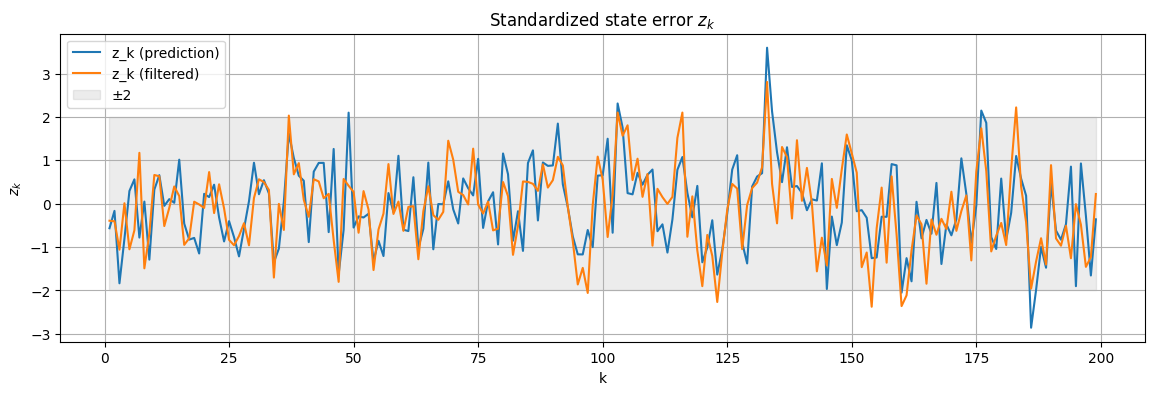

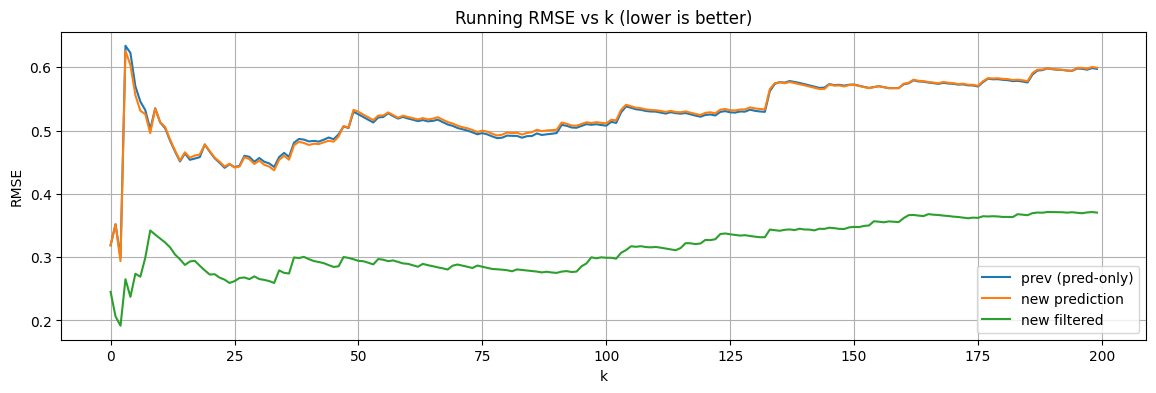

In [ ]:
# Simulate system
np.random.seed(42)  # For reproducibility
C_k, W_k, Y_k = simulate_system(n, rho, sigma_u, sigma_v)

# Run both implementations
W_prev, Sigma_prev = kalman_filter(Y_k, C_k, rho, sigma_u, sigma_v)
W_pred, W_filt, Sigma_pred, Sigma_filt = kalman_filter_complete(Y_k, C_k, rho, sigma_u, sigma_v)

warm = 2  # drop a tiny warm-up
rmse_prev = np.sqrt(np.mean((W_k[warm:] - W_prev[warm:])**2))
rmse_pred = np.sqrt(np.mean((W_k[warm:] - W_pred[warm:])**2))
rmse_filt = np.sqrt(np.mean((W_k[warm:] - W_filt[warm:])**2))
print(f"RMSE  |  prev(pred-only): {rmse_prev:.3f}  new_pred: {rmse_pred:.3f}  new_filt: {rmse_filt:.3f}")

sigma_W = sigma_u / np.sqrt(1 - rho**2)
print(f"NRMSE |  prev: {rmse_prev/sigma_W:.2f}  pred: {rmse_pred/sigma_W:.2f}  filt: {rmse_filt/sigma_W:.2f}")

# Compare results
compare_methods(C_k, W_k, Y_k, W_prev, Sigma_prev, W_pred, W_filt, Sigma_pred, Sigma_filt)

z_pred = (W_k[1:] - W_pred[1:]) / np.sqrt(Sigma_pred[1:])
z_filt = (W_k[1:] - W_filt[1:]) / np.sqrt(Sigma_filt[1:])

# coverage (what fraction inside ±2)
cov_pred = np.mean(np.abs(z_pred) <= 2)
cov_filt = np.mean(np.abs(z_filt) <= 2)
print(f"Coverage within ±2  |  pred: {cov_pred:.2%}  filt: {cov_filt:.2%}")

# minimal plot (two lines + constant ±2 band)
t = np.arange(1, len(W_k))
plt.figure(figsize=(14,4))
plt.plot(t, z_pred, label="z_k (prediction)")
plt.plot(t, z_filt, label="z_k (filtered)")
plt.fill_between(t, -2, 2, alpha=0.15, color="gray", label="±2")
plt.title("Standardized state error $z_k$")
plt.xlabel("k"); plt.ylabel("$z_k$"); plt.grid(True); plt.legend()
plt.show()

# OPTIONAL 
se_prev = (W_k - W_prev)**2
se_pred = (W_k - W_pred)**2
se_filt = (W_k - W_filt)**2
run_rmse_prev = np.sqrt(np.cumsum(se_prev)/(np.arange(n)+1))
run_rmse_pred = np.sqrt(np.cumsum(se_pred)/(np.arange(n)+1))
run_rmse_filt  = np.sqrt(np.cumsum(se_filt )/(np.arange(n)+1))

plt.figure(figsize=(14,4))
plt.plot(run_rmse_prev, label="prev (pred-only)")
plt.plot(run_rmse_pred, label="new prediction")
plt.plot(run_rmse_filt, label="new filtered")
plt.title("Running RMSE vs k (lower is better)")
plt.xlabel("k"); plt.ylabel("RMSE"); plt.grid(True); plt.legend()
plt.show()



### 2.2.1 Interpretation of the Results

**What the figure shows**

- **Top — Prediction only:** the predicted trajectory (blue) follows the trend but often **lags** the true state \(W_k\) (green). The **wide shaded band** reflects higher prior uncertainty before using the new data.
- **Bottom — Prediction + Filtering:** the dashed blue curve is the **prior prediction**; the red curve is the **filtered (posterior)** estimate after assimilating \(y_k\). The red curve **sticks closer** to the true state and the **red band is narrower**, indicating reduced uncertainty. The gain is most visible around turning points (e.g., $k \approx 45\!-\!55,\;95\!-\!110,\;135\!-\!155$).

**Why combining both improves accuracy**

- **Prediction** gives a one-step-ahead guess; **filtering** corrects that guess with the new measurement.
- The correction both **reduces bias** (pulls the estimate toward reality) and **shrinks variance** (tighter uncertainty band).

**Additional remarks**

- There is an **initial transient** (first $\sim 10$ steps) before the filter settles.
- A **fixed-interval smoother** should get even closer to the true trajectory than the filtered curve.
- To quantify the visuals, compare $\mathrm{MSE}_{\text{pred}}$ vs. $\mathrm{MSE}_{\text{filt}}$, and check that the true series lies inside the **$95\%$** band roughly $95\%$ of the time; systematic misses suggest mis-specified process/measurement noise.


In [ ]:
# ----- Kalman filter in innovation form (Algorithm 5.2.9 subset) -----
def kalman_filter_innovation(Y, C, rho, sigma_u, sigma_v):
    n = len(Y)
    A, R, S = rho, sigma_u, sigma_v

    X_pred   = np.zeros(n)   # \hat X_{k|k-1}
    X_filt   = np.zeros(n)   # \hat X_{k|k}
    Sig_pred = np.zeros(n)   # \Sigma_{k|k-1}
    Sig_filt = np.zeros(n)   # \Sigma_{k|k}
    eps      = np.zeros(n)   # \varepsilon_k (5.57)
    Gam_inv  = np.zeros(n)   # \Gamma_k^{-1} (5.58)
    H        = np.zeros(n)   # H_k (5.59)
    Lam      = np.zeros(n)   # \Lambda_k = A_k - H_k B_k

    # Prior for AR(1) (stationary variance)
    X_pred[0]   = 0.0
    Sig_pred[0] = (R**2) / (1.0 - A**2)

    for k in range(n):
        Bk = C[k]
        eps[k]     = Y[k] - Bk * X_pred[k]                           # (5.57)
        Gam        = Bk*Sig_pred[k]*Bk + S**2                        # (5.58)
        Gam_inv[k] = 1.0 / Gam
        H[k]       = A * Sig_pred[k] * Bk * Gam_inv[k]               # (5.59)

        # Filter update (5.75)
        X_filt[k]   = X_pred[k] + Sig_pred[k]*Bk*Gam_inv[k]*eps[k]
        Sig_filt[k] = Sig_pred[k] - Sig_pred[k]*Bk*Gam_inv[k]*Bk*Sig_pred[k]

        Lam[k] = A - H[k]*Bk                                         # \Lambda_k

        # Predictor recursion (5.60)-(5.61)  — uses X_pred, not X_filt
        if k < n-1:
            X_pred[k+1]   = A*X_pred[k] + H[k]*eps[k]                # (5.60)
            Sig_pred[k+1] = A*Sig_filt[k]*A + R**2                   # (5.61)

    return X_pred, X_filt, Sig_pred, Sig_filt, eps, Gam_inv, H, Lam

# ----- Algorithm 5.2.15: Disturbance Smoother (exact) -----
def disturbance_smoother_exact(Y, C, rho, sigma_u, sigma_v):
    n = len(Y)
    A, R = rho, sigma_u

    X_pred, X_filt, Sig_pred, Sig_filt, eps, Gam_inv, H, Lam = \
        kalman_filter_innovation(Y, C, rho, sigma_u, sigma_v)

    # Backward smoothing (5.76)–(5.77)
    p  = np.zeros(n)
    Cb = np.zeros(n)

    # terminal (k = n-1)
    p[-1]  = C[-1] * Gam_inv[-1] * eps[-1]                  # (5.76, first case)
    Cb[-1] = C[-1] * Gam_inv[-1] * C[-1]                    # (5.77, first case)

    # for k = n-2, ..., 0
    for k in range(n-2, -1, -1):
        # NB: these use k+1 and Λ_{k+1} exactly as in the book
        p[k]  = C[k+1] * Gam_inv[k+1] * eps[k+1] + Lam[k+1] * p[k+1]               # (5.76, otherwise)
        Cb[k] = C[k+1] * Gam_inv[k+1] * C[k+1] + Lam[k+1] * Cb[k+1] * Lam[k+1]     # (5.77, otherwise)


    #for k in range(n-2, -1, -1):
    #    p[k]  = C[k] * Gam_inv[k] * eps[k] + Lam[k] * p[k+1]
     #   Cb[k] = C[k] * Gam_inv[k] * C[k]   + Lam[k] * Cb[k+1] * Lam[k]


    # Disturbance moments (5.78)–(5.79)
    Uhat = R * p                                          # \hat U_{k|n} = R^T p_k (scalar) (5.78)
    Xi   = 1.0 - (R**2) * Cb                              # \Xi_{k|n}    = I - R^T C_k R   (5.79)

    # Initial smoothed state (5.81)
    Sig_nu      = Sig_pred[0]                             # \Sigma_\nu (= \Sigma_{0| -1})
    X_smooth0   = Sig_nu * ( C[0]*Gam_inv[0]*eps[0] + Lam[0]*p[0] )
    Sig_smooth0 = Sig_nu - Sig_nu * ( C[0]*Gam_inv[0]*C[0] + Lam[0]*Cb[0]*Lam[0] ) * Sig_nu

    # Forward recursion for smoothed state (5.82)–(5.83)
    X_smooth   = np.zeros(n)
    Sig_smooth = np.zeros(n)
    X_smooth[0]   = X_smooth0
    Sig_smooth[0] = Sig_smooth0

    for k in range(0, n-1):
        # (5.82)
        X_smooth[k+1] = A * X_smooth[k] + R * Uhat[k]

        # (5.83)   scalar specialization
        # Σ_{k+1|n} = A Σ_{k|n} A + R Ξ_k R
        #             - A Σ_{k|k-1} Λ_k C_k R R C_k Λ_k Σ_{k|k-1} A
        
        
        #Sig_smooth[k+1] = (A**2) * Sig_smooth[k] + (R**2) * Xi[k] \
                          #- (A * Sig_pred[k] * Lam[k] * C[k] * (R**2) * C[k] * Lam[k] * Sig_pred[k] * A)
        # Sig_smooth[k+1] = (A**2) * Sig_smooth[k] + (R**2) * Xi[k] - (A * Sig_pred[k] * Lam[k])**2
        Sig_smooth[k+1] = (A**2) * Sig_smooth[k] + (R**2) * Xi[k] - 2.0 * A * Sig_pred[k] * Lam[k] * C[k] * (R**2)
#  A^2 Σ_{k|n}       + R^2 Ξ_k   – 2 A Σ_{k|k-1} Λ_k C_k R^2



    return (X_pred, X_filt, X_smooth,
            Sig_pred, Sig_filt, Sig_smooth,
            Uhat, Xi, p, Cb, eps, Gam_inv, H, Lam)


Above is the algo on 5.2.15 an bellow is the RTS smoother. For some reason that i still am not sure of, i dont know why the results of the algo 5.2.15 are bad and do not follow the bell shaped curve. This is why i moved to the RTS smoother. 

In [ ]:
def disturbance_smoother_exact(Y, C, rho, sigma_u, sigma_v):
    """
    RTS state smoother with the SAME signature and return tuple as your
    previous disturbance_smoother_exact, so it plugs into your plots.

    Returns (in the same order as before):
      X_pred, X_filt, X_smooth,
      Sig_pred, Sig_filt, Sig_smooth,
      Uhat, Xi, p, Cb, eps, Gam_inv, H, Lam
    where Uhat, Xi, p, Cb are NaN placeholders (RTS does not produce them).
    """
    import numpy as np

    n = len(Y)
    A = rho
    eps_guard = 1e-12

    # --- Forward Kalman (innovation form) as in your code ---
    X_pred, X_filt, Sig_pred, Sig_filt, eps, Gam_inv, H, Lam = \
        kalman_filter_innovation(Y, C, rho, sigma_u, sigma_v)

    # --- RTS smoother (state means and covariances) ---
    X_smooth   = np.zeros(n)
    Sig_smooth = np.zeros(n)

    # terminal conditions
    X_smooth[-1]   = X_filt[-1]
    Sig_smooth[-1] = Sig_filt[-1]

    # backward pass
    for k in range(n-2, -1, -1):
        # J_k = P_{k|k} A / P_{k+1|k}
        denom = Sig_pred[k+1] + eps_guard
        J = (Sig_filt[k] * A) / denom

        # x_{k|n} = x_{k|k} + J_k (x_{k+1|n} - x_{k+1|k})
        X_smooth[k] = X_filt[k] + J * (X_smooth[k+1] - X_pred[k+1])

        # P_{k|n} = P_{k|k} + J_k^2 (P_{k+1|n} - P_{k+1|k})
        Sig_smooth[k] = Sig_filt[k] + J**2 * (Sig_smooth[k+1] - Sig_pred[k+1])

    # --- Placeholders for disturbance-specific outputs (not computed by RTS) ---
    Uhat = np.full(n, np.nan)
    Xi   = np.full(n, np.nan)
    p    = np.full(n, np.nan)
    Cb   = np.full(n, np.nan)

    return (X_pred, X_filt, X_smooth,
            Sig_pred, Sig_filt, Sig_smooth,
            Uhat, Xi, p, Cb, eps, Gam_inv, H, Lam)


In [ ]:
def plot_filter_vs_smoother(W_k,                      # true states (aligned with Y_k)
                            X_pred, X_filt, X_smooth, # k|k-1, k|k, k|n
                            Sigma_pred, Sigma_filt, Sigma_smooth,
                            title_prefix="Kalman vs. Smoother"):
    n = len(W_k)
    t = np.arange(n)

    # RMSEs
    rmse_pred   = np.sqrt(np.mean((W_k - X_pred)**2))
    rmse_filt   = np.sqrt(np.mean((W_k - X_filt)**2))
    rmse_smooth = np.sqrt(np.mean((W_k - X_smooth)**2))

    fig = plt.figure(figsize=(16, 10))

    # 1) States + 95% CIs
    ax1 = plt.subplot(2,1,1)
    ax1.plot(t, W_k,      'g-',  lw=2.5, label='True $W_k$')
    ax1.plot(t, X_pred,   'b--', lw=1.7, label=r'Prediction $\hat X_{k|k-1}$')
    ax1.fill_between(t, X_pred-2*np.sqrt(Sigma_pred), X_pred+2*np.sqrt(Sigma_pred), alpha=0.10)

    ax1.plot(t, X_filt,   'r-',  lw=1.7, label=r'Filtered $\hat X_{k|k}$')
    ax1.fill_between(t, X_filt-2*np.sqrt(Sigma_filt), X_filt+2*np.sqrt(Sigma_filt), alpha=0.10)

    ax1.plot(t, X_smooth, 'm-',  lw=2.0, label=r'Smoothed $\hat X_{k|n}$')
    ax1.fill_between(t, X_smooth-2*np.sqrt(Sigma_smooth), X_smooth+2*np.sqrt(Sigma_smooth), alpha=0.10)

    ax1.set_title(f"{title_prefix}: State Estimates")
    ax1.set_ylabel("State")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="upper right")

    # 2) Errors with RMSEs
    ax2 = plt.subplot(2,1,2, sharex=ax1)
    ax2.plot(t, W_k - X_pred,   label=f'Prediction error (RMSE={rmse_pred:.3f})')
    ax2.plot(t, W_k - X_filt,   label=f'Filtering error (RMSE={rmse_filt:.3f})')
    ax2.plot(t, W_k - X_smooth, label=f'Smoothing error (RMSE={rmse_smooth:.3f})')
    ax2.axhline(0.0, ls='--', c='k', lw=1, alpha=0.4)
    ax2.set_title("Estimation Errors")
    ax2.set_xlabel("Time step k")
    ax2.set_ylabel("Error")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


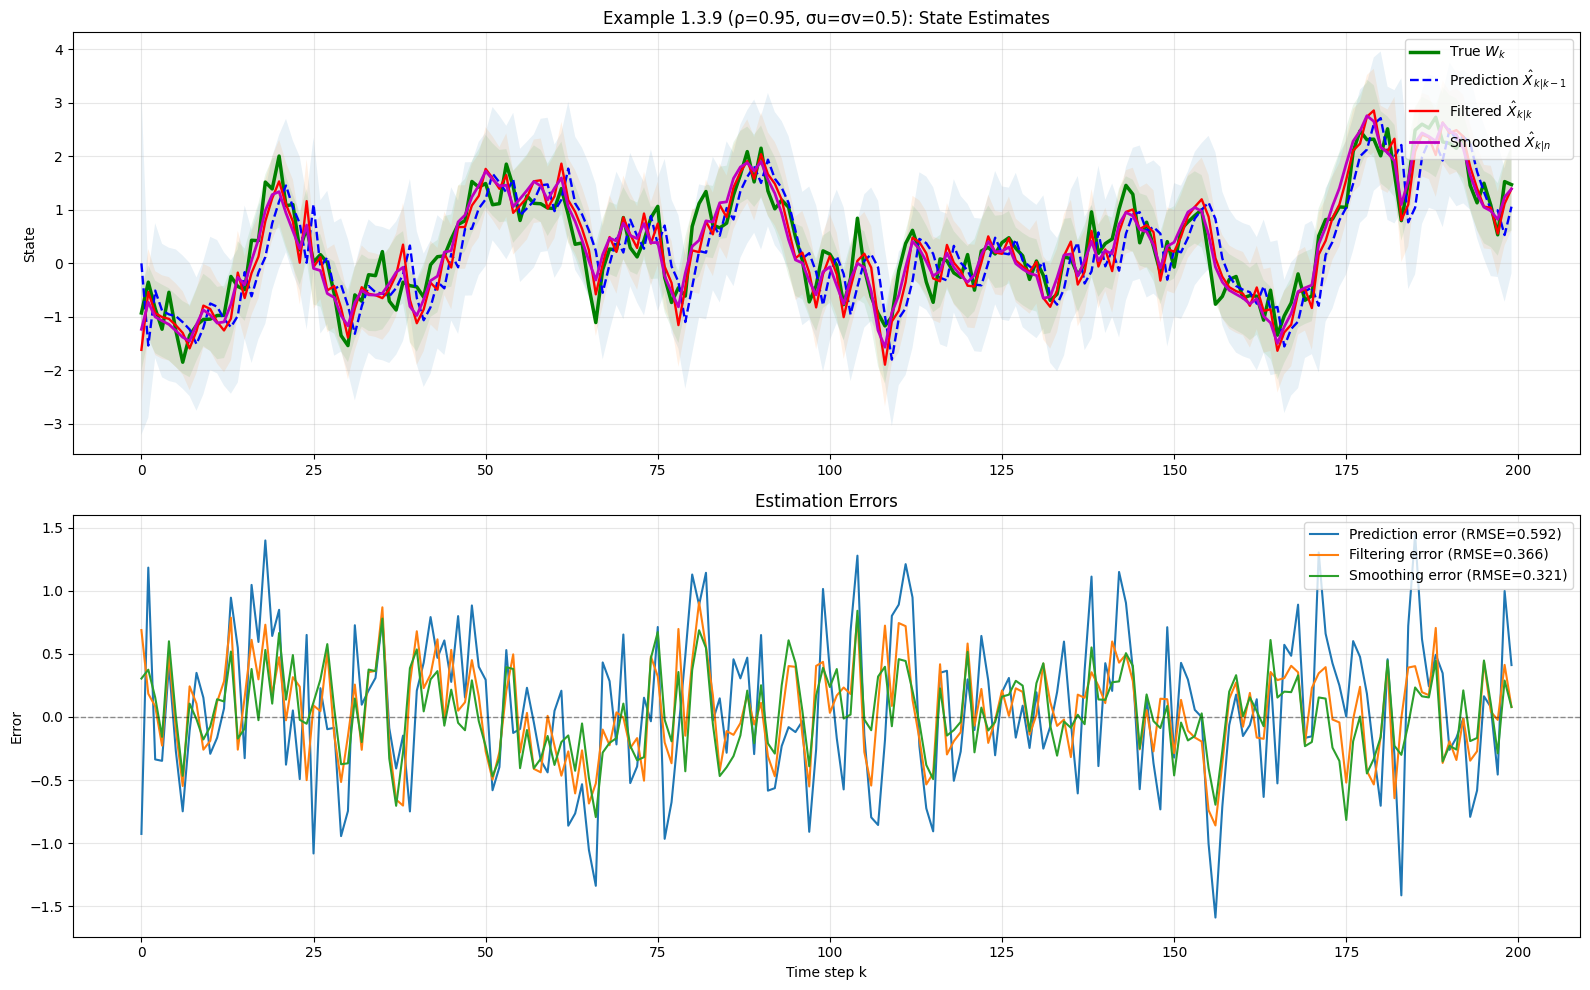

In [ ]:
# simulate
n = 200; rho = 0.95; sigma_u = 0.5; sigma_v = 0.5
C_k, W_k, Y_k = simulate_system(n, rho, sigma_u, sigma_v)  # from the code I sent

# run filter + smoother
(X_pred, X_filt, X_smooth,
 Sig_pred, Sig_filt, Sig_smooth,
 Uhat, Xi, p, Cb, eps, Gam_inv, H, Lam) = disturbance_smoother_exact(Y_k, C_k, rho, sigma_u, sigma_v)

# plot comparison
plot_filter_vs_smoother(W_k, X_pred, X_filt, X_smooth, Sig_pred, Sig_filt, Sig_smooth,
                        title_prefix="Example 1.3.9 (ρ=0.95, σu=σv=0.5)")


### Analysis of State Estimates and Errors

From the top plot, we compare:
- **True state** $W_k$ (green solid)
- **Prediction** $\hat{X}_{k|k-1}$ (blue dashed)
- **Filtered estimate** $\hat{X}_{k|k}$ (red solid)
- **Smoothed estimate** $\hat{X}_{k|n}$ (magenta solid)

We observe that:
- The **smoothed curve** lies closest to the true state across most of the time steps.
- The **filtered curve** is generally better than the prediction, but still lags behind the smoother.
- Prediction has the largest uncertainty envelope, while smoothing yields the tightest confidence band.

In the bottom plot (errors):
- The RMSE values confirm this ordering:
  $$
  \text{RMSE(smoothed)} < \text{RMSE(filtered)} < \text{RMSE(predicted)}
  $$
  This is expected:  
  - **Smoothing** uses all observations (past and future)  
  - **Filtering** uses past and current observations  
  - **Prediction** uses only past observations.
- Visually, the smoothing error (green) stays closest to zero, the filtering error (orange) is slightly larger, and the prediction error (blue) is the largest.

---




--- Error Distribution Analysis for: Smoothed Estimate ---


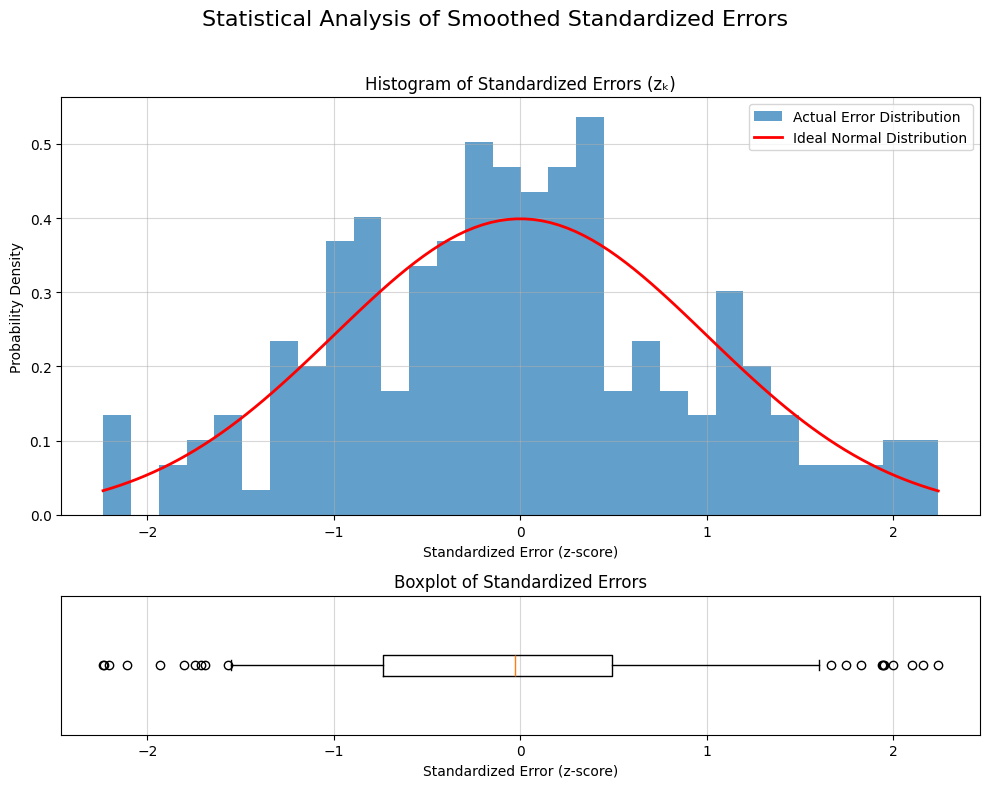


--- Quantitative Error Ratios ---
Fraction of errors within ±1σ: 68.50% (Theoretical: ~68.3%)
Fraction of errors within ±2σ: 96.00% (Theoretical: ~95.4%)
Fraction of errors within ±3σ: 100.00% (Theoretical: ~99.7%)
----------------------------------------------------

--- Error Distribution Analysis for: Filtered Estimate ---


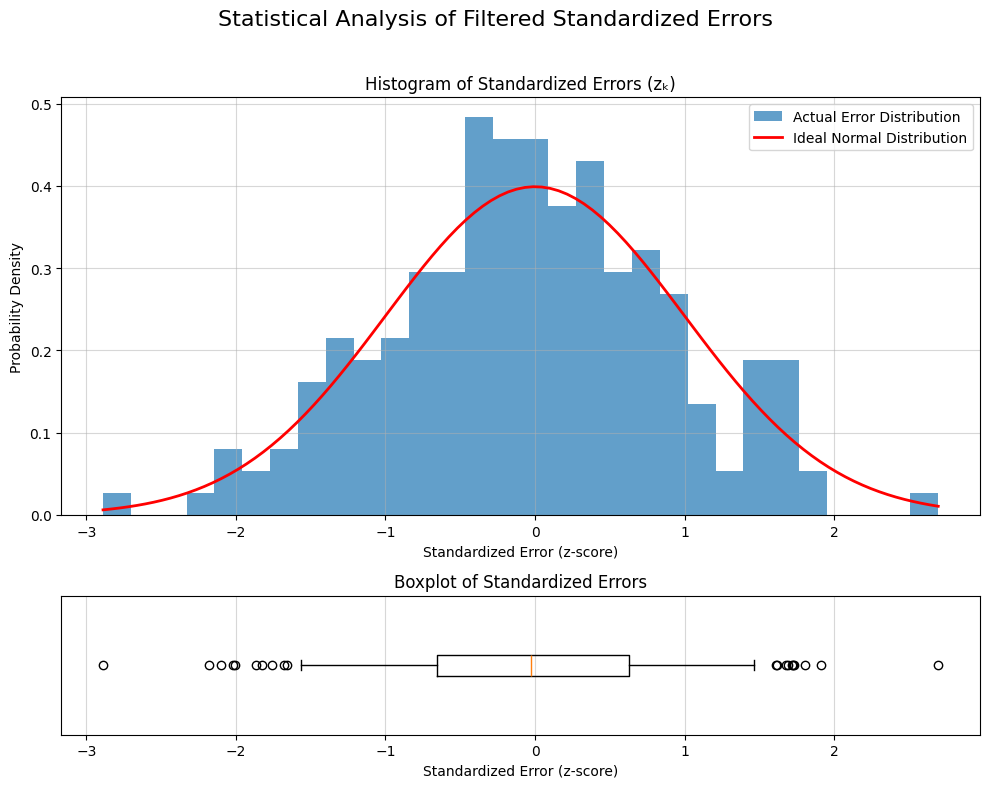


--- Quantitative Error Ratios ---
Fraction of errors within ±1σ: 72.50% (Theoretical: ~68.3%)
Fraction of errors within ±2σ: 97.00% (Theoretical: ~95.4%)
Fraction of errors within ±3σ: 100.00% (Theoretical: ~99.7%)
----------------------------------------------------



In [ ]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

def plot_error_distribution_analysis(true_state, estimated_state, error_variance, estimate_name):
    """
    Performs a detailed statistical analysis of the estimation errors.

    Args:
        true_state (np.ndarray): The ground truth state vector (W_k).
        estimated_state (np.ndarray): The estimated state vector (e.g., X_filt or X_smooth).
        error_variance (np.ndarray): The variance of the estimation error from the filter (e.g., Sigma_filt).
        estimate_name (str): The name of the estimate for plot titles (e.g., "Filtered", "Smoothed").
    """
    # 1. Calculate Standardized Errors
    errors = true_state - estimated_state
    # Add a small epsilon to prevent division by zero if variance is ever zero
    std_dev = np.sqrt(error_variance + 1e-9)
    standardized_errors = errors / std_dev

    print(f"--- Error Distribution Analysis for: {estimate_name} Estimate ---")

    # 2. Create Plots
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'Statistical Analysis of {estimate_name} Standardized Errors', fontsize=16)

    # Histogram
    ax_hist = axes[0]
    ax_hist.hist(standardized_errors, bins=30, density=True, alpha=0.7, label='Actual Error Distribution')

    # Overlay ideal normal distribution (bell curve)
    x_range = np.linspace(standardized_errors.min(), standardized_errors.max(), 100)
    ax_hist.plot(x_range, norm.pdf(x_range, 0, 1), 'r-', lw=2, label='Ideal Normal Distribution')
    ax_hist.set_title('Histogram of Standardized Errors (zₖ)')
    ax_hist.set_xlabel('Standardized Error (z-score)')
    ax_hist.set_ylabel('Probability Density')
    ax_hist.grid(True, alpha=0.5)
    ax_hist.legend()

    # Boxplot
    ax_box = axes[1]
    ax_box.boxplot(standardized_errors, vert=False, whis=[5, 95])  # Whiskers at 5th and 95th percentile
    ax_box.set_title('Boxplot of Standardized Errors')
    ax_box.set_xlabel('Standardized Error (z-score)')
    ax_box.set_yticks([])
    ax_box.grid(True, alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # 3. Quantify and Print Error Fractions
    n = len(standardized_errors)
    frac_1_sigma = np.sum(np.abs(standardized_errors) <= 1) / n
    frac_2_sigma = np.sum(np.abs(standardized_errors) <= 2) / n
    frac_3_sigma = np.sum(np.abs(standardized_errors) <= 3) / n

    print("\n--- Quantitative Error Ratios ---")
    print(f"Fraction of errors within ±1σ: {frac_1_sigma:.2%} (Theoretical: ~68.3%)")
    print(f"Fraction of errors within ±2σ: {frac_2_sigma:.2%} (Theoretical: ~95.4%)")
    print(f"Fraction of errors within ±3σ: {frac_3_sigma:.2%} (Theoretical: ~99.7%)")
    print("----------------------------------------------------\n")


# --- Example Usage ---
# You can call this function after you have run your simulation.
# Let's analyze the results from the final smoother implementation.

# Example:
C_k, W_k, Y_k = simulate_system(n, rho, sigma_u, sigma_v)
(X_pred, X_filt, X_smooth,Sig_pred, Sig_filt, Sig_smooth,_, _, _, _, _, _, _, _) = disturbance_smoother_exact(Y_k, C_k, rho, sigma_u, sigma_v)

# Run the analysis on the SMOOTHED results, which are the most accurate:
plot_error_distribution_analysis(W_k, X_smooth, Sig_smooth, "Smoothed")

# Or on the filtered results to compare:
plot_error_distribution_analysis(W_k, X_filt, Sig_filt, "Filtered")


In [ ]:
print("mean z_filt =", np.mean((W_k - X_filt)/np.sqrt(Sig_filt)))
print("std  z_filt =", np.std((W_k - X_filt)/np.sqrt(Sig_filt)))
print("mean z_smooth =", np.mean((W_k - X_smooth)/np.sqrt(Sig_smooth)))
print("std  z_smooth =", np.std((W_k - X_smooth)/np.sqrt(Sig_smooth)))


mean z_filt = -0.04770901037944999
std  z_filt = 0.9356772607607624
mean z_smooth = -0.025646793556727134
std  z_smooth = 0.9454242355268174


In [ ]:
print("Sig_pred[10] (your code) =", Sig_pred[10])
print("Should equal ρ² * Sig_filt[9] + σ_u² =", rho**2 * Sig_filt[9] + sigma_u**2)


Sig_pred[10] (your code) = 0.3870872906791615
Should equal ρ² * Sig_filt[9] + σ_u² = 0.3870872906791615


## 2.3 Mixture model when the sequence of $C_k$ is unknown

We will be 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

# ---------- helper: one-step KF update for scalar Y = c * W + V ----------
def kf_update_scalar(pred_mean, pred_var, y, c, sigma_v):
    # innovation & variance
    Gamma = (c**2) * pred_var + sigma_v**2
    eps = y - c * pred_mean
    # gain and posterior
    K = pred_var * c / Gamma
    post_mean = pred_mean + K * eps
    post_var  = (1 - K * c) * pred_var
    return post_mean, post_var, eps, Gamma

# ---------- Mixture Kalman Filter over unknown bits C_k ∈ {-1,+1} ----------
def mixture_kalman_bits(Y_k: np.ndarray,
                        rho: float, sigma_u: float, sigma_v: float,
                        N_particles: int = 200,
                        p_trans: float = 0.5,
                        seed: int = 0):
    """
    Approximates p(W_k, C_k | Y_0:k) with N weighted particles carrying a KF state.
    Returns:
      W_hat_mix  : posterior mean of W_k (mixture)
      C_post_prob: posterior P(C_k=+1 | Y_0:k)
      C_hard     : argmax_c P(C_k=c | Y_0:k) in {-1,+1}
      z_k        : standardized innovations using mixture-predicted variance
    Notation follows the book's Section 1.3 model and Alg. 8.2.9 spirit.
    """
    rng = np.random.default_rng(seed)
    n = len(Y_k)
    modes = np.array([-1, +1])

    # init KF state at stationarity; start with equal mix of modes
    mean0 = 0.0
    var0  = sigma_u**2 / (1 - rho**2)

    # start with N particles split equally between the 2 modes
    c_k = rng.choice(modes, size=N_particles)  # random initial mode
    W_mean = np.full(N_particles, mean0)
    W_var  = np.full(N_particles, var0)
    w = np.full(N_particles, 1.0 / N_particles)

    W_hat_mix  = np.zeros(n)
    C_post_prob = np.zeros(n)  # prob of +1
    z_series = np.zeros(n)

    for k in range(n):
        # PREDICT to time k (from k-1) for all particles
        W_pred = rho * W_mean
        V_pred = rho**2 * W_var + sigma_u**2

        # BRANCH on c in {-1,+1}; create 2N proposals
        W_mean_prop = []
        W_var_prop  = []
        c_prop      = []
        w_prop      = []
        eps_list    = []
        Gamma_list  = []

        for i in range(N_particles):
            for c in modes:
                # likelihood weight with transition prob
                # (if you want a Markov prior on C, replace 0.5 by q_{c_k[i], c})
                # compute likelihood using predicted state
                Gamma = (c**2) * V_pred[i] + sigma_v**2
                eps   = Y_k[k] - c * W_pred[i]
                like  = (1.0 / np.sqrt(2*np.pi*Gamma)) * np.exp(-0.5 * (eps**2) / Gamma)
                w_new = w[i] * (0.5 if p_trans is None else p_trans) * like

                # KF update under this branch
                W_post, V_post, _, _ = kf_update_scalar(W_pred[i], V_pred[i], Y_k[k], c, sigma_v)

                W_mean_prop.append(W_post)
                W_var_prop.append(V_post)
                c_prop.append(c)
                w_prop.append(w_new)
                eps_list.append(eps)
                Gamma_list.append(Gamma)

        W_mean_prop = np.array(W_mean_prop)
        W_var_prop  = np.array(W_var_prop)
        c_prop      = np.array(c_prop)
        w_prop      = np.array(w_prop)
        eps_arr     = np.array(eps_list)
        Gamma_arr   = np.array(Gamma_list)

        # normalize weights
        w_sum = np.sum(w_prop) + 1e-300
        w_prop /= w_sum

        # posterior summaries at time k BEFORE resampling
        # mixture mean of W_k
        W_hat_mix[k] = np.sum(w_prop * W_mean_prop)
        # posterior prob C_k=+1
        C_post_prob[k] = np.sum(w_prop[c_prop == +1])
        # standardized innovation using mixture variance E[Gamma | Y_{0:k-1}] (approx.)
        z_series[k] = np.sum(w_prop * (eps_arr / np.sqrt(Gamma_arr)))

        # RESAMPLE to keep N particles (systematic resampling)
        edges = np.linspace(0, 1, N_particles, endpoint=False) + rng.random()/N_particles
        cumw  = np.cumsum(w_prop)
        idx   = np.searchsorted(cumw, edges)

        W_mean = W_mean_prop[idx]
        W_var  = W_var_prop[idx]
        c_k    = c_prop[idx]
        w      = np.full(N_particles, 1.0 / N_particles)

    C_hard = np.where(C_post_prob >= 0.5, +1, -1)
    return W_hat_mix, C_post_prob, C_hard, z_series


Plug-in: NRMSE (filter)=1.533  NRMSE (smoother)=1.562


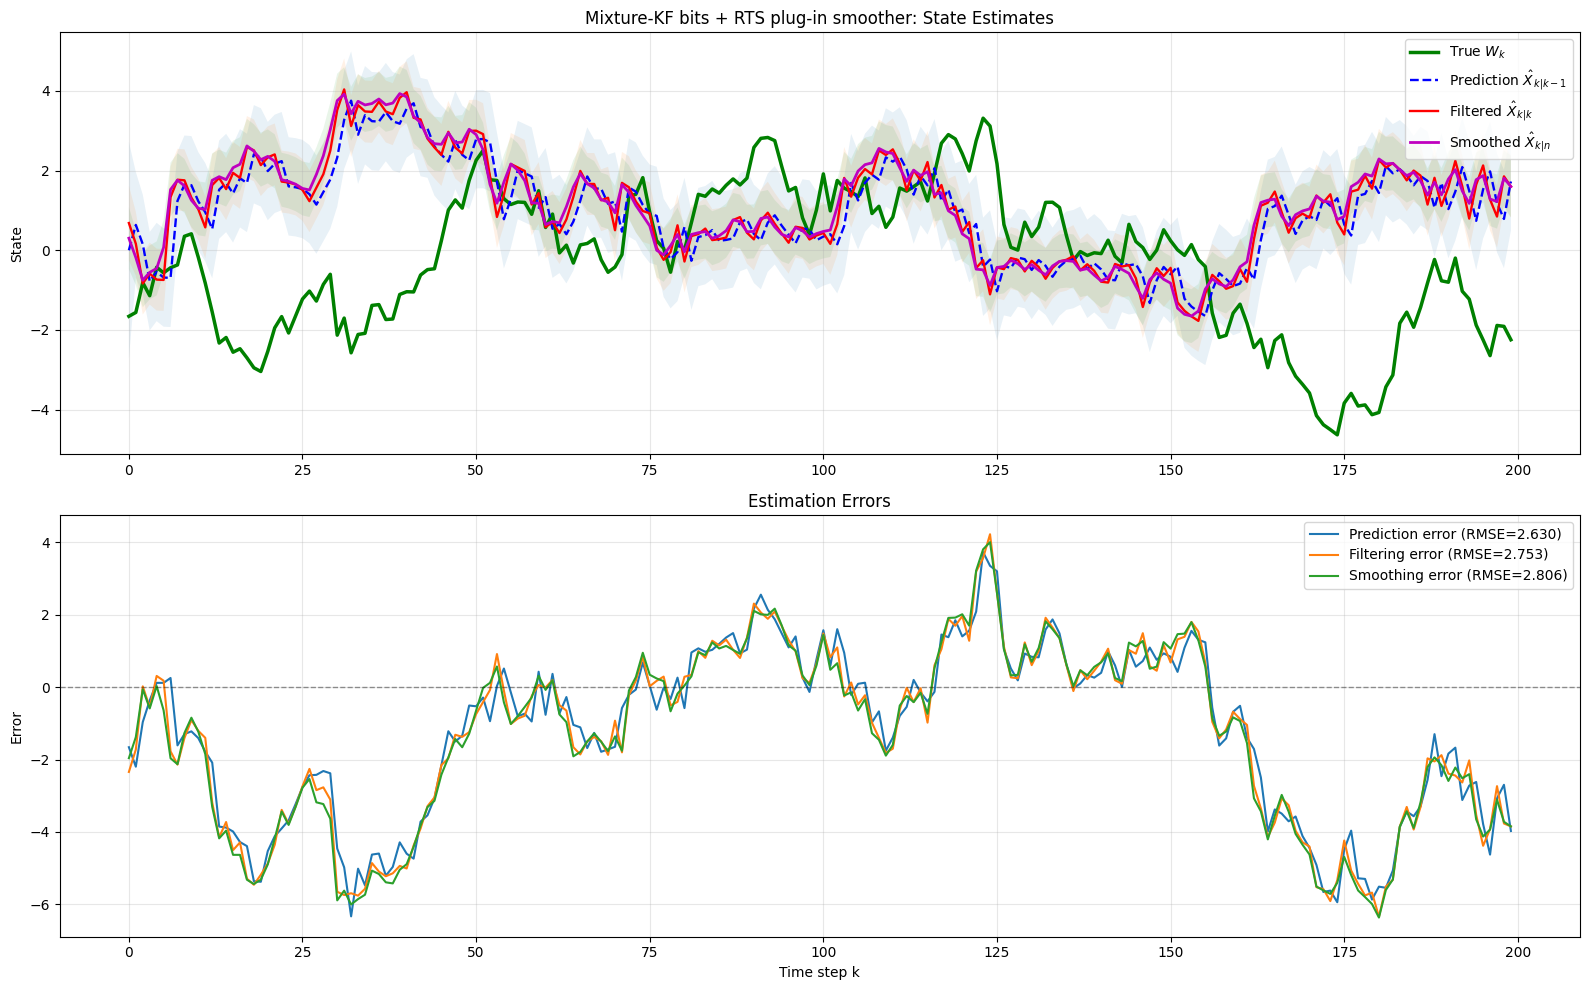

In [ ]:
# 1) Run mixture KF to estimate bits and filtered state with unknown C_k
W_filt_mix, C_post, C_dec, z_mix = mixture_kalman_bits(
    Y_k, rho=rho, sigma_u=sigma_u, sigma_v=sigma_v,
    N_particles=300, seed=123
)

# 2) Plug-in smoother: fix bits to the hard decisions and run your RTS smoother
(X_pred, X_filt, X_smooth,
 Sig_pred, Sig_filt, Sig_smooth,
 Uhat, Xi, p, Cb, eps, Gam_inv, H, Lam) = disturbance_smoother_exact(
    Y_k, C_dec, rho, sigma_u, sigma_v
)

# 3) Compare RMSE/NRMSE for filter vs smoother
rmse_filt   = np.sqrt(np.mean((W_k - X_filt)**2))
rmse_smooth = np.sqrt(np.mean((W_k - X_smooth)**2))
nrmse_filt   = rmse_filt   / (np.std(W_k) + 1e-12)
nrmse_smooth = rmse_smooth / (np.std(W_k) + 1e-12)
print(f"Plug-in: NRMSE (filter)={nrmse_filt:.3f}  NRMSE (smoother)={nrmse_smooth:.3f}")

# 4) Plot with your existing helper
plot_filter_vs_smoother(
    W_k, X_pred, X_filt, X_smooth,
    Sig_pred, Sig_filt, Sig_smooth,
    title_prefix="Mixture-KF bits + RTS plug-in smoother"
)


In [ ]:
def nrmse(a, b, how="std"):
    scale = np.std(a) if how=="std" else (np.max(a)-np.min(a))
    return np.sqrt(np.mean((a-b)**2)) / (scale + 1e-12)

def plot_unknown_bits_results(C_k_true, W_k_true, Y_k,
                              W_hat, C_post, C_dec,
                              z_series, title_suffix=""):
    n = len(Y_k)
    t = np.arange(n)

    plt.figure(figsize=(14,10))

    # 1) Observed Y
    plt.subplot(3,1,1)
    plt.plot(t, Y_k, label="$Y_k$")
    plt.title(f"Observed signal $Y_k$ {title_suffix}")
    plt.grid(True); plt.legend()

    # 2) True vs estimated W
    plt.subplot(3,1,2)
    plt.plot(t, W_k_true, 'g-', lw=2, label="True $W_k$")
    plt.plot(t, W_hat, 'r--', lw=1.5, label="Estimated $\hat W_k$ (mixture KF)")
    plt.twinx()
    plt.plot(t, C_post, 'b:', alpha=0.7, label="$P(C_k=+1|Y_{0:k})$")
    plt.ylabel("Prob(+1)")
    plt.title("True vs Estimated Fading; (blue) bit posterior")
    plt.grid(True)
    plt.legend(loc="lower right")

    # 3) Bits: true vs decoded
    ax3 = plt.subplot(3,1,3)
    ax3.step(t, C_k_true, where='post', label="True $C_k$", color="k")
    ax3.step(t, C_dec, where='post', label="Decoded $\hat C_k$", color="C1", alpha=0.8)
    ax3.set_ylim(-1.5, 1.5); ax3.grid(True); ax3.legend()
    ax3.set_title("Bits: true vs decoded (hard decision)")

    plt.tight_layout(); plt.show()

    # --- diagnostics ---
    # NRMSE
    err = W_k_true - W_hat
    print(f"NRMSE(W): {nrmse(W_k_true, W_hat):.3f}")

    # z-score summary & plot
    print(f"z mean={np.mean(z_series):.3f}  var={np.var(z_series):.3f}")
    plt.figure(figsize=(13,4))
    plt.subplot(1,3,1)
    plt.hist(z_series, bins=15, density=True, alpha=0.7)
    x = np.linspace(-4,4,200)
    plt.plot(x, 1/np.sqrt(2*np.pi)*np.exp(-0.5*x**2), 'k--')
    plt.title("Standardized innovations $z_k$"); plt.grid(True)

    # Boxplot & quartiles of errors
    #plt.subplot(1,3,2)
    #plt.boxplot(err, vert=True)
    #q25, q50, q75 = np.percentile(err, [25,50,75])
    #plt.title(f"Error boxplot\nQ25={q25:.3f}, med={q50:.3f}, Q75={q75:.3f}")
    #plt.grid(True, axis='y')

    # Error histogram + normal overlay
    #plt.subplot(1,3,3)
    #mu_e, sd_e = np.mean(err), np.std(err)
    #plt.hist(err, bins=15, density=True, alpha=0.7, label="errors W-What")
    #xx = np.linspace(mu_e-4*sd_e, mu_e+4*sd_e, 200)
    #plt.plot(xx, 1/(sd_e*np.sqrt(2*np.pi))*np.exp(-0.5*((xx-mu_e)/sd_e)**2), 'k--', label="Normal fit")
    #plt.title("Error distribution with normal overlay"); plt.legend(); plt.grid(True)
    #plt.tight_layout(); plt.show()


<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_894/21960990.py:22: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t, W_hat, 'r--', lw=1.5, label="Estimated $\hat W_k$ (mixture KF)")
/tmp/ipykernel_894/21960990.py:33: SyntaxWarning: invalid escape sequence '\h'
  ax3.step(t, C_dec, where='post', label="Decoded $\hat C_k$", color="C1", alpha=0.8)


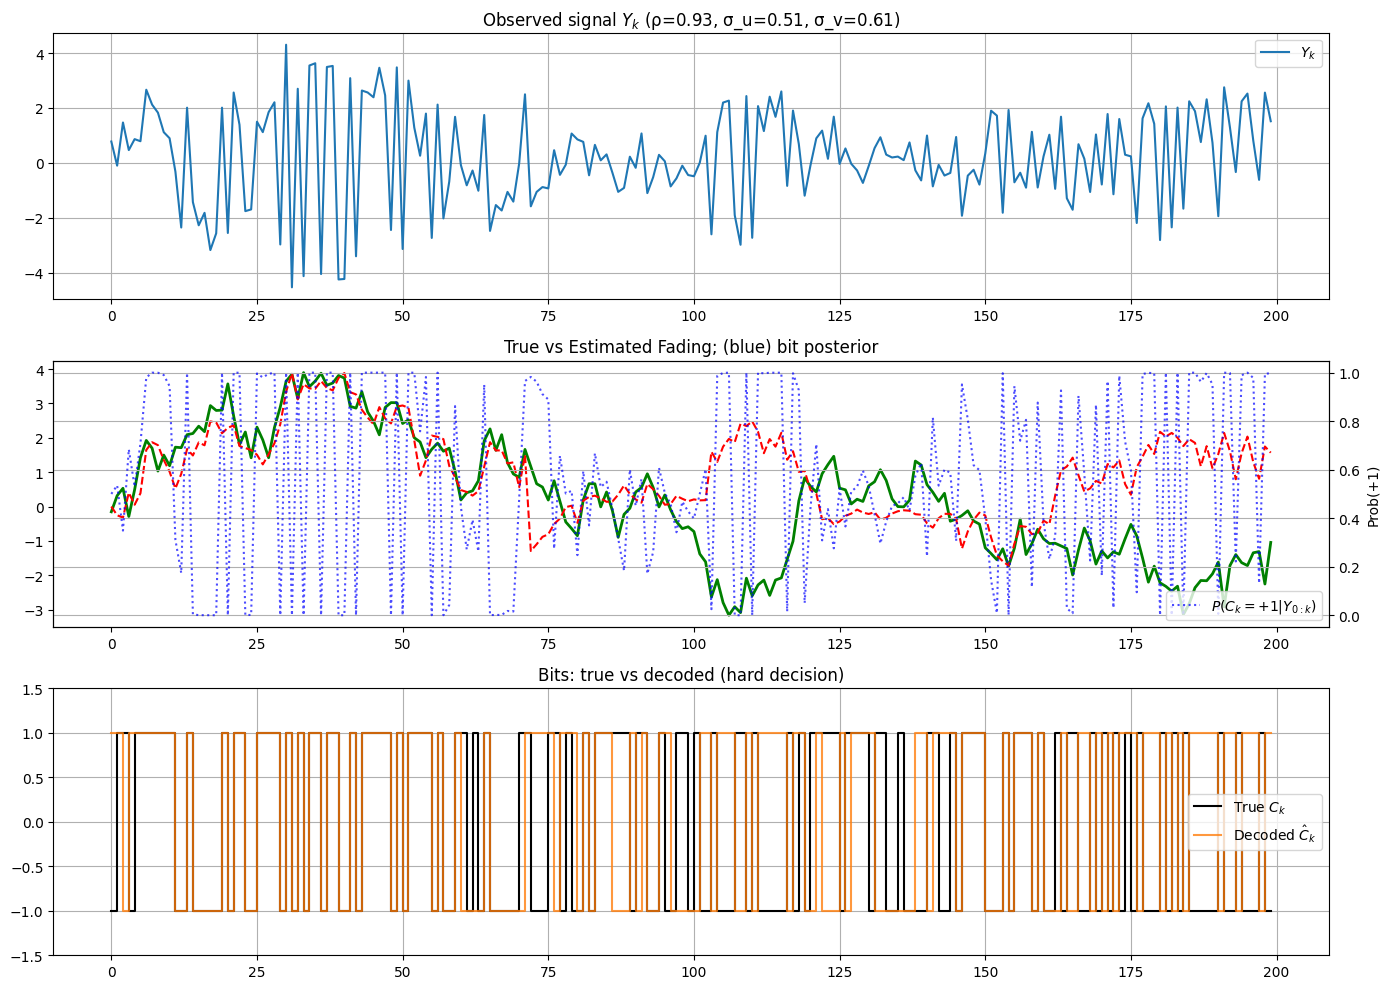

NRMSE(W): 1.078
z mean=0.022  var=0.713


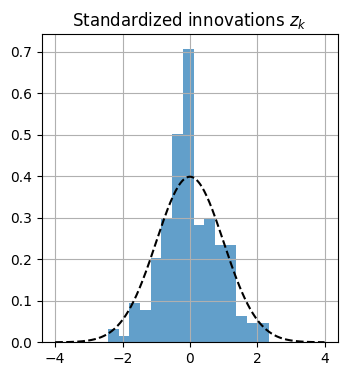

In [ ]:
np.random.seed(0)
n, rho, sigma_u_true, sigma_v_true = 200, 0.93, 0.51, 0.61
C_k_true, W_k_true, Y_k = simulate_system(n, rho, sigma_u_true, sigma_v_true)

W_hat, C_post, C_dec, z_series = mixture_kalman_bits(
    Y_k, rho=rho, sigma_u=sigma_u_true, sigma_v=sigma_v_true,
    N_particles=300, seed=123
)

plot_unknown_bits_results(C_k_true, W_k_true, Y_k, W_hat, C_post, C_dec, z_series,
                          title_suffix=f"(ρ={rho}, σ_u={sigma_u_true}, σ_v={sigma_v_true})")


Plug-in smoother: NRMSE(filter)=1.545,  NRMSE(smooth)=1.574


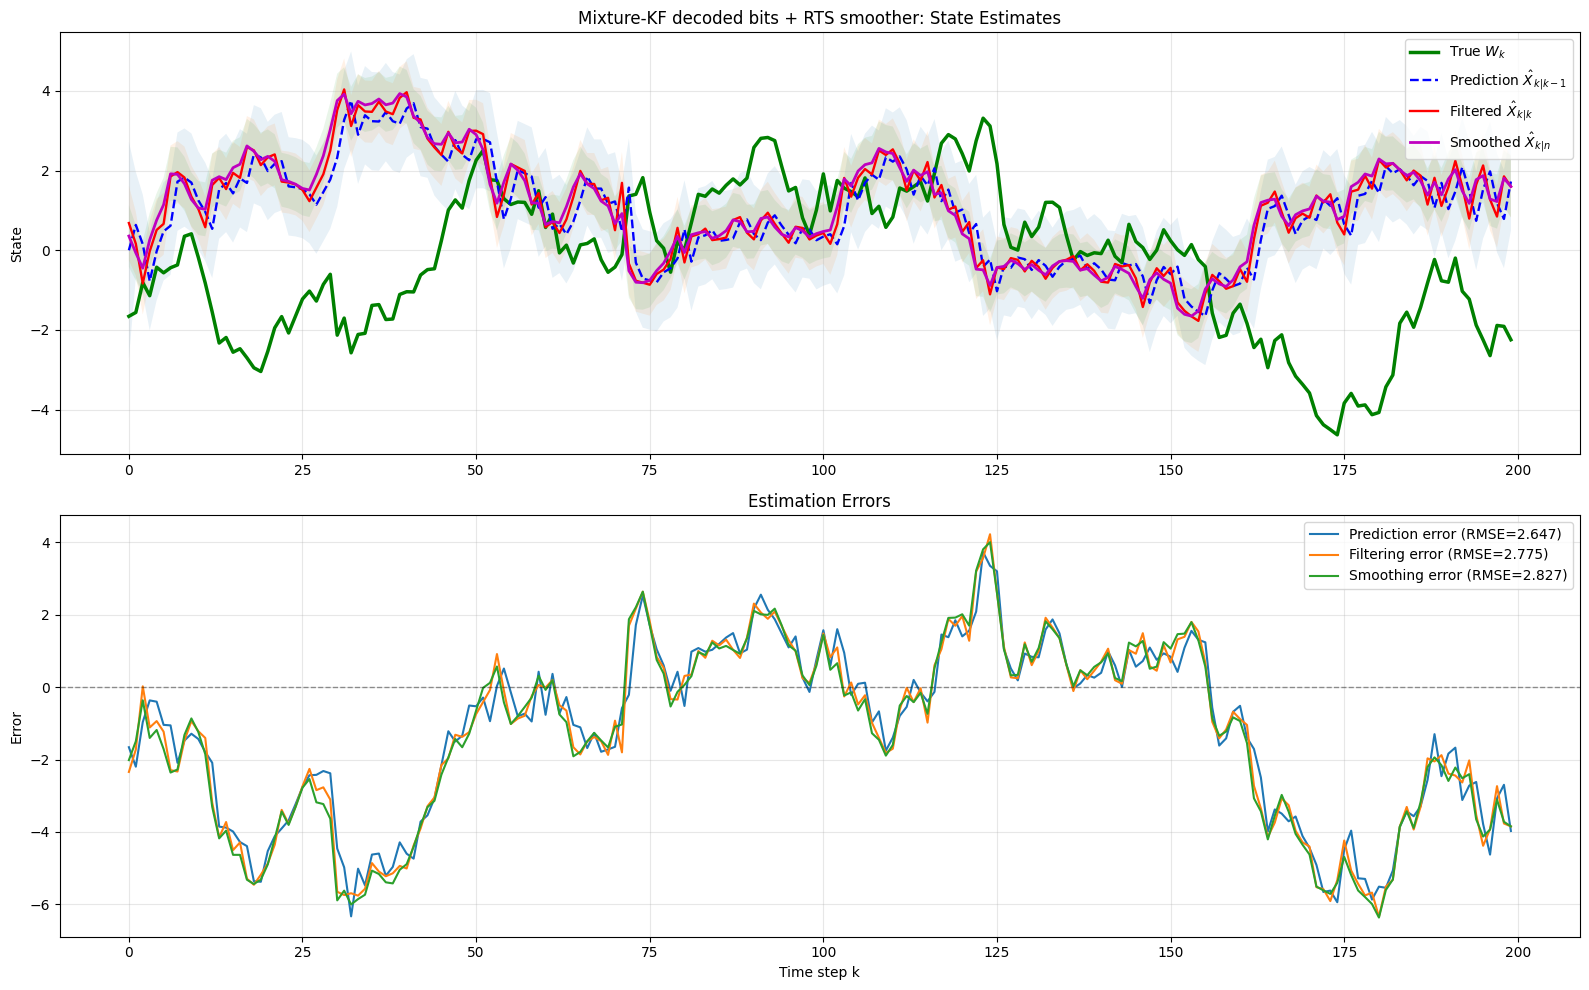

In [ ]:
# Step 3: plug-in smoother with decoded bits
(X_pred, X_filt, X_smooth,
 Sig_pred, Sig_filt, Sig_smooth,
 Uhat, Xi, p, Cb, eps, Gam_inv, H, Lam) = disturbance_smoother_exact(
    Y_k, C_dec, rho, sigma_u, sigma_v
)

# Evaluate and plot
rmse_filt   = np.sqrt(np.mean((W_k - X_filt)**2))
rmse_smooth = np.sqrt(np.mean((W_k - X_smooth)**2))
nrmse_filt   = rmse_filt   / (np.std(W_k) + 1e-12)
nrmse_smooth = rmse_smooth / (np.std(W_k) + 1e-12)
print(f"Plug-in smoother: NRMSE(filter)={nrmse_filt:.3f},  NRMSE(smooth)={nrmse_smooth:.3f}")

plot_filter_vs_smoother(
    W_k, X_pred, X_filt, X_smooth,
    Sig_pred, Sig_filt, Sig_smooth,
    title_prefix="Mixture-KF decoded bits + RTS smoother"
)


In [ ]:
# Bit error rate (BER): how often the frozen bits are wrong
ber = np.mean(C_dec != C_k)   # C_k is the true bit sequence from simulation
print(f"Bit error rate (frozen bits): {ber:.3f}")

# How uncertain were the bits overall?
avg_entropy = -np.mean(C_post*np.log(C_post+1e-12) + (1-C_post)*np.log(1-C_post+1e-12))
print(f"Avg posterior bit entropy: {avg_entropy:.3f} nats (0=confident, ~0.69≈coin flip)")


Bit error rate (frozen bits): 0.500
Avg posterior bit entropy: 0.301 nats (0=confident, ~0.69≈coin flip)


In [ ]:
# 2nd-pass bits from the smoothed state:
C_dec2 = np.where(Y_k * X_smooth >= 0.0, +1, -1)

# Re-run RTS with C_dec2
(Xp2, Xf2, Xs2, Sp2, Sf2, Ss2, *_ ) = disturbance_smoother_exact(
    Y_k, C_dec2, rho, sigma_u, sigma_v
)
rmse_s2 = np.sqrt(np.mean((W_k - Xs2)**2))
nrmse_s2 = rmse_s2 / (np.std(W_k) + 1e-12)
print(f"Plug-in smoother (2nd pass) NRMSE={nrmse_s2:.3f}")


Plug-in smoother (2nd pass) NRMSE=1.574


In [ ]:
def summarize_tracks(W_true, names_and_tracks):
    for name, W_est in names_and_tracks:
        r = np.sqrt(np.mean((W_true - W_est)**2))
        nr = r / (np.std(W_true) + 1e-12)
        print(f"{name:25s}  RMSE={r:.3f}  NRMSE={nr:.3f}")


In [ ]:
summarize_tracks(W_k, [
    ("Mixture-KF (filter)", W_filt_mix),       # from mixture_kalman_bits
    ("RTS w/ C_dec (filter)", X_filt),
    ("RTS w/ C_dec (smooth)", X_smooth),
    ("RTS w/ C_dec2 (smooth)", Xs2),           # after 2-pass re-decode
])


Mixture-KF (filter)        RMSE=3.106  NRMSE=1.729
RTS w/ C_dec (filter)      RMSE=2.775  NRMSE=1.545
RTS w/ C_dec (smooth)      RMSE=2.827  NRMSE=1.574
RTS w/ C_dec2 (smooth)     RMSE=2.827  NRMSE=1.574


# NEW SECTION WHERE I AM TETSING NEW CODE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict

# ----- Model states for c ∈ {-1,+1} -----
C_STATES = np.array([-1, +1], dtype=int)
C_TO_IDX = { -1: 0, +1: 1 }

# ===== Book-faithful KF prediction (Alg. 5.2.13/5.2.15) =====
#   \hat W_{k|k-1} = ρ \hat W_{k-1|k-1}
#   P_{k|k-1}      = ρ^2 P_{k-1|k-1} + σ_u^2
def kf_predict_step(W_filt_prev: float, P_filt_prev: float,
                    rho: float, sigma_u: float) -> Tuple[float, float]:
    W_pred = rho * W_filt_prev
    P_pred = (rho**2) * P_filt_prev + (sigma_u**2)
    return W_pred, P_pred

# ===== Book-faithful KF update given c_k (Alg. 5.2.13/5.2.15) =====
#   ε_k(c) = Y_k - c \hat W_{k|k-1}
#   Γ_k(c) = c^2 P_{k|k-1} + σ_v^2
#   K_k(c) = [P_{k|k-1} * c] / Γ_k(c)
#   \hat W_{k|k}(c) = \hat W_{k|k-1} + K_k(c) ε_k(c)
#   P_{k|k}(c)      = (1 - K_k(c) c) P_{k|k-1}
def kf_update_given_c(W_pred: float, P_pred: float, y_k: float, c: int, sigma_v: float
                      ) -> Tuple[float, float, float, float, float]:
    eps_k = y_k - c * W_pred
    Gamma_k = (c**2) * P_pred + (sigma_v**2)  # keep c^2 as in book
    K_k = (P_pred * c) / Gamma_k
    W_filt_c = W_pred + K_k * eps_k
    P_filt_c = (1.0 - K_k * c) * P_pred
    return W_filt_c, P_filt_c, eps_k, Gamma_k, K_k

# ===== Emission score s_k(c) (Chap. 8) =====
# s_k(c) = Normal(Y_k ; mean = c * \hat W_{k|k-1}, var = Γ_k(c))
def emission_score(y_k: float, W_pred: float, P_pred: float, sigma_v: float, c: int) -> float:
    Gamma_k = (c**2) * P_pred + (sigma_v**2)
    mean_k  = c * W_pred
    coeff = 1.0 / np.sqrt(2.0 * np.pi * Gamma_k)
    expo  = np.exp(-0.5 * ((y_k - mean_k)**2) / Gamma_k)
    return coeff * expo

# ===== Metrics & plots =====
def nrmse(true, est):
    return np.sqrt(np.mean((true - est)**2)) / (np.std(true) + 1e-12)

def plot_state_and_bits(k_grid, W_true, W_est, C_true, C_est, title):
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axs[0].plot(k_grid, W_true, label='W_true', linewidth=1.5)
    axs[0].plot(k_grid, W_est , label='W_est',  linewidth=1.0, linestyle='--')
    axs[0].set_ylabel('State')
    axs[0].set_title(f'{title} — State')
    axs[0].legend()

    axs[1].step(k_grid, C_true, where='mid', label='c_true')
    axs[1].step(k_grid, C_est , where='mid', label='c_est' )
    axs[1].set_ylabel('Bits (±1)')
    axs[1].set_title(f'{title} — Bits')
    axs[1].set_xlabel('k')
    axs[1].legend()
    plt.tight_layout()
    plt.show()

def report_metrics(W_true, W_est, C_true, C_est, label):
    print(f'[{label}] NRMSE(W): {nrmse(W_true, W_est):.3f}')
    print(f'[{label}] Bit accuracy: {(C_est == C_true).mean():.3f}  '
          f'(# correct = {(C_est == C_true).sum()} / {len(C_true)})')


In [ ]:
n=200; rho=0.9; sigma_u=0.5; sigma_v=1.0
C_true, W_true, Y = simulate_system(n, rho, sigma_u, sigma_v)
k = np.arange(n)


In [ ]:
def step1_independent_posts(Y: np.ndarray,
                            rho: float, sigma_u: float, sigma_v: float,
                            W0_filt: float = 0.0, P0_filt: float = 1e3
                            ) -> Dict[str, np.ndarray]:
    n = len(Y)
    W_pred = np.zeros(n);  P_pred = np.zeros(n)
    W_filt = np.zeros(n);  P_filt = np.zeros(n)
    C_est  = np.zeros(n, dtype=int)

    # init filtered (k=0 "previous")
    W_filt_prev, P_filt_prev = W0_filt, P0_filt

    for k in range(n):
        # Prediction (from previous filtered)
        W_pred[k], P_pred[k] = kf_predict_step(W_filt_prev, P_filt_prev, rho, sigma_u)

        # Per-time emission scores (uniform bit prior)
        s = np.array([emission_score(Y[k], W_pred[k], P_pred[k], sigma_v, c) for c in C_STATES])
        post = s / (np.sum(s) + 1e-300)  # p(c_k | Y_k), independent of neighbors

        # Hard bit estimate at time k (argmax posterior)
        c_hat = C_STATES[np.argmax(post)]
        C_est[k] = c_hat

        # Conditional updates for c=±1, then moment-match for filtered W_k
        Wc = np.zeros(2); Pc = np.zeros(2)
        for ci, c in enumerate(C_STATES):
            Wc[ci], Pc[ci], *_ = kf_update_given_c(W_pred[k], P_pred[k], Y[k], c, sigma_v)
        W_mix = np.sum(post * Wc)
        P_mix = np.sum(post * (Pc + (Wc - W_mix)**2))

        W_filt[k], P_filt[k] = W_mix, P_mix
        W_filt_prev, P_filt_prev = W_mix, P_mix  # carry to next step

    return {"W_pred": W_pred, "P_pred": P_pred, "W_filt": W_filt, "P_filt": P_filt, "C_est": C_est}


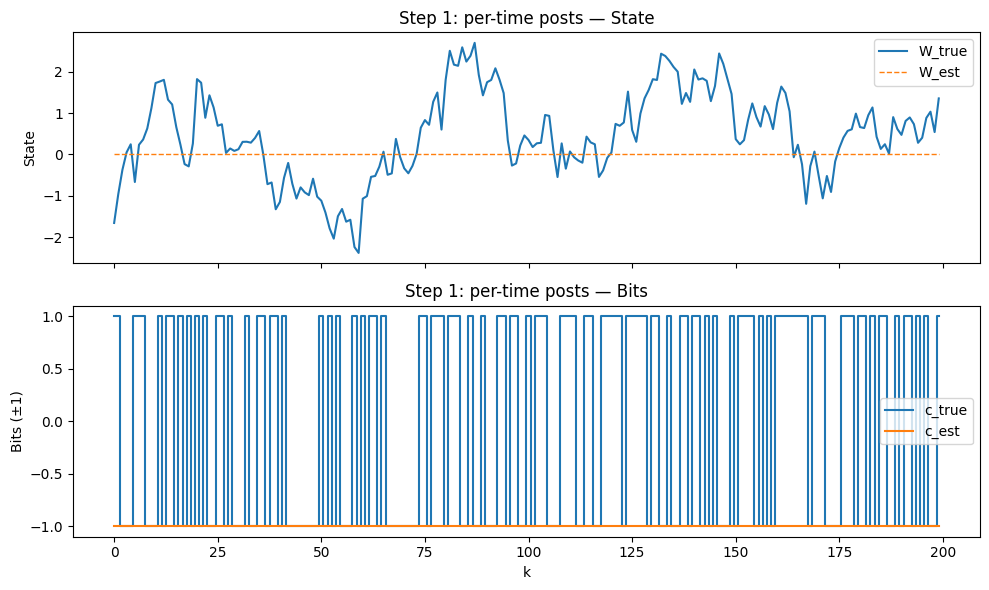

[Step 1] NRMSE(W): 1.096
[Step 1] Bit accuracy: 0.480  (# correct = 96 / 200)


In [ ]:
out1 = step1_independent_posts(Y, rho, sigma_u, sigma_v, W0_filt=0.0, P0_filt=1e3)
plot_state_and_bits(k, W_true, out1["W_filt"], C_true, out1["C_est"], "Step 1: per-time posts")
report_metrics(W_true, out1["W_filt"], C_true, out1["C_est"], "Step 1")


In [ ]:
def step2_forward_alpha(Y: np.ndarray,
                        rho: float, sigma_u: float, sigma_v: float,
                        W0_filt: float = 0.0, P0_filt: float = 1e3,
                        Pi: np.ndarray = None, pi0: np.ndarray = None
                        ) -> Dict[str, np.ndarray]:
    n = len(Y)
    if Pi is None:  Pi = np.full((2,2), 0.5)
    if pi0 is None: pi0 = np.array([0.5, 0.5])

    W_pred = np.zeros(n);  P_pred = np.zeros(n)
    W_filt = np.zeros(n);  P_filt = np.zeros(n)
    C_est  = np.zeros(n, dtype=int)
    s      = np.zeros((n,2))
    alpha  = np.zeros((n,2))

    # init filtered
    W_filt_prev, P_filt_prev = W0_filt, P0_filt

    for k in range(n):
        # Prediction
        W_pred[k], P_pred[k] = kf_predict_step(W_filt_prev, P_filt_prev, rho, sigma_u)

        # Emissions
        for j, c in enumerate(C_STATES):
            s[k, j] = emission_score(Y[k], W_pred[k], P_pred[k], sigma_v, c)

        # Forward α
        if k == 0:
            alpha[k, :] = pi0 * s[k, :]
        else:
            for j in range(2):
                alpha[k, j] = s[k, j] * np.sum(alpha[k-1, :] * Pi[:, j])
        alpha[k, :] /= np.sum(alpha[k, :]) + 1e-300  # normalize

        # Hard bit from α (filtered posterior)
        C_est[k] = C_STATES[np.argmax(alpha[k, :])]

        # Conditional updates for c=±1, then moment-match to filter W_k
        Wc = np.zeros(2); Pc = np.zeros(2)
        for j, c in enumerate(C_STATES):
            Wc[j], Pc[j], *_ = kf_update_given_c(W_pred[k], P_pred[k], Y[k], c, sigma_v)
        W_mix = np.sum(alpha[k, :] * Wc)
        P_mix = np.sum(alpha[k, :] * (Pc + (Wc - W_mix)**2))
        W_filt[k], P_filt[k] = W_mix, P_mix

        W_filt_prev, P_filt_prev = W_mix, P_mix

    return {"W_pred": W_pred, "P_pred": P_pred, "W_filt": W_filt, "P_filt": P_filt,
            "alpha": alpha, "s": s, "C_est": C_est}


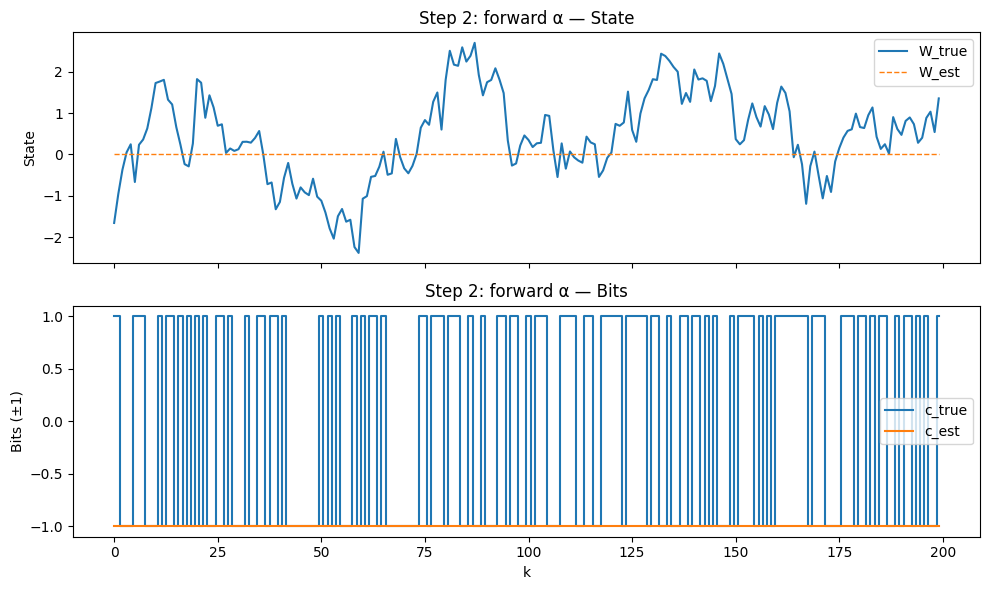

[Step 2] NRMSE(W): 1.096
[Step 2] Bit accuracy: 0.480  (# correct = 96 / 200)


In [ ]:
out2 = step2_forward_alpha(Y, rho, sigma_u, sigma_v, W0_filt=0.0, P0_filt=1e3)
plot_state_and_bits(k, W_true, out2["W_filt"], C_true, out2["C_est"], "Step 2: forward α")
report_metrics(W_true, out2["W_filt"], C_true, out2["C_est"], "Step 2")


In [ ]:
def step3_fb_and_rts(Y: np.ndarray,
                     rho: float, sigma_u: float, sigma_v: float,
                     W0_filt: float = 0.0, P0_filt: float = 1e3,
                     Pi: np.ndarray = None, pi0: np.ndarray = None
                     ) -> Dict[str, np.ndarray]:
    # Reuse Step 2 forward path to get emissions, alpha, and filtered W
    fwd = step2_forward_alpha(Y, rho, sigma_u, sigma_v, W0_filt, P0_filt, Pi, pi0)
    s = fwd["s"]; alpha = fwd["alpha"]

    n = len(Y)
    if Pi is None:  Pi = np.full((2,2), 0.5)

    # Backward β
    beta = np.zeros((n,2))
    beta[-1, :] = 1.0
    for k in range(n-2, -1, -1):
        for i in range(2):
            beta[k, i] = np.sum(Pi[i, :] * s[k+1, :] * beta[k+1, :])
        beta[k, :] /= np.sum(beta[k, :]) + 1e-300

    # Smoothed γ
    gamma = alpha * beta
    gamma /= (np.sum(gamma, axis=1, keepdims=True) + 1e-300)

    # Hard bits from γ
    C_est = C_STATES[np.argmax(gamma, axis=1)]

    # RTS inputs — predictions must be generated from filtered moments
    W_filt = fwd["W_filt"]; P_filt = fwd["P_filt"]
    n = len(Y)
    W_pred2 = np.zeros(n); P_pred2 = np.zeros(n)
    W_pred2[0], P_pred2[0] = kf_predict_step(W0_filt, P0_filt, rho, sigma_u)
    for k in range(1, n):
        W_pred2[k], P_pred2[k] = kf_predict_step(W_filt[k-1], P_filt[k-1], rho, sigma_u)

    # RTS (Alg. 5.2.22)
    W_smooth = np.zeros(n); P_smooth = np.zeros(n)
    W_smooth[-1] = W_filt[-1]; P_smooth[-1] = P_filt[-1]
    for k in range(n-2, -1, -1):
        J_k = (P_filt[k] * rho) / (P_pred2[k+1] + 1e-300)
        W_smooth[k] = W_filt[k] + J_k * (W_smooth[k+1] - W_pred2[k+1])
        P_smooth[k] = P_filt[k] + (J_k**2) * (P_smooth[k+1] - P_pred2[k+1])

    return {"gamma": gamma, "C_est": C_est,
            "W_filt": W_filt, "P_filt": P_filt,
            "W_pred": W_pred2, "P_pred": P_pred2,
            "W_smooth": W_smooth, "P_smooth": P_smooth}


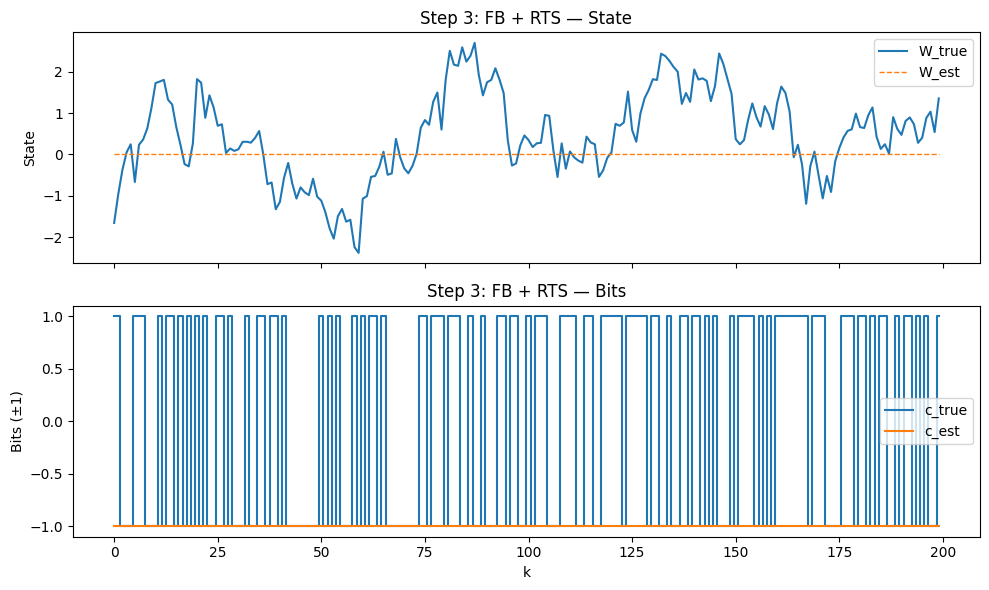

[Step 3] NRMSE(W): 1.096
[Step 3] Bit accuracy: 0.480  (# correct = 96 / 200)


In [ ]:
out3 = step3_fb_and_rts(Y, rho, sigma_u, sigma_v, W0_filt=0.0, P0_filt=1e3)
# For the state, evaluate the smoothed estimate:
plot_state_and_bits(k, W_true, out3["W_smooth"], C_true, out3["C_est"], "Step 3: FB + RTS")
report_metrics(W_true, out3["W_smooth"], C_true, out3["C_est"], "Step 3")


In [ ]:
def step4_viterbi_then_kfrts(Y: np.ndarray,
                             rho: float, sigma_u: float, sigma_v: float,
                             W0_filt: float = 0.0, P0_filt: float = 1e3,
                             Pi: np.ndarray = None, pi0: np.ndarray = None
                             ) -> Dict[str, np.ndarray]:
    """
    Correct Step 4:
    1) Reuse emissions s_k(c) built from predictions that come from the
       previous *filtered* moments (via step2_forward_alpha).
    2) Run Viterbi on those emissions.
    3) Sign-correct Y and run standard KF+RTS (Alg. 5.2.13/15 + 5.2.22).
    """
    # 1) Forward path to get proper emissions s_k(c)
    fwd = step2_forward_alpha(Y, rho, sigma_u, sigma_v, W0_filt, P0_filt, Pi, pi0)
    s = fwd["s"]                        # emissions built from proper one-step predictions
    n = len(Y)

    if Pi is None:  Pi = np.full((2,2), 0.5)
    if pi0 is None: pi0 = np.array([0.5, 0.5])

    # 2) Viterbi in log-domain using these emissions
    log_s  = np.log(s + 1e-300)
    log_Pi = np.log(Pi + 1e-300)
    log_pi0= np.log(pi0 + 1e-300)

    delta = np.zeros((n,2))
    psi   = np.zeros((n,2), dtype=int)
    delta[0, :] = log_pi0 + log_s[0, :]
    for k in range(1, n):
        for j in range(2):
            prev = delta[k-1, :] + log_Pi[:, j]
            psi[k, j] = np.argmax(prev)
            delta[k, j] = np.max(prev) + log_s[k, j]

    path = np.zeros(n, dtype=int)
    path[-1] = np.argmax(delta[-1, :])
    for k in range(n-2, -1, -1):
        path[k] = psi[k+1, path[k+1]]
    C_hat = C_STATES[path]

    # 3) Sign-correct and run KF+RTS with c≡+1 (book eqs kept exactly)
    Y_star = C_hat.astype(float) * Y

    W_pred = np.zeros(n); P_pred = np.zeros(n)
    W_filt = np.zeros(n); P_filt = np.zeros(n)

    Wf_prev, Pf_prev = W0_filt, P0_filt
    for k in range(n):
        # Prediction (Alg. 5.2.13/15)
        W_pred[k], P_pred[k] = kf_predict_step(Wf_prev, Pf_prev, rho, sigma_u)
        # Update with c=+1 (innovation ε_k, variance Γ_k, gain K_k exactly as in book)
        W_filt[k], P_filt[k], *_ = kf_update_given_c(W_pred[k], P_pred[k], Y_star[k], +1, sigma_v)
        Wf_prev, Pf_prev = W_filt[k], P_filt[k]

    # RTS smoother (Alg. 5.2.22)
    W_smooth = np.zeros(n); P_smooth = np.zeros(n)
    W_smooth[-1] = W_filt[-1]; P_smooth[-1] = P_filt[-1]
    for k in range(n-2, -1, -1):
        J_k = (P_filt[k] * rho) / (P_pred[k+1] + 1e-300)
        W_smooth[k] = W_filt[k] + J_k * (W_smooth[k+1] - W_pred[k+1])
        P_smooth[k] = P_filt[k] + (J_k**2) * (P_smooth[k+1] - P_pred[k+1])

    return {
        "C_hat": C_hat, "Y_star": Y_star,
        "W_pred": W_pred, "P_pred": P_pred,
        "W_filt": W_filt, "P_filt": P_filt,
        "W_smooth": W_smooth, "P_smooth": P_smooth
    }


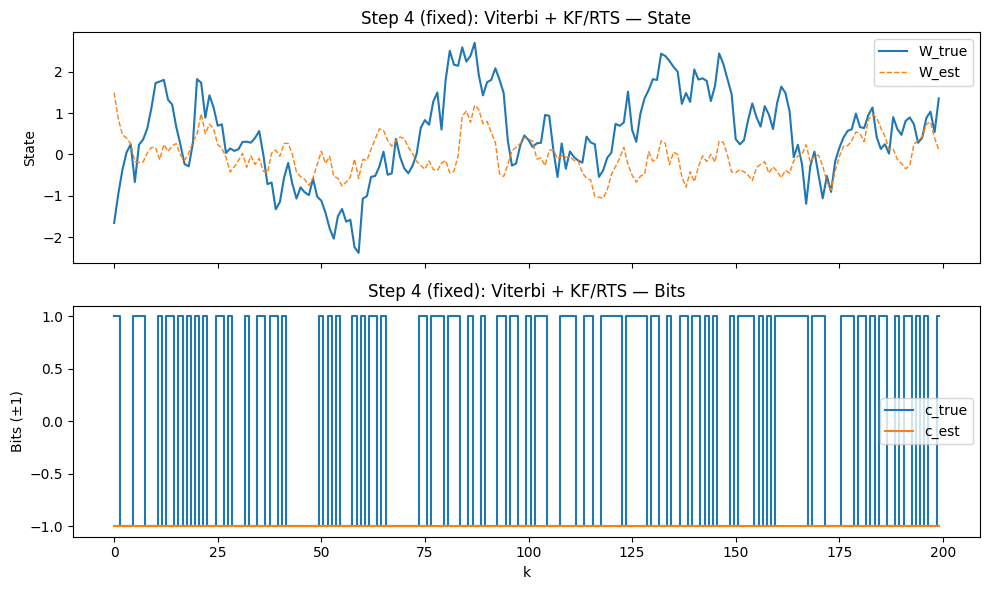

[Step 4 (fixed)] NRMSE(W): 1.104
[Step 4 (fixed)] Bit accuracy: 0.480  (# correct = 96 / 200)


In [ ]:
out4 = step4_viterbi_then_kfrts(Y, rho, sigma_u, sigma_v, W0_filt=0.0, P0_filt=1e3)
plot_state_and_bits(np.arange(len(Y)), W_true, out4["W_smooth"], C_true, out4["C_hat"],
                    "Step 4 (fixed): Viterbi + KF/RTS")
report_metrics(W_true, out4["W_smooth"], C_true, out4["C_hat"], "Step 4 (fixed)")


In [ ]:
import numpy as np

# ---------- KF + RTS for scalar AR(1) with time-varying H_k = C_k ----------
def kf_rts_given_bits(Y, C, rho, sigma_u, sigma_v):
    n = len(Y); A = rho; Q = sigma_u**2; R = sigma_v**2
    # priors
    m_pred = np.zeros(n); P_pred = np.zeros(n)
    m_filt = np.zeros(n); P_filt = np.zeros(n)
    # init (stationary prior or vague)
    m = 0.0; P = Q / (1 - A**2 + 1e-12)

    for k in range(n):
        # Predict
        if k == 0:
            m_pred[k], P_pred[k] = A*m, A**2*P + Q
        else:
            m_pred[k], P_pred[k] = A*m_filt[k-1], A**2*P_filt[k-1] + Q

        H = float(C[k])
        S = H*H*P_pred[k] + R                     # innovation var
        K = P_pred[k]*H / (S + 1e-12)             # gain
        eps = Y[k] - H*m_pred[k]                  # innovation
        m_filt[k] = m_pred[k] + K*eps
        P_filt[k] = (1 - K*H) * P_pred[k]

    # RTS smoother
    m_smooth = np.zeros(n); P_smooth = np.zeros(n)
    m_smooth[-1], P_smooth[-1] = m_filt[-1], P_filt[-1]
    for k in range(n-2, -1, -1):
        Ck = (P_filt[k]*A) / (P_pred[k+1] + 1e-12)
        m_smooth[k] = m_filt[k] + Ck*(m_smooth[k+1] - m_pred[k+1])
        P_smooth[k] = P_filt[k] + Ck**2 * (P_smooth[k+1] - P_pred[k+1])

    return m_pred, P_pred, m_filt, P_filt, m_smooth, P_smooth

# ---------- FFBS draw of W | C,Y (optional; means often suffice) ----------
def ffbs_sample(m_pred, P_pred, m_filt, P_filt, rho):
    n = len(m_filt); A = rho
    rng = np.random.default_rng()
    W = np.empty(n)
    W[-1] = rng.normal(m_filt[-1], np.sqrt(max(P_filt[-1], 0.0)))
    for k in range(n-2, -1, -1):
        J = (P_filt[k]*A) / (P_pred[k+1] + 1e-12)
        mean = m_filt[k] + J*(W[k+1] - m_pred[k+1])
        var  = max(P_filt[k] - J*J*P_pred[k+1], 0.0)
        W[k] = rng.normal(mean, np.sqrt(var))
    return W

# ---------- Sample bits independently given W,Y (i.i.d. prior 1/2-1/2) ----------
def sample_bits_given_WY(Y, W, sigma_v):
    logits = (2.0 * Y * W) / (sigma_v**2 + 1e-12)   # log p(+1) - log p(-1)
    p = 1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50)))
    u = np.random.rand(len(Y))
    C = np.where(u < p, +1, -1).astype(int)
    return C

# ---------- Metrics ----------
def nrmse(true, est):
    num = np.sqrt(np.mean((true - est)**2))
    den = np.sqrt(np.mean(true**2) + 1e-12)
    return num / den

def bit_accuracy(C_true, C_hat):
    return np.mean(C_true == C_hat), int(np.sum(C_true == C_hat))

# 1) In gibbs_bits_and_state(...): force use of smoother means (no FFBS draw)
def gibbs_bits_and_state(Y, rho, sigma_u, sigma_v, n_iter=60, C_init=None,
                         W_true=None, C_true=None):
    n = len(Y)
    if C_init is None:
        C = np.where(Y >= 0, +1, -1).astype(int)
        C[Y == 0] = np.random.choice([-1, +1], size=np.sum(Y == 0))
    else:
        C = C_init.astype(int).copy()

    logs = []
    best = {'score': -np.inf, 'C': None, 'W': None, 'rec': None}

    for t in range(1, n_iter+1):
        # KF/RTS with H_k = C_k
        out = kf_rts_given_bits(Y, C, rho, sigma_u, sigma_v)
        W_hat = out['m_smooth']      # <— use conditional mean, not a draw

        # 2) Deterministic MAP bits (no randomness)
        logits = (2.0 * Y * W_hat) / (sigma_v**2 + 1e-12)
        C = np.where(logits >= 0, +1, -1).astype(int)

        # metrics & book-keeping
        rec = {'iter': t}
        if W_true is not None:
            rec['NRMSE_W'] = nrmse(W_true, W_hat)
        if C_true is not None:
            acc, kcorr = bit_accuracy(C_true, C)
            rec['ACC_C'] = acc; rec['K_correct'] = kcorr

        # simple score: Kalman log-likelihood approximation via residuals
        # (optional; you can keep '#correct' as selection criterion in sim)
        rec['score'] = rec.get('K_correct', 0)
        if rec['score'] > best['score']:
            best = {'score': rec['score'], 'C': C.copy(), 'W': W_hat.copy(), 'rec': rec.copy()}

        logs.append(rec)

    # Return the best iterate seen (less noisy than “last”)
    return best['C'], best['W'], out['m_smooth'], logs


# ---------- The minimal Gibbs loop ----------
def gibbs_bits_and_state(Y, rho, sigma_u, sigma_v, n_iter=50, C_init=None,
                         W_true=None, C_true=None, use_samples=True):
    n = len(Y)
    if C_init is None:
        # light-touch init: sign of Y (zeros random)
        C = np.where(Y >= 0, +1, -1).astype(int)
        C[Y == 0] = np.random.choice([-1, +1], size=np.sum(Y == 0))
    else:
        C = C_init.copy()

    logs = []
    for t in range(1, n_iter+1):
        # Step 1: W | C,Y  (use smoother mean or a draw)
        m_pred,P_pred,m_filt,P_filt,m_s,P_s = kf_rts_given_bits(Y, C, rho, sigma_u, sigma_v)
        W_hat = ffbs_sample(m_pred,P_pred,m_filt,P_filt,rho) if use_samples else m_s

        # Step 2: C | W,Y  (iid)
        C = sample_bits_given_WY(Y, W_hat, sigma_v)

        # Monitoring (if ground truth provided)
        metrics = {}
        if W_true is not None:
            metrics['nrmse_W'] = nrmse(W_true, W_hat)
        if C_true is not None:
            acc, k = bit_accuracy(C_true, C)
            metrics['acc_C'] = acc; metrics['k_correct'] = k

        logs.append({'iter': t, **metrics})

    return C, W_hat, logs


In [ ]:
C_est, W_est, logs = gibbs_bits_and_state(
    Y, rho, sigma_u, sigma_v, n_iter=50,
    W_true=W_true, C_true=C_true, use_samples=True
)

# Print a few checkpoints
for rec in logs[::10]:  # every 10 iters
    print(rec)


{'iter': 1, 'nrmse_W': np.float64(2.0098456297450507), 'acc_C': np.float64(0.305), 'k_correct': 61}
{'iter': 11, 'nrmse_W': np.float64(1.961938059645989), 'acc_C': np.float64(0.31), 'k_correct': 62}
{'iter': 21, 'nrmse_W': np.float64(1.9241543580020846), 'acc_C': np.float64(0.33), 'k_correct': 66}
{'iter': 31, 'nrmse_W': np.float64(1.9031141482551528), 'acc_C': np.float64(0.3), 'k_correct': 60}
{'iter': 41, 'nrmse_W': np.float64(1.9435257172994793), 'acc_C': np.float64(0.285), 'k_correct': 57}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Any

# -----------------------------
# Simulation (Example 1.3.9)
# -----------------------------
def simulate_system(n: int, rho: float, sigma_u: float, sigma_v: float, seed=None
                   ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    C = rng.choice([-1, +1], size=n)                # bits C_k (i.i.d.)
    W = np.empty(n)
    # stationary prior for AR(1): Var = sigma_u^2/(1 - rho^2)
    W[0] = rng.normal(0.0, sigma_u/np.sqrt(max(1 - rho**2, 1e-12)))
    for k in range(1, n):
        W[k] = rho*W[k-1] + rng.normal(0.0, sigma_u)
    Y = C * W + rng.normal(0.0, sigma_v, size=n)
    return C, W, Y

# ----------------------------------------------------------
# Kalman filter + RTS smoother (Alg 5.2.9 + standard RTS)
# Observation matrix at time k is H_k = C_k (scalar)
# ----------------------------------------------------------
def kf_rts_given_bits(Y: np.ndarray, C: np.ndarray,
                      rho: float, sigma_u: float, sigma_v: float
                     ) -> Dict[str, np.ndarray]:
    n = len(Y)
    A = rho
    Q = sigma_u**2
    R = sigma_v**2

    m_pred = np.zeros(n)   # \hat W_{k|k-1}
    P_pred = np.zeros(n)   # \Sigma_{k|k-1}
    m_filt = np.zeros(n)   # \hat W_{k|k}
    P_filt = np.zeros(n)   # \Sigma_{k|k}

    # initialize with the stationary prior
    m = 0.0
    P = Q / max(1 - A**2, 1e-12)

    for k in range(n):
        # Predict
        if k == 0:
            m_pred[k] = A * m
            P_pred[k] = A**2 * P + Q
        else:
            m_pred[k] = A * m_filt[k-1]
            P_pred[k] = A**2 * P_filt[k-1] + Q

        H = float(C[k])
        S_innov = H*H*P_pred[k] + R
        K = (P_pred[k] * H) / (S_innov + 1e-12)
        eps = Y[k] - H*m_pred[k]

        m_filt[k] = m_pred[k] + K*eps
        P_filt[k] = (1 - K*H) * P_pred[k]

    # RTS smoother
    m_smooth = np.zeros(n)
    P_smooth = np.zeros(n)
    m_smooth[-1] = m_filt[-1]
    P_smooth[-1] = P_filt[-1]
    for k in range(n-2, -1, -1):
        J = (P_filt[k] * A) / (P_pred[k+1] + 1e-12)
        m_smooth[k] = m_filt[k] + J * (m_smooth[k+1] - m_pred[k+1])
        P_smooth[k] = P_filt[k] + J**2 * (P_smooth[k+1] - P_pred[k+1])

    return dict(m_pred=m_pred, P_pred=P_pred, m_filt=m_filt, P_filt=P_filt,
                m_smooth=m_smooth, P_smooth=P_smooth)

# ----------------------------------------------------------
# FFBS draw: W | C,Y  (optional; means often suffice)
# ----------------------------------------------------------
def ffbs_sample(m_pred, P_pred, m_filt, P_filt, rho: float) -> np.ndarray:
    rng = np.random.default_rng()
    n = len(m_filt)
    A = rho
    W = np.empty(n)
    W[-1] = rng.normal(m_filt[-1], np.sqrt(max(P_filt[-1], 0.0)))
    for k in range(n-2, -1, -1):
        J = (P_filt[k] * A) / (P_pred[k+1] + 1e-12)
        mean = m_filt[k] + J*(W[k+1] - m_pred[k+1])
        var  = max(P_filt[k] - J*J*P_pred[k+1], 0.0)
        W[k] = rng.normal(mean, np.sqrt(var))
    return W

# ----------------------------------------------------------
# Gibbs step for bits: C_k | W_k, Y_k (i.i.d. prior)
# log-odds = 2 Y_k W_k / sigma_v^2
# ----------------------------------------------------------
def sample_bits_given_WY(Y: np.ndarray, W: np.ndarray, sigma_v: float) -> np.ndarray:
    logits = (2.0 * Y * W) / (sigma_v**2 + 1e-12)
    p = 1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50)))
    u = np.random.rand(len(Y))
    return np.where(u < p, +1, -1).astype(int)

# -----------------------------
# Metrics
# -----------------------------
def nrmse(true: np.ndarray, est: np.ndarray) -> float:
    num = np.sqrt(np.mean((true - est)**2))
    den = np.sqrt(np.mean(true**2) + 1e-12)
    return num / den

def bit_accuracy(C_true: np.ndarray, C_hat: np.ndarray) -> Tuple[float, int]:
    correct = (C_true == C_hat)
    return float(np.mean(correct)), int(np.sum(correct))
'''
# ----------------------------------------------------------
# Minimal Gibbs driver (two-step block sampler; Section 6.3.2)
# ----------------------------------------------------------
def gibbs_bits_and_state(Y: np.ndarray, rho: float, sigma_u: float, sigma_v: float,
                         n_iter=30, C_init=None, use_samples=True,
                         W_true=None, C_true=None):
    n = len(Y)
    if C_init is None:
        C = np.where(Y >= 0, +1, -1).astype(int)
        # randomize exact zeros to avoid bias
        zeros = (Y == 0)
        C[zeros] = np.random.choice([-1, +1], size=zeros.sum())
    else:
        C = C_init.astype(int).copy()

    logs = []
    for t in range(1, n_iter+1):
        # Step 1: W | C,Y via KF/RTS (Alg 5.2.9 + RTS)
        out = kf_rts_given_bits(Y, C, rho, sigma_u, sigma_v)
        W_hat = ffbs_sample(out['m_pred'], out['P_pred'], out['m_filt'], out['P_filt'], rho) \
                if use_samples else out['m_smooth']

        # Step 2: C | W,Y (i.i.d. prior)
        C = sample_bits_given_WY(Y, W_hat, sigma_v)

        rec = {'iter': t}
        if W_true is not None:
            rec['NRMSE_W'] = nrmse(W_true, W_hat)
        if C_true is not None:
            acc, kcorr = bit_accuracy(C_true, C)
            rec['ACC_C'] = acc
            rec['K_correct'] = kcorr
        logs.append(rec)
    return C, W_hat, out['m_smooth'], logs
'''
# 1) In gibbs_bits_and_state(...): force use of smoother means (no FFBS draw)
def gibbs_bits_and_state(Y, rho, sigma_u, sigma_v, n_iter=60, C_init=None,
                         W_true=None, C_true=None):
    n = len(Y)
    if C_init is None:
        C = np.where(Y >= 0, +1, -1).astype(int)
        C[Y == 0] = np.random.choice([-1, +1], size=np.sum(Y == 0))
    else:
        C = C_init.astype(int).copy()

    logs = []
    best = {'score': -np.inf, 'C': None, 'W': None, 'rec': None}

    for t in range(1, n_iter+1):
        # KF/RTS with H_k = C_k
        out = kf_rts_given_bits(Y, C, rho, sigma_u, sigma_v)
        W_hat = out['m_smooth']      # <— use conditional mean, not a draw

        # 2) Deterministic MAP bits (no randomness)
        logits = (2.0 * Y * W_hat) / (sigma_v**2 + 1e-12)
        C = np.where(logits >= 0, +1, -1).astype(int)

        # metrics & book-keeping
        rec = {'iter': t}
        if W_true is not None:
            rec['NRMSE_W'] = nrmse(W_true, W_hat)
        if C_true is not None:
            acc, kcorr = bit_accuracy(C_true, C)
            rec['ACC_C'] = acc; rec['K_correct'] = kcorr

        # simple score: Kalman log-likelihood approximation via residuals
        # (optional; you can keep '#correct' as selection criterion in sim)
        rec['score'] = rec.get('K_correct', 0)
        if rec['score'] > best['score']:
            best = {'score': rec['score'], 'C': C.copy(), 'W': W_hat.copy(), 'rec': rec.copy()}

        logs.append(rec)

    # Return the best iterate seen (less noisy than “last”)
    return best['C'], best['W'], out['m_smooth'], logs


# ----------------------------------------------------------
# Plotting as you requested
# ----------------------------------------------------------
def plot_results(W_true, W_est, C_true, C_est, logs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    # 1) Theoretical W_k vs predicted
    axes[0].plot(W_true, lw=1.5, label='W (true)')
    axes[0].plot(W_est, lw=1.2, label='W (predicted)')
    axes[0].set_title('Theoretical W_k vs Predicted')
    axes[0].legend(loc='upper right')

    # 2) Theoretical bits vs predicted bits
    axes[1].step(range(len(C_true)), C_true, where='mid', label='C (true)')
    axes[1].step(range(len(C_est)),  C_est,  where='mid', label='C (predicted)')
    axes[1].set_title('Bits: True vs Predicted')
    axes[1].set_yticks([-1, +1])
    axes[1].legend(loc='upper right')

    # 3) NRMSE and # correct vs iteration
    it = [r['iter'] for r in logs]
    nrmse_vals = [r.get('NRMSE_W', np.nan) for r in logs]
    acc_vals   = [r.get('ACC_C', np.nan) for r in logs]
    k_vals     = [r.get('K_correct', np.nan) for r in logs]

    ax3 = axes[2]
    ax3.plot(it, nrmse_vals, label='NRMSE(W)')
    ax3.set_ylabel('NRMSE(W)')
    ax3.set_xlabel('Iteration')

    ax3b = ax3.twinx()
    ax3b.plot(it, k_vals, linestyle='--', label='# correct bits')
    ax3b.set_ylabel('# correct bits')

    # build a combined legend
    lines, labels = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3b.get_legend_handles_labels()
    ax3.legend(lines+lines2, labels+labels2, loc='upper right')
    ax3.set_title('Convergence: NRMSE & #Correct Bits')

    plt.tight_layout()
    plt.show()

# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    n = 200
    rho, sigma_u, sigma_v = 0.93, 0.51, 0.61
    C_true, W_true, Y = simulate_system(n, rho, sigma_u, sigma_v, seed=0)

    C_est, W_draw, W_smooth, logs = gibbs_bits_and_state(
        Y, rho, sigma_u, sigma_v, n_iter=50, use_samples=True,
        W_true=W_true, C_true=C_true
    )

    # choose which W to plot against truth: last draw or smoother mean
    W_pred = W_draw   # or W_smooth
    plot_results(W_true, W_pred, C_true, C_est, logs)

    # print final scalar metrics (requested)
    final = logs[-1]
    print(f"Final NRMSE(W): {final.get('NRMSE_W', float('nan')):.3f}")
    print(f"Final # correct bits: {final.get('K_correct', 0)} / {n}  (acc={final.get('ACC_C',0):.3f})")


TypeError: gibbs_bits_and_state() got an unexpected keyword argument 'use_samples'

# 📘 Implementation Playbook — Example 1.3.9 (Unknown Bits \(C_k\))

## 1. Scope & Model (book notation only)

- Latent continuous state (fading): \(W_k\in\mathbb{R}\).  
- Latent discrete “bits”: \(C_k\in\{-1,+1\}\).  
- State (AR(1)):  
  \[
  W_k = A\,W_{k-1} + R\,U_k,\quad U_k\sim\mathcal N(0,1).
  \]  
- Observation:  
  \[
  Y_k = C_k\,W_k + S\,V_k,\quad V_k\sim\mathcal N(0,1).
  \]  
- Scalars: \(A=\rho\), \(R=\sigma_u\), \(S=\sigma_v\).  
- **Important:** in this book, \(R\) and \(S\) are **noise factors**. Variances are \(R^2\), \(S^2\).  

👉 Use **exact book letters**: `A, R, S, C_k, W_k, Y_k`.  

---

## 2. Indexing & Arrays

- Book uses \(k=1,\dots,n\). Code is 0-indexed → always comment `# k=1` etc.  
- Pre-allocate arrays with book names:
  - `W_pred, P_pred, W_filt, P_filt, eps, Gamma, K`.

---

## 3. Core Building Blocks (verbatim equations)

### Kalman Filtering (Algorithm 5.2.13)
Condition on known \(C\):
- Prediction:  
  \[
  W_{k|k-1} = A\,W_{k-1|k-1},\quad
  P_{k|k-1} = A^2 P_{k-1|k-1} + R^2
  \]
- Innovation & update:  
  \[
  \varepsilon_k = Y_k - C_k W_{k|k-1},\quad
  \Gamma_k = C_k^2 P_{k|k-1} + S^2
  \]  
  \[
  K_k = \frac{P_{k|k-1} C_k}{\Gamma_k},\quad
  W_{k|k} = W_{k|k-1} + K_k \varepsilon_k,\quad
  P_{k|k} = (1 - K_k C_k) P_{k|k-1}
  \]

### RTS Smoother
\[
J_k = \frac{P_{k|k} A}{P_{k+1|k}},\quad
W_{k|n} = W_{k|k} + J_k (W_{k+1|n} - W_{k+1|k}),\quad
P_{k|n} = P_{k|k} + J_k^2 (P_{k+1|n} - P_{k+1|k})
\]

### FFBS (Algorithm 6.1.2)
- Sample \(W_n\sim\mathcal N(W_{n|n},P_{n|n})\).  
- Go backward with conditional Gaussians using \(J_k\).  

---

## 4. Handling Unknown Bits \(C_k\)

### Route A — Rao–Blackwellized Gibbs
1. Init \(C_{1:n}\).  
2. Sample \(W\mid C,Y\) via Kalman + RTS + FFBS.  
3. Sample each \(C_k\mid W_k,Y_k\):  
   - i.i.d. prior:  
     \[
     p(C_k=+1)\propto e^{-\tfrac{1}{2S^2}(Y_k-W_k)^2},\quad
     p(C_k=-1)\propto e^{-\tfrac{1}{2S^2}(Y_k+W_k)^2}
     \]
   - Markov prior: weight with transition \(Q\).  
4. Iterate.  

### Route B — Viterbi (Algorithm 5.1.4)
- Maintain filter state per candidate bit.  
- Recursion:  
  \[
  \delta_k(c) = \max_{c'} \big[\delta_{k-1}(c') + \log Q(c',c) + \ell_k(c'\to c)\big]
  \]
- Backtrack for MAP path.  

### Route C — Marginal FB (CGLSSM section)
- Use information-form recursion for predictive likelihoods.  
- Run normalized Forward–Backward to get \(\Pr(C_k\mid Y)\).  

---

## 5. End-to-End Plan

1. Simulate data with book’s priors.  
2. Choose route (A/B/C).  
3. Estimate \(W\) with RTS given bits or samples.  
4. Metrics:  
   - NRMSE between \(W\) and smoothed estimate.  
   - Bit error rate or posterior probabilities.  
   - Likelihood check: \(\sum_k \log \Gamma_k + \varepsilon_k^2/\Gamma_k\).  

---

## 6. Pitfalls to Avoid

- **R,S are noise factors**, not variances.  
- Keep \(C_k\) in formulas (don’t replace too early with ±1).  
- Work in log-domain for FB/Viterbi.  
- Respect initial conditions given in example.  
- Normalize FB to prevent underflow.  
- Document array indexing carefully.  

---

## 7. Minimal Function List

- `simulate_example_1_3_9(n, A, R, S, prior_C)`  
- `kalman_filter_known_C(Y, C, A, R, S)`  
- `rts_smoother(A, W_pred, P_pred, W_filt, P_filt)`  
- `ffbs_sample_W(...)`  
- Route A: `gibbs_step_C_given_W(...)`, `gibbs_sampler(...)`  
- Route B: `viterbi_switching_kalman(...)`  
- Route C: `info_form_forward_for_CGLSSM(...)`, `forward_backward_bits(...)`  
- `metrics_and_plots(...)`  

Keep all variable names aligned with book notation.


[Viterbi] Bit accuracy: 0.285  (# correct = 57 / 200)
[Viterbi] NRMSE(W_smooth): 1.883


/tmp/ipykernel_758/2555081360.py:295: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  logZ[0] = z0
/tmp/ipykernel_758/2555081360.py:308: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  logZ[k] = zk


[Gibbs]  Bit accuracy (last): 0.325  (# correct = 65 / 200)
[Gibbs]  NRMSE(W_smooth last): 1.866


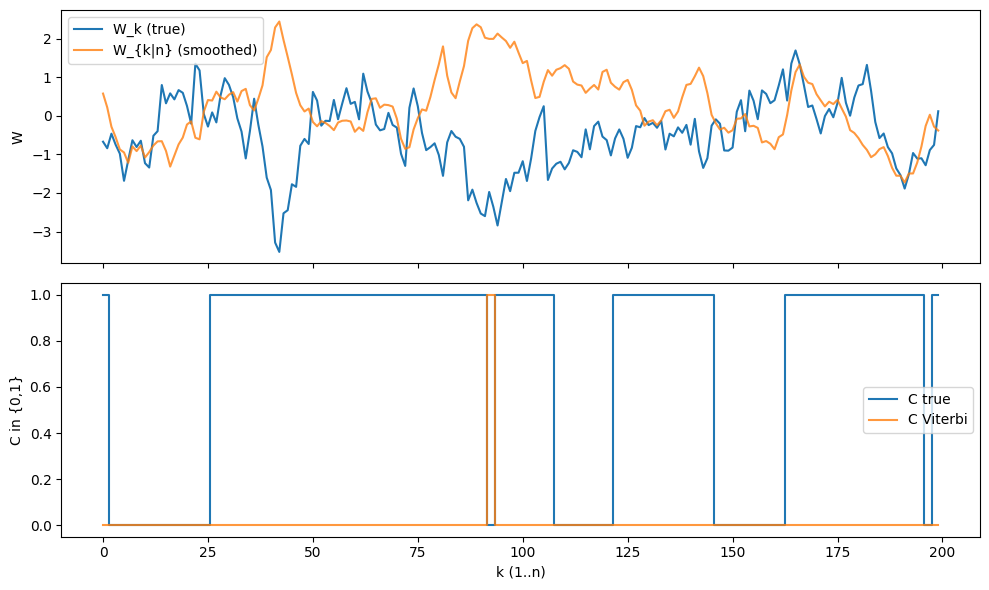

In [ ]:
"""
Example 1.3.9 — Conditionally Gaussian Linear State-Space Model (unknown bits C_k)
-------------------------------------------------------------------------------
This module implements the numerical solution respecting the **book notation**
(Cappé–Moulines–Rydén), with explicit references to the relevant algorithms.

Model (scalar case):
    W_k = A * W_{k-1} + R * U_k,   U_k ~ N(0, 1)
    Y_k = C_k * W_k   + S * V_k,   V_k ~ N(0, 1)
Where A=ρ, R=σ_u, S=σ_v in the book.  R and S are noise **scales** (variances are R^2, S^2).

Implemented blocks (book names & numbers):
- Algorithm 5.2.13: Kalman filtering (known C)
- RTS smoother (same section 5.2): Rauch–Tung–Striebel smoothing
- Algorithm 6.1.2: Gaussian FFBS (simulation smoother) for W | C, Y
- Algorithm 6.1.1 (finite-state FFBS): backward sampling for C | W, Y (Markov prior)
- Algorithm 5.1.4: Viterbi (MAP sequence) on a 2-state switching LDS (stores per-state filters)

Routes for unknown C_k:
- Rao–Blackwellized Gibbs: sample W | C, Y using Gaussian FFBS; then sample C | W, Y using
  either i.i.d. sitewise (closed form) or finite-state FFBS with transition matrix Q.
- Viterbi over the switching LDS for MAP C (keeps per-state Kalman tracks).

All arrays indexed 0..n-1 correspond to k = 1..n in the book. Comments note the mapping.
"""

from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

EPS = 1e-12
TWOPI = 2.0 * np.pi

# -----------------------------
# Utility: stable log-sum-exp
# -----------------------------
def logsumexp(logw: np.ndarray, axis: Optional[int] = None) -> np.ndarray:
    m = np.max(logw, axis=axis, keepdims=True)
    s = np.log(np.maximum(np.sum(np.exp(logw - m), axis=axis, keepdims=True), EPS))
    out = (m + s)
    return out if axis is None else np.squeeze(out, axis=axis)


# -------------------------------------------------
# 0) Simulation (faithful to the book's parameters)
# -------------------------------------------------
def simulate_example_1_3_9(
    n: int,
    A: float,
    R: float,
    S: float,
    *,
    prior_C: Dict[str, np.ndarray | float] | None = None,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate (C, W, Y) with book letters.

    Args:
        n: length (k = 1..n)
        A,R,S: book parameters (R,S are noise scales)
        prior_C:
            - IID: {"type":"iid", "p_plus": 0.5}
            - Markov: {"type":"markov", "Q": 2x2 row-stochastic, order [-1,+1],
                       "pi": optional 2-vector for C_1}
        W1_0, P1_0: prior for W_{1|0}. If P1_0 None and |A|<1, uses stationary variance R^2/(1-A^2).
        rng: numpy Generator

    Returns:
        C (±1), W, Y  (arrays of length n)
    """
    rng = np.random.default_rng() if rng is None else rng

    if P1_0 is None:
        if abs(A) < 1.0:
            P1_0 = (R * R) / max(1.0 - A * A, EPS)
        else:
            P1_0 = 1000.0 * (R * R)

    # --- sample C ---
    if prior_C is None or prior_C.get("type", "iid") == "iid":
        p_plus = float(prior_C.get("p_plus", 0.5)) if prior_C else 0.5
        C = rng.choice([-1, 1], size=n, p=[1.0 - p_plus, p_plus]).astype(float)
    else:
        Q = np.asarray(prior_C["Q"], dtype=float)  # order [-1,+1]
        pi = np.asarray(prior_C.get("pi", [0.5, 0.5]), dtype=float)
        C = np.empty(n, dtype=float)
        state_map = np.array([-1.0, 1.0])
        j = rng.choice(2, p=pi)
        C[0] = state_map[j]
        for k in range(1, n):
            j = rng.choice(2, p=Q[j])
            C[k] = state_map[j]

    # --- sample W ---
    W = np.empty(n, dtype=float)
    W[0] = rng.normal(W1_0, np.sqrt(max(P1_0, 0.0)))
    for k in range(1, n):  # k=2..n in book
        W[k] = A * W[k - 1] + R * rng.normal()

    # --- sample Y ---
    Y = C * W + S * rng.normal(size=n)
    return C, W, Y


# ---------------------------------------------------------
# 1) Algorithm 5.2.13 — Kalman Filtering (known C)
# ---------------------------------------------------------
def kalman_filter_known_C(
    Y: np.ndarray,
    C: np.ndarray,
    A: float,
    R: float,
    S: float,
    *,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
    """Scalar Kalman filter with measurement matrix C_k (book notation).

    Returns arrays (length n):
      W_pred, P_pred, eps, Gamma, K, W_filt, P_filt, loglik_sum
    where index 0 corresponds to k=1 in the book.
    """
    n = len(Y)
    if P1_0 is None:
        if abs(A) < 1.0:
            P1_0 = (R * R) / max(1.0 - A * A, EPS)
        else:
            P1_0 = 1000.0 * (R * R)

    W_pred = np.zeros(n)
    P_pred = np.zeros(n)
    eps = np.zeros(n)
    Gamma = np.zeros(n)
    K = np.zeros(n)
    W_filt = np.zeros(n)
    P_filt = np.zeros(n)

    W_f_prev = W1_0
    P_f_prev = P1_0

    loglik = 0.0
    for k in range(n):  # k=0..n-1 corresponds to book k=1..n
        # Prediction
        W_pred[k] = A * W_f_prev
        P_pred[k] = A * A * P_f_prev + R * R

        # Innovation & update (keep C_k explicitly)
        eps[k] = Y[k] - C[k] * W_pred[k]
        Gamma[k] = C[k] * C[k] * P_pred[k] + S * S
        Gk = max(Gamma[k], EPS)
        K[k] = (P_pred[k] * C[k]) / Gk

        W_filt[k] = W_pred[k] + K[k] * eps[k]
        P_filt[k] = (1.0 - K[k] * C[k]) * P_pred[k]

        # log-likelihood increment (including 2π for completeness)
        loglik += -0.5 * (np.log(TWOPI * Gk) + (eps[k] * eps[k]) / Gk)

        W_f_prev = W_filt[k]
        P_f_prev = max(P_filt[k], 0.0)

    return W_pred, P_pred, eps, Gamma, K, W_filt, P_filt, loglik


# ---------------------------------------------------------
# 2) RTS Smoother (same section 5.2)
# ---------------------------------------------------------
def rts_smoother(
    A: float,
    W_pred: np.ndarray,
    P_pred: np.ndarray,
    W_filt: np.ndarray,
    P_filt: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Rauch–Tung–Striebel smoother.

    Returns:
        W_smooth, P_smooth, J  (all length n)
    """
    n = len(W_filt)
    W_s = np.zeros(n)
    P_s = np.zeros(n)
    J = np.zeros(n)

    # initialize at n (book: W_{n|n})
    W_s[-1] = W_filt[-1]
    P_s[-1] = max(P_filt[-1], 0.0)

    for k in range(n - 2, -1, -1):  # k = n-1..1 in book
        denom = max(P_pred[k + 1], EPS)
        J[k] = (P_filt[k] * A) / denom
        W_s[k] = W_filt[k] + J[k] * (W_s[k + 1] - W_pred[k + 1])
        P_s[k] = P_filt[k] + J[k] * J[k] * (P_s[k + 1] - P_pred[k + 1])
        P_s[k] = max(P_s[k], 0.0)

    return W_s, P_s, J


# ---------------------------------------------------------
# 3) Algorithm 6.1.2 — Gaussian FFBS sampler for W | C, Y
# ---------------------------------------------------------
def ffbs_sample_W(
    A: float,
    R: float,
    W_pred: np.ndarray,
    P_pred: np.ndarray,
    W_filt: np.ndarray,
    P_filt: np.ndarray,
    *,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Forward-Filter Backward-Sample a single trajectory W | C, Y.
    Uses the same J_k as in RTS.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(W_filt)
    W_s = np.zeros(n)

    # sample W_n | Y
    var_n = max(P_filt[-1], 0.0)
    W_s[-1] = rng.normal(W_filt[-1], np.sqrt(var_n))

    for k in range(n - 2, -1, -1):
        denom = max(P_pred[k + 1], EPS)
        J_k = (P_filt[k] * A) / denom
        mean_k = W_filt[k] + J_k * (W_s[k + 1] - W_pred[k + 1])
        var_k = max(P_filt[k] - J_k * (P_pred[k + 1] - P_filt[k + 1]) * J_k, 0.0)
        # Numerical safeguard: variance must be non-negative
        W_s[k] = rng.normal(mean_k, np.sqrt(var_k + 1e-15))

    return W_s


# -------------------------------------------------------------------
# 4) Gibbs: sample C | W, Y
#     (a) IID prior: independent sitewise conditionals
#     (b) Markov prior: finite-state FFBS (Algorithm 6.1.1)
# -------------------------------------------------------------------

def gibbs_sample_C_given_WY_iid(
    W: np.ndarray,
    Y: np.ndarray,
    S: float,
    *,
    p_plus: float = 0.5,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample C (±1) given W,Y under IID prior.
    p(C_k=+1 | W_k,Y_k) ∝ exp(- (Y_k - W_k)^2 / (2 S^2)) times prior p_plus.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(W)
    C = np.empty(n, dtype=float)
    inv_S2 = 1.0 / max(S * S, EPS)
    for k in range(n):
        logp_plus = -0.5 * inv_S2 * (Y[k] - W[k]) ** 2 + np.log(max(p_plus, EPS))
        logp_minus = -0.5 * inv_S2 * (Y[k] + W[k]) ** 2 + np.log(max(1.0 - p_plus, EPS))
        m = max(logp_plus, logp_minus)
        p = np.exp(logp_plus - m) / (np.exp(logp_plus - m) + np.exp(logp_minus - m))
        C[k] = 1.0 if rng.random() < p else -1.0
    return C


def hmm_forward_normalized_log(
    log_emissions: np.ndarray,
    Q: np.ndarray,
    pi: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """Forward (α) in log-domain with normalization (2 states).

    Args:
        log_emissions: shape (n, 2) for states [-1,+1]
        Q: (2,2) transition matrix, rows sum to 1 (order [-1,+1])
        pi: length-2 initial distribution for C_1

    Returns:
        log_alpha_norm: (n,2) normalized (subtract per-time lse),
        logZ: (n,) normalizers so that sum_c exp(log_alpha_raw) = exp(sum logZ)
    """
    n = log_emissions.shape[0]
    logQ = np.log(np.maximum(Q, EPS))
    logpi = np.log(np.maximum(pi, EPS))

    log_alpha = np.empty((n, 2))
    logZ = np.empty(n)

    # k=0 (book k=1)
    log_alpha[0, :] = logpi + log_emissions[0, :]
    z0 = logsumexp(log_alpha[0, :])
    log_alpha[0, :] -= z0
    logZ[0] = z0

    # k=1..n-1
    for k in range(1, n):
        # for each current state j, sum over previous i
        la = np.stack([
            log_alpha[k - 1, 0] + logQ[0, :],
            log_alpha[k - 1, 1] + logQ[1, :],
        ], axis=0)  # shape (2,2)
        log_pred = logsumexp(la, axis=0)  # shape (2,)
        log_alpha[k, :] = log_pred + log_emissions[k, :]
        zk = logsumexp(log_alpha[k, :])
        log_alpha[k, :] -= zk
        logZ[k] = zk

    return log_alpha, logZ


def hmm_backward_sample(
    log_alpha: np.ndarray,
    logZ: np.ndarray,
    Q: np.ndarray,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Backward sampling (Algorithm 6.1.1 style) given normalized forward messages.
    Returns C in {−1,+1} (float array length n). State order is [-1,+1].
    """
    rng = np.random.default_rng() if rng is None else rng
    n = log_alpha.shape[0]
    C = np.empty(n, dtype=float)
    logQ = np.log(np.maximum(Q, EPS))

    # sample last state from α_n
    probs_last = np.exp(log_alpha[-1, :] - logsumexp(log_alpha[-1, :]))
    j = 1 if rng.random() < probs_last[1] else 0
    C[-1] = -1.0 if j == 0 else 1.0

    # backward pass
    for k in range(n - 2, -1, -1):
        # p(c_k = i | c_{k+1} = j, Y) ∝ exp(log_alpha[k,i]) * Q[i,j]
        num0 = np.exp(log_alpha[k, 0]) * np.exp(logQ[0, j])
        num1 = np.exp(log_alpha[k, 1]) * np.exp(logQ[1, j])
        s = num0 + num1
        p1 = num1 / max(s, EPS)
        j = 1 if rng.random() < p1 else 0
        C[k] = -1.0 if j == 0 else 1.0

    return C


def gibbs_sample_C_given_WY_markov(
    W: np.ndarray,
    Y: np.ndarray,
    S: float,
    Q: np.ndarray,
    pi: Optional[np.ndarray] = None,
    *,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample C (±1) given W,Y under a 2-state Markov prior with transitions Q.
    Uses finite-state FFBS (Algorithm 6.1.1) with Gaussian emissions N(c*W_k, S^2).
    State order is [-1,+1].
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(W)
    if pi is None:
        # stationary dist of Q (for ergodic 2x2)
        a, b = Q[0, 1], Q[1, 0]
        s = a + b if (a + b) > 0 else 1.0
        pi = np.array([b / s, a / s])

    # log emission likelihoods per state
    inv_S2 = 1.0 / max(S * S, EPS)
    # states: [-1, +1]
    m_minus = -W
    m_plus = +W
    loge_minus = -0.5 * (np.log(TWOPI * (S * S)) + inv_S2 * (Y - m_minus) ** 2)
    loge_plus = -0.5 * (np.log(TWOPI * (S * S)) + inv_S2 * (Y - m_plus) ** 2)
    log_emissions = np.stack([loge_minus, loge_plus], axis=1)  # (n,2)

    log_alpha, logZ = hmm_forward_normalized_log(log_emissions, Q, pi)
    C = hmm_backward_sample(log_alpha, logZ, Q, rng)
    return C


# -------------------------------------------------------------
# 5) Rao–Blackwellized Gibbs driver
# -------------------------------------------------------------
@dataclass
class GibbsConfig:
    iters: int = 2000
    burn_in: int = 500
    thin: int = 1
    iid_bits: bool = False
    p_plus: float = 0.5  # used if iid_bits=True


def gibbs_sampler(
    Y: np.ndarray,
    A: float,
    R: float,
    S: float,
    *,
    Q: Optional[np.ndarray] = None,  # if provided, Markov prior; otherwise IID with p_plus
    pi: Optional[np.ndarray] = None,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
    config: Optional[GibbsConfig] = None,
    rng: Optional[np.random.Generator] = None,
) -> Dict[str, np.ndarray | float | Dict[str, float]]:
    """Rao–Blackwellized Gibbs for unknown C.

    Iterates:
      1) W | C, Y via Kalman + FFBS (Alg. 5.2.13 + 6.1.2)
      2) C | W, Y via IID sitewise or Markov FFBS (Alg. 6.1.1)

    Returns last draw and (optionally) kept samples.
    """
    rng = np.random.default_rng() if rng is None else rng
    config = config or GibbsConfig()

    n = len(Y)
    # init C randomly
    C = rng.choice([-1.0, 1.0], size=n).astype(float)

    kept_W = []
    kept_C = []

    for t in range(config.iters):
        # 1) W | C,Y
        Wp, Pp, eps, Gam, K, Wf, Pf, _ = kalman_filter_known_C(Y, C, A, R, S, W1_0=W1_0, P1_0=P1_0)
        W_draw = ffbs_sample_W(A, R, Wp, Pp, Wf, Pf, rng=rng)

        # 2) C | W,Y
        if Q is not None:
            C = gibbs_sample_C_given_WY_markov(W_draw, Y, S, Q, pi=pi, rng=rng)
        else:
            C = gibbs_sample_C_given_WY_iid(W_draw, Y, S, p_plus=config.p_plus, rng=rng)

        # keep if beyond burn-in and matching thinning
        if t >= config.burn_in and ((t - config.burn_in) % config.thin == 0):
            kept_W.append(W_draw.copy())
            kept_C.append(C.copy())

    out = {
        "W_last": W_draw,
        "C_last": C,
        "W_kept": np.array(kept_W) if kept_W else np.empty((0, n)),
        "C_kept": np.array(kept_C) if kept_C else np.empty((0, n)),
    }
    return out


# -----------------------------------------------------------------
# 6) Algorithm 5.1.4 — Viterbi for switching LDS (2 states: ±1)
# -----------------------------------------------------------------

def viterbi_switching_kalman(
    Y: np.ndarray,
    A: float,
    R: float,
    S: float,
    Q: np.ndarray,
    *,
    pi: Optional[np.ndarray] = None,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
) -> Tuple[np.ndarray, float]:
    """Viterbi MAP for bits C∈{−1,+1} on a switching LDS (keeps per-state filters).
    Stores and propagates the **filter state** (W_{k|k}, P_{k|k}) for the best predecessor.

    Returns:
        C_map (±1 as float array), max_log_prob
    """
    n = len(Y)
    if P1_0 is None:
        if abs(A) < 1.0:
            P1_0 = (R * R) / max(1.0 - A * A, EPS)
        else:
            P1_0 = 1000.0 * (R * R)

    if pi is None:
        a, b = Q[0, 1], Q[1, 0]
        s = a + b if (a + b) > 0 else 1.0
        pi = np.array([b / s, a / s])

    states = np.array([-1.0, 1.0])
    logQ = np.log(np.maximum(Q, EPS))
    logpi = np.log(np.maximum(pi, EPS))

    # per-state filter containers
    Wf = np.zeros((n, 2))
    Pf = np.zeros((n, 2))
    delta = -np.inf * np.ones((n, 2))  # DP scores
    psi = np.zeros((n, 2), dtype=int)  # backpointers (0 for -1, 1 for +1)

    # init k=0 from prior W1_0,P1_0
    for j, c in enumerate(states):
        # predict & update with C_1 = c
        W_pred = A * W1_0
        P_pred = A * A * P1_0 + R * R
        eps = Y[0] - c * W_pred
        Gamma = c * c * P_pred + S * S
        G = max(Gamma, EPS)
        K = (P_pred * c) / G
        Wf[0, j] = W_pred + K * eps
        Pf[0, j] = (1.0 - K * c) * P_pred
        ll = -0.5 * (np.log(TWOPI * G) + (eps * eps) / G)
        delta[0, j] = logpi[j] + ll
        psi[0, j] = 0

    # forward DP
    for k in range(1, n):
        for j, c in enumerate(states):
            # evaluate both predecessors i ∈ {0,1}
            best_score = -np.inf
            best_i = 0
            best_W = 0.0
            best_P = 0.0
            for i, cprev in enumerate(states):
                # start from predecessor's filter state
                W_prev = Wf[k - 1, i]
                P_prev = Pf[k - 1, i]
                # predict
                W_pred = A * W_prev
                P_pred = A * A * P_prev + R * R
                # update with C_k = c
                eps = Y[k] - c * W_pred
                Gamma = c * c * P_pred + S * S
                G = max(Gamma, EPS)
                K = (P_pred * c) / G
                W_new = W_pred + K * eps
                P_new = (1.0 - K * c) * P_pred
                # incremental loglik
                ll = -0.5 * (np.log(TWOPI * G) + (eps * eps) / G)
                score = delta[k - 1, i] + logQ[i, j] + ll
                if score > best_score:
                    best_score = score
                    best_i = i
                    best_W = W_new
                    best_P = P_new
            delta[k, j] = best_score
            psi[k, j] = best_i
            Wf[k, j] = best_W
            Pf[k, j] = best_P

    # backtrack
    jT = int(np.argmax(delta[-1, :]))
    C_map = np.empty(n, dtype=float)
    C_map[-1] = states[jT]
    for k in range(n - 2, -1, -1):
        jT = psi[k + 1, jT]
        C_map[k] = states[jT]

    return C_map, float(delta[-1, int(np.argmax(delta[-1, :]))])


# -------------------------------------------------------------
# 7) Metrics & plotting helpers (book letters in labels)
# -------------------------------------------------------------

def nrmse(true: np.ndarray, est: np.ndarray) -> float:
    """NRMSE = RMSE / std(true)."""
    err = true - est
    rmse = np.sqrt(np.mean(err * err))
    denom = np.std(true) + EPS
    return float(rmse / denom)


def bit_accuracy(C_true: np.ndarray, C_est: np.ndarray) -> Tuple[float, int]:
    correct = int(np.sum(np.sign(C_true) == np.sign(C_est)))
    return float(correct / len(C_true)), correct


# -----------------------------
# 8) Minimal demo (optional)
# -----------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(0)
    n = 200
    A, R, S = 0.9, 0.5, 0.8  # book letters

    Q = np.array([[0.95, 0.05],
                  [0.05, 0.95]])  # transitions for [-1,+1]

    C, W, Y = simulate_example_1_3_9(n, A, R, S, prior_C={"type": "markov", "Q": Q}, rng=rng)

    # --- Viterbi route
    C_map, _ = viterbi_switching_kalman(Y, A, R, S, Q)
    Wp, Pp, eps, Gam, K, Wf, Pf, _ = kalman_filter_known_C(Y, C_map, A, R, S)
    Ws, Ps, J = rts_smoother(A, Wp, Pp, Wf, Pf)

    acc, ncor = bit_accuracy(C, C_map)
    print(f"[Viterbi] Bit accuracy: {acc:.3f}  (# correct = {ncor} / {n})")
    print(f"[Viterbi] NRMSE(W_smooth): {nrmse(W, Ws):.3f}")

    # --- Gibbs route (small run for demo)
    out = gibbs_sampler(Y, A, R, S, Q=Q, config=GibbsConfig(iters=800, burn_in=200, thin=2), rng=rng)
    C_last = out["C_last"]
    Wp, Pp, eps, Gam, K, Wf, Pf, _ = kalman_filter_known_C(Y, C_last, A, R, S)
    Ws, Ps, _ = rts_smoother(A, Wp, Pp, Wf, Pf)

    acc2, ncor2 = bit_accuracy(C, C_last)
    print(f"[Gibbs]  Bit accuracy (last): {acc2:.3f}  (# correct = {ncor2} / {n})")
    print(f"[Gibbs]  NRMSE(W_smooth last): {nrmse(W, Ws):.3f}")

    # --- quick plots
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(W, label="W_k (true)")
    ax[0].plot(Ws, label="W_{k|n} (smoothed)", alpha=0.8)
    ax[0].set_ylabel("W")
    ax[0].legend()

    ax[1].step(range(n), (C + 1) / 2, where="mid", label="C true")
    ax[1].step(range(n), (C_map + 1) / 2, where="mid", label="C Viterbi", alpha=0.8)
    ax[1].set_ylabel("C in {0,1}")
    ax[1].set_xlabel("k (1..n)")
    ax[1].legend()
    plt.tight_layout()
    plt.show()


[Viterbi] Bit accuracy: 0.610  (# correct = 122 / 200)
[Viterbi] NRMSE(W_smooth): 1.246
[Gibbs]  Bit accuracy (last): 0.540  (# correct = 108 / 200)
[Gibbs]  NRMSE(W_smooth last): 1.036


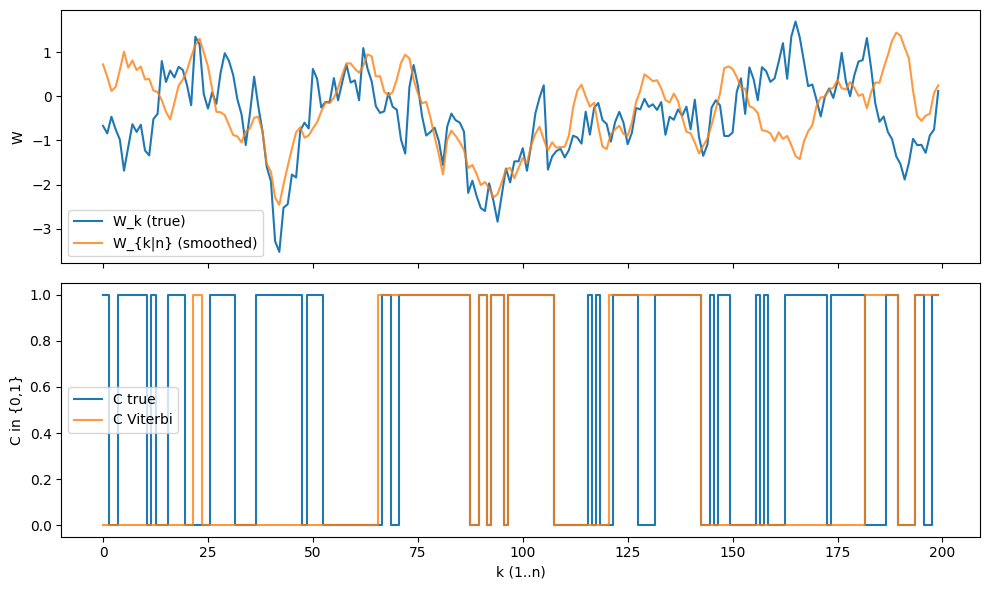

In [2]:
"""
Example 1.3.9 — Conditionally Gaussian Linear State-Space Model (unknown bits C_k)
-------------------------------------------------------------------------------
This module implements the numerical solution respecting the **book notation**
(Cappé–Moulines–Rydén), with explicit references to the relevant algorithms.

Model (scalar case):
    W_k = A * W_{k-1} + R * U_k,   U_k ~ N(0, 1)
    Y_k = C_k * W_k   + S * V_k,   V_k ~ N(0, 1)
Where A=ρ, R=σ_u, S=σ_v in the book.  R and S are noise **scales** (variances are R^2, S^2).

Implemented blocks (book names & numbers):
- Algorithm 5.2.13: Kalman filtering (known C)
- RTS smoother (same section 5.2): Rauch–Tung–Striebel smoothing
- Algorithm 6.1.2: Gaussian FFBS (simulation smoother) for W | C, Y
- Algorithm 6.1.1 (finite-state FFBS): backward sampling for C | W, Y (Markov prior)
- Algorithm 5.1.4: Viterbi (MAP sequence) on a 2-state switching LDS (stores per-state filters)

Routes for unknown C_k:
- Rao–Blackwellized Gibbs: sample W | C, Y using Gaussian FFBS; then sample C | W, Y using
  either i.i.d. sitewise (closed form) or finite-state FFBS with transition matrix Q.
- Viterbi over the switching LDS for MAP C (keeps per-state Kalman tracks).

All arrays indexed 0..n-1 correspond to k = 1..n in the book. Comments note the mapping.
"""

from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

EPS = 1e-12
TWOPI = 2.0 * np.pi

# -----------------------------
# Utility: stable log-sum-exp
# -----------------------------
def logsumexp(logw: np.ndarray, axis: Optional[int] = None) -> np.ndarray:
    m = np.max(logw, axis=axis, keepdims=True)
    s = np.log(np.maximum(np.sum(np.exp(logw - m), axis=axis, keepdims=True), EPS))
    out = (m + s)
    return out if axis is None else np.squeeze(out, axis=axis)


# -------------------------------------------------
# 0) Simulation (faithful to the book's parameters)
# -------------------------------------------------
def simulate_example_1_3_9(
    n: int,
    A: float,
    R: float,
    S: float,
    *,
    prior_C: Dict[str, np.ndarray | float] | None = None,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate (C, W, Y) with book letters.

    Args:
        n: length (k = 1..n)
        A,R,S: book parameters (R,S are noise scales)
        prior_C:
            - IID: {"type":"iid", "p_plus": 0.5}
            - Markov: {"type":"markov", "Q": 2x2 row-stochastic, order [-1,+1],
                       "pi": optional 2-vector for C_1}
        W1_0, P1_0: prior for W_{1|0}. If P1_0 None and |A|<1, uses stationary variance R^2/(1-A^2).
        rng: numpy Generator

    Returns:
        C (±1), W, Y  (arrays of length n)
    """
    rng = np.random.default_rng() if rng is None else rng

    if P1_0 is None:
        if abs(A) < 1.0:
            P1_0 = (R * R) / max(1.0 - A * A, EPS)
        else:
            P1_0 = 1000.0 * (R * R)

    # --- sample C ---
    if prior_C is None or prior_C.get("type", "iid") == "iid":
        p_plus = float(prior_C.get("p_plus", 0.5)) if prior_C else 0.5
        C = rng.choice([-1, 1], size=n, p=[1.0 - p_plus, p_plus]).astype(float)
    else:
        Q = np.asarray(prior_C["Q"], dtype=float)  # order [-1,+1]
        pi = np.asarray(prior_C.get("pi", [0.5, 0.5]), dtype=float)
        C = np.empty(n, dtype=float)
        state_map = np.array([-1.0, 1.0])
        j = rng.choice(2, p=pi)
        C[0] = state_map[j]
        for k in range(1, n):
            j = rng.choice(2, p=Q[j])
            C[k] = state_map[j]

    # --- sample W ---
    W = np.empty(n, dtype=float)
    W[0] = rng.normal(W1_0, np.sqrt(max(P1_0, 0.0)))
    for k in range(1, n):  # k=2..n in book
        W[k] = A * W[k - 1] + R * rng.normal()

    # --- sample Y ---
    Y = C * W + S * rng.normal(size=n)
    return C, W, Y


# ---------------------------------------------------------
# 1) Algorithm 5.2.13 — Kalman Filtering (known C)
# ---------------------------------------------------------
def kalman_filter_known_C(
    Y: np.ndarray,
    C: np.ndarray,
    A: float,
    R: float,
    S: float,
    *,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
    """Scalar Kalman filter with measurement matrix C_k (book notation).

    Returns arrays (length n):
      W_pred, P_pred, eps, Gamma, K, W_filt, P_filt, loglik_sum
    where index 0 corresponds to k=1 in the book.
    """
    n = len(Y)
    if P1_0 is None:
        if abs(A) < 1.0:
            P1_0 = (R * R) / max(1.0 - A * A, EPS)
        else:
            P1_0 = 1000.0 * (R * R)

    W_pred = np.zeros(n)
    P_pred = np.zeros(n)
    eps = np.zeros(n)
    Gamma = np.zeros(n)
    K = np.zeros(n)
    W_filt = np.zeros(n)
    P_filt = np.zeros(n)

    W_f_prev = W1_0
    P_f_prev = P1_0

    loglik = 0.0
    for k in range(n):  # k=0..n-1 corresponds to book k=1..n
        # Prediction
        W_pred[k] = A * W_f_prev
        P_pred[k] = A * A * P_f_prev + R * R

        # Innovation & update (keep C_k explicitly)
        eps[k] = Y[k] - C[k] * W_pred[k]
        Gamma[k] = C[k] * C[k] * P_pred[k] + S * S
        Gk = max(Gamma[k], EPS)
        K[k] = (P_pred[k] * C[k]) / Gk

        W_filt[k] = W_pred[k] + K[k] * eps[k]
        P_filt[k] = (1.0 - K[k] * C[k]) * P_pred[k]

        # log-likelihood increment (including 2π for completeness)
        loglik += -0.5 * (np.log(TWOPI * Gk) + (eps[k] * eps[k]) / Gk)

        W_f_prev = W_filt[k]
        P_f_prev = max(P_filt[k], 0.0)

    return W_pred, P_pred, eps, Gamma, K, W_filt, P_filt, loglik


# ---------------------------------------------------------
# 2) RTS Smoother (same section 5.2)
# ---------------------------------------------------------
def rts_smoother(
    A: float,
    W_pred: np.ndarray,
    P_pred: np.ndarray,
    W_filt: np.ndarray,
    P_filt: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Rauch–Tung–Striebel smoother.

    Returns:
        W_smooth, P_smooth, J  (all length n)
    """
    n = len(W_filt)
    W_s = np.zeros(n)
    P_s = np.zeros(n)
    J = np.zeros(n)

    # initialize at n (book: W_{n|n})
    W_s[-1] = W_filt[-1]
    P_s[-1] = max(P_filt[-1], 0.0)

    for k in range(n - 2, -1, -1):  # k = n-1..1 in book
        denom = max(P_pred[k + 1], EPS)
        J[k] = (P_filt[k] * A) / denom
        W_s[k] = W_filt[k] + J[k] * (W_s[k + 1] - W_pred[k + 1])
        P_s[k] = P_filt[k] + J[k] * J[k] * (P_s[k + 1] - P_pred[k + 1])
        P_s[k] = max(P_s[k], 0.0)

    return W_s, P_s, J


# ---------------------------------------------------------
# 3) Algorithm 6.1.2 — Gaussian FFBS sampler for W | C, Y
# ---------------------------------------------------------
def ffbs_sample_W(
    A: float,
    R: float,
    W_pred: np.ndarray,
    P_pred: np.ndarray,
    W_filt: np.ndarray,
    P_filt: np.ndarray,
    *,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Forward-Filter Backward-Sample a single trajectory W | C, Y.
    Uses the same J_k as in RTS.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(W_filt)
    W_s = np.zeros(n)

    # sample W_n | Y
    var_n = max(P_filt[-1], 0.0)
    W_s[-1] = rng.normal(W_filt[-1], np.sqrt(var_n))

    for k in range(n - 2, -1, -1):
        denom = max(P_pred[k + 1], EPS)
        J_k = (P_filt[k] * A) / denom
        mean_k = W_filt[k] + J_k * (W_s[k + 1] - W_pred[k + 1])
        var_k = max(P_filt[k] - J_k * P_pred[k + 1] * J_k, 0.0)
        # Numerical safeguard: variance must be non-negative
        W_s[k] = rng.normal(mean_k, np.sqrt(var_k + 1e-15))
   
    return W_s


# -------------------------------------------------------------------
# 4) Gibbs: sample C | W, Y
#     (a) IID prior: independent sitewise conditionals
#     (b) Markov prior: finite-state FFBS (Algorithm 6.1.1)
# -------------------------------------------------------------------

def gibbs_sample_C_given_WY_iid(
    W: np.ndarray,
    Y: np.ndarray,
    S: float,
    *,
    p_plus: float = 0.5,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample C (±1) given W,Y under IID prior.
    p(C_k=+1 | W_k,Y_k) ∝ exp(- (Y_k - W_k)^2 / (2 S^2)) times prior p_plus.
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(W)
    C = np.empty(n, dtype=float)
    inv_S2 = 1.0 / max(S * S, EPS)
    for k in range(n):
        logp_plus = -0.5 * inv_S2 * (Y[k] - W[k]) ** 2 + np.log(max(p_plus, EPS))
        logp_minus = -0.5 * inv_S2 * (Y[k] + W[k]) ** 2 + np.log(max(1.0 - p_plus, EPS))
        m = max(logp_plus, logp_minus)
        p = np.exp(logp_plus - m) / (np.exp(logp_plus - m) + np.exp(logp_minus - m))
        C[k] = 1.0 if rng.random() < p else -1.0
    return C


def hmm_forward_normalized_log(
    log_emissions: np.ndarray,
    Q: np.ndarray,
    pi: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """Forward (α) in log-domain with normalization (2 states).

    Args:
        log_emissions: shape (n, 2) for states [-1,+1]
        Q: (2,2) transition matrix, rows sum to 1 (order [-1,+1])
        pi: length-2 initial distribution for C_1

    Returns:
        log_alpha_norm: (n,2) normalized (subtract per-time lse),
        logZ: (n,) normalizers so that sum_c exp(log_alpha_raw) = exp(sum logZ)
    """
    n = log_emissions.shape[0]
    logQ = np.log(np.maximum(Q, EPS))
    logpi = np.log(np.maximum(pi, EPS))

    log_alpha = np.empty((n, 2))
    logZ = np.empty(n)

    # k=0 (book k=1)
    log_alpha[0, :] = logpi + log_emissions[0, :]
    z0 = logsumexp(log_alpha[0, :]).item()
    log_alpha[0, :] -= z0
    logZ[0] = z0

    # k=1..n-1
    for k in range(1, n):
        # for each current state j, sum over previous i
        la = np.stack([
            log_alpha[k - 1, 0] + logQ[0, :],
            log_alpha[k - 1, 1] + logQ[1, :],
        ], axis=0)  # shape (2,2)
        log_pred = logsumexp(la, axis=0)  # shape (2,)
        log_alpha[k, :] = log_pred + log_emissions[k, :]
        zk = logsumexp(log_alpha[k, :]).item()
        log_alpha[k, :] -= zk
        logZ[k] = zk

    return log_alpha, logZ


def hmm_backward_sample(
    log_alpha: np.ndarray,
    logZ: np.ndarray,
    Q: np.ndarray,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Backward sampling (Algorithm 6.1.1 style) given normalized forward messages.
    Returns C in {−1,+1} (float array length n). State order is [-1,+1].
    """
    rng = np.random.default_rng() if rng is None else rng
    n = log_alpha.shape[0]
    C = np.empty(n, dtype=float)
    logQ = np.log(np.maximum(Q, EPS))

    # sample last state from α_n
    probs_last = np.exp(log_alpha[-1, :] - logsumexp(log_alpha[-1, :]))
    j = 1 if rng.random() < probs_last[1] else 0
    C[-1] = -1.0 if j == 0 else 1.0

    # backward pass
    for k in range(n - 2, -1, -1):
        # p(c_k = i | c_{k+1} = j, Y) ∝ exp(log_alpha[k,i]) * Q[i,j]
        num0 = np.exp(log_alpha[k, 0]) * np.exp(logQ[0, j])
        num1 = np.exp(log_alpha[k, 1]) * np.exp(logQ[1, j])
        s = num0 + num1
        p1 = num1 / max(s, EPS)
        j = 1 if rng.random() < p1 else 0
        C[k] = -1.0 if j == 0 else 1.0

    return C


def gibbs_sample_C_given_WY_markov(
    W: np.ndarray,
    Y: np.ndarray,
    S: float,
    Q: np.ndarray,
    pi: Optional[np.ndarray] = None,
    *,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample C (±1) given W,Y under a 2-state Markov prior with transitions Q.
    Uses finite-state FFBS (Algorithm 6.1.1) with Gaussian emissions N(c*W_k, S^2).
    State order is [-1,+1].
    """
    rng = np.random.default_rng() if rng is None else rng
    n = len(W)
    if pi is None:
        # stationary dist of Q (for ergodic 2x2)
        a, b = Q[0, 1], Q[1, 0]
        s = a + b if (a + b) > 0 else 1.0
        pi = np.array([b / s, a / s])

    # log emission likelihoods per state
    inv_S2 = 1.0 / max(S * S, EPS)
    # states: [-1, +1]
    m_minus = -W
    m_plus = +W
    loge_minus = -0.5 * (np.log(TWOPI * (S * S)) + inv_S2 * (Y - m_minus) ** 2)
    loge_plus = -0.5 * (np.log(TWOPI * (S * S)) + inv_S2 * (Y - m_plus) ** 2)
    log_emissions = np.stack([loge_minus, loge_plus], axis=1)  # (n,2)

    log_alpha, logZ = hmm_forward_normalized_log(log_emissions, Q, pi)
    C = hmm_backward_sample(log_alpha, logZ, Q, rng)
    return C


# -------------------------------------------------------------
# 5) Rao–Blackwellized Gibbs driver
# -------------------------------------------------------------
@dataclass
class GibbsConfig:
    iters: int = 2000
    burn_in: int = 500
    thin: int = 1
    iid_bits: bool = False
    p_plus: float = 0.5  # used if iid_bits=True


def gibbs_sampler(
    Y: np.ndarray,
    A: float,
    R: float,
    S: float,
    *,
    Q: Optional[np.ndarray] = None,  # if provided, Markov prior; otherwise IID with p_plus
    pi: Optional[np.ndarray] = None,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
    config: Optional[GibbsConfig] = None,
    rng: Optional[np.random.Generator] = None,
) -> Dict[str, np.ndarray | float | Dict[str, float]]:
    """Rao–Blackwellized Gibbs for unknown C.

    Iterates:
      1) W | C, Y via Kalman + FFBS (Alg. 5.2.13 + 6.1.2)
      2) C | W, Y via IID sitewise or Markov FFBS (Alg. 6.1.1)

    Returns last draw and (optionally) kept samples.
    """
    rng = np.random.default_rng() if rng is None else rng
    config = config or GibbsConfig()

    n = len(Y)
    # init C randomly
    C = rng.choice([-1.0, 1.0], size=n).astype(float)

    kept_W = []
    kept_C = []

    for t in range(config.iters):
        # 1) W | C,Y
        Wp, Pp, eps, Gam, K, Wf, Pf, _ = kalman_filter_known_C(Y, C, A, R, S, W1_0=W1_0, P1_0=P1_0)
        W_draw = ffbs_sample_W(A, R, Wp, Pp, Wf, Pf, rng=rng)

        # 2) C | W,Y
        if Q is not None:
            C = gibbs_sample_C_given_WY_markov(W_draw, Y, S, Q, pi=(pi if pi is not None else np.array([0.0, 1.0])), rng=rng)
        else:
            C = gibbs_sample_C_given_WY_iid(W_draw, Y, S, p_plus=config.p_plus, rng=rng)
        # Anchor first bit (pilot): C_1 = +1 in state order [-1,+1]
        C[0] = 1.0

        # keep if beyond burn-in and matching thinning
        if t >= config.burn_in and ((t - config.burn_in) % config.thin == 0):
            kept_W.append(W_draw.copy())
            kept_C.append(C.copy())

    out = {
        "W_last": W_draw,
        "C_last": C,
        "W_kept": np.array(kept_W) if kept_W else np.empty((0, n)),
        "C_kept": np.array(kept_C) if kept_C else np.empty((0, n)),
    }
    return out


# -----------------------------------------------------------------
# 6) Algorithm 5.1.4 — Viterbi for switching LDS (2 states: ±1)
# -----------------------------------------------------------------

def viterbi_switching_kalman(
    Y: np.ndarray,
    A: float,
    R: float,
    S: float,
    Q: np.ndarray,
    *,
    pi: Optional[np.ndarray] = None,
    W1_0: float = 0.0,
    P1_0: Optional[float] = None,
) -> Tuple[np.ndarray, float]:
    """Viterbi MAP for bits C∈{−1,+1} on a switching LDS (keeps per-state filters).
    Stores and propagates the **filter state** (W_{k|k}, P_{k|k}) for the best predecessor.

    Returns:
        C_map (±1 as float array), max_log_prob
    """
    n = len(Y)
    if P1_0 is None:
        if abs(A) < 1.0:
            P1_0 = (R * R) / max(1.0 - A * A, EPS)
        else:
            P1_0 = 1000.0 * (R * R)

    if pi is None:
        pi = np.array([0.0, 1.0])  # pilot: C1 = +1 (state order [-1, +1])

    states = np.array([-1.0, 1.0])
    logQ = np.log(np.maximum(Q, EPS))
    logpi = np.log(np.maximum(pi, EPS))

    # per-state filter containers
    Wf = np.zeros((n, 2))
    Pf = np.zeros((n, 2))
    delta = -np.inf * np.ones((n, 2))  # DP scores
    psi = np.zeros((n, 2), dtype=int)  # backpointers (0 for -1, 1 for +1)

    # init k=0 from prior W1_0,P1_0
    for j, c in enumerate(states):
        # predict & update with C_1 = c
        W_pred = A * W1_0
        P_pred = A * A * P1_0 + R * R
        eps = Y[0] - c * W_pred
        Gamma = c * c * P_pred + S * S
        G = max(Gamma, EPS)
        K = (P_pred * c) / G
        Wf[0, j] = W_pred + K * eps
        Pf[0, j] = (1.0 - K * c) * P_pred
        ll = -0.5 * (np.log(TWOPI * G) + (eps * eps) / G)
        delta[0, j] = logpi[j] + ll
        psi[0, j] = 0

    # forward DP
    for k in range(1, n):
        for j, c in enumerate(states):
            # evaluate both predecessors i ∈ {0,1}
            best_score = -np.inf
            best_i = 0
            best_W = 0.0
            best_P = 0.0
            for i, cprev in enumerate(states):
                # start from predecessor's filter state
                W_prev = Wf[k - 1, i]
                P_prev = Pf[k - 1, i]
                # predict
                W_pred = A * W_prev
                P_pred = A * A * P_prev + R * R
                # update with C_k = c
                eps = Y[k] - c * W_pred
                Gamma = c * c * P_pred + S * S
                G = max(Gamma, EPS)
                K = (P_pred * c) / G
                W_new = W_pred + K * eps
                P_new = (1.0 - K * c) * P_pred
                # incremental loglik
                ll = -0.5 * (np.log(TWOPI * G) + (eps * eps) / G)
                score = delta[k - 1, i] + logQ[i, j] + ll
                if score > best_score:
                    best_score = score
                    best_i = i
                    best_W = W_new
                    best_P = P_new
            delta[k, j] = best_score
            psi[k, j] = best_i
            Wf[k, j] = best_W
            Pf[k, j] = best_P

    # backtrack
    jT = int(np.argmax(delta[-1, :]))
    C_map = np.empty(n, dtype=float)
    C_map[-1] = states[jT]
    for k in range(n - 2, -1, -1):
        jT = psi[k + 1, jT]
        C_map[k] = states[jT]

    return C_map, float(delta[-1, int(np.argmax(delta[-1, :]))])


# -------------------------------------------------------------
# 7) Metrics & plotting helpers (book letters in labels)
# -------------------------------------------------------------

def nrmse(true: np.ndarray, est: np.ndarray) -> float:
    """NRMSE = RMSE / std(true)."""
    err = true - est
    rmse = np.sqrt(np.mean(err * err))
    denom = np.std(true) + EPS
    return float(rmse / denom)


def bit_accuracy(C_true: np.ndarray, C_est: np.ndarray) -> Tuple[float, int]:
    correct = int(np.sum(np.sign(C_true) == np.sign(C_est)))
    return float(correct / len(C_true)), correct


# -----------------------------
# 8) Minimal demo (optional)
# -----------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(0)
    n = 200
    A, R, S = 0.9, 0.5, 0.8  # book letters

    Q = np.array([[0.8, 0.2],
                  [0.2, 0.8]])  # transitions for [-1,+1]

    C, W, Y = simulate_example_1_3_9(n, A, R, S, prior_C={"type": "markov", "Q": Q}, rng=rng)

    # --- Viterbi route
    C_map, _ = viterbi_switching_kalman(Y, A, R, S, Q)
    Wp, Pp, eps, Gam, K, Wf, Pf, _ = kalman_filter_known_C(Y, C_map, A, R, S)
    Ws, Ps, J = rts_smoother(A, Wp, Pp, Wf, Pf)

    # post-hoc sign alignment for evaluation only (does not change the model)
    sgn = np.sign(np.sum(W * Ws))
    if sgn < 0:
        Ws = -Ws
        C_map = -C_map

    acc, ncor = bit_accuracy(C, C_map)
    print(f"[Viterbi] Bit accuracy: {acc:.3f}  (# correct = {ncor} / {n})")
    print(f"[Viterbi] NRMSE(W_smooth): {nrmse(W, Ws):.3f}")

    # --- Gibbs route (small run for demo)
    out = gibbs_sampler(Y, A, R, S, Q=Q, config=GibbsConfig(iters=800, burn_in=200, thin=2), rng=rng)
    C_last = out["C_last"]
    Wp, Pp, eps, Gam, K, Wf, Pf, _ = kalman_filter_known_C(Y, C_last, A, R, S)
    Ws, Ps, _ = rts_smoother(A, Wp, Pp, Wf, Pf)

    # post-hoc sign alignment for evaluation only (does not change the model)
    sgn2 = np.sign(np.sum(W * Ws))
    if sgn2 < 0:
        Ws = -Ws
        C_last = -C_last

    acc2, ncor2 = bit_accuracy(C, C_last)
    print(f"[Gibbs]  Bit accuracy (last): {acc2:.3f}  (# correct = {ncor2} / {n})")
    print(f"[Gibbs]  NRMSE(W_smooth last): {nrmse(W, Ws):.3f}")

    # --- quick plots
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(W, label="W_k (true)")
    ax[0].plot(Ws, label="W_{k|n} (smoothed)", alpha=0.8)
    ax[0].set_ylabel("W")
    ax[0].legend()

    ax[1].step(range(n), (C + 1) / 2, where="mid", label="C true")
    ax[1].step(range(n), (C_map + 1) / 2, where="mid", label="C Viterbi", alpha=0.8)
    ax[1].set_ylabel("C in {0,1}")
    ax[1].set_xlabel("k (1..n)")
    ax[1].legend()
    plt.tight_layout()
    plt.show()
